# Báo Cáo Phân Tích Dữ Liệu Kinh Doanh:

## (EDA Storytelling Masterpiece - E-Commerce Fashion Vietnam)

Mục tiêu của báo cáo này là chuyển đổi dữ liệu thô thành các quyết định kinh doanh chiến lược thông qua 8 giai đoạn phân tích, áp dụng nhất quán 4 cấp độ:

---
# PHASE 0: Setup va Data Cleaning (Nen tang ky thuat)
**Mục tiêu**: Đảm bảo dữ liệu sạch và nhất quán trước khi phân tích

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

# Thiet lap hien thi do thi
plt.style.use('seaborn-v0_8-whitegrid')
COLOR_POS = '#2ecc71'   # Xanh - tich cuc
COLOR_NEG = '#e74c3c'   # Do - rui ro
COLOR_NEU = '#95a5a6'   # Xam - trung tinh
COLOR_PRIMARY = '#3498db'
COLOR_SECONDARY = '#9b59b6'
PALETTE = [COLOR_PRIMARY, COLOR_NEG, COLOR_POS, COLOR_SECONDARY, '#f39c12', '#1abc9c', '#e67e22', '#34495e']
sns.set_palette(PALETTE)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Load du lieu
data_dir = '../dataset/'
customers = pd.read_csv(data_dir + 'customers.csv', parse_dates=['signup_date'])
orders = pd.read_csv(data_dir + 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(data_dir + 'order_items.csv')
payments = pd.read_csv(data_dir + 'payments.csv')
shipments = pd.read_csv(data_dir + 'shipments.csv', parse_dates=['ship_date', 'delivery_date'])
returns = pd.read_csv(data_dir + 'returns.csv', parse_dates=['return_date'])
products = pd.read_csv(data_dir + 'products.csv')
promotions = pd.read_csv(data_dir + 'promotions.csv')
web_traffic = pd.read_csv(data_dir + 'web_traffic.csv', parse_dates=['date'])
inventory = pd.read_csv(data_dir + 'inventory.csv', parse_dates=['snapshot_date'])
reviews = pd.read_csv(data_dir + 'reviews.csv', parse_dates=['review_date'])
sales = pd.read_csv(data_dir + 'sales.csv', parse_dates=['Date'])
geography = pd.read_csv(data_dir + 'geography.csv')

print("=== Du lieu da load thanh cong ===")
for name, df in [('customers', customers), ('orders', orders), ('order_items', order_items),
                 ('payments', payments), ('shipments', shipments), ('returns', returns),
                 ('products', products), ('promotions', promotions), ('web_traffic', web_traffic),
                 ('inventory', inventory), ('reviews', reviews), ('sales', sales), ('geography', geography)]:
    print(f"  {name:15s}: {len(df):>10,} rows x {len(df.columns):>3} cols")

=== Du lieu da load thanh cong ===
  customers      :    121,930 rows x   7 cols
  orders         :    646,945 rows x   8 cols
  order_items    :    714,669 rows x   7 cols
  payments       :    646,945 rows x   4 cols
  shipments      :    566,067 rows x   4 cols
  returns        :     39,939 rows x   7 cols
  products       :      2,412 rows x   8 cols
  promotions     :         50 rows x  10 cols
  web_traffic    :      3,652 rows x   7 cols
  inventory      :     60,247 rows x  17 cols
  reviews        :    113,551 rows x   7 cols
  sales          :      3,833 rows x   3 cols
  geography      :     39,948 rows x   4 cols


### 0.1 Data Quality Dashboard
Kiem tra tinh toan ven cua du lieu truoc khi phan tich.

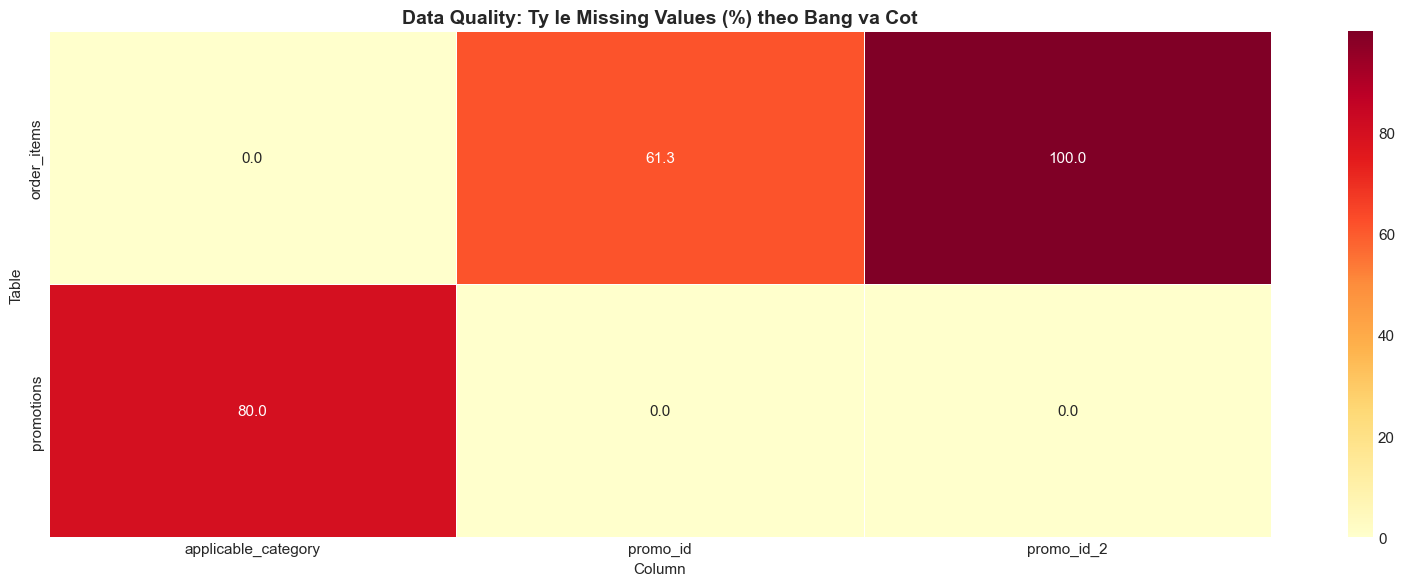


=== Kiem tra Duplicates ===
  orders          - order_id: 0 duplicates
  customers       - customer_id: 0 duplicates
  payments        - order_id: 0 duplicates


In [2]:
# === Data Quality: Missing Values Heatmap ===
all_dfs = {'customers': customers, 'orders': orders, 'order_items': order_items,
           'payments': payments, 'shipments': shipments, 'returns': returns,
           'products': products, 'promotions': promotions, 'web_traffic': web_traffic,
           'inventory': inventory, 'reviews': reviews, 'sales': sales, 'geography': geography}

missing_summary = []
for name, df in all_dfs.items():
    total = len(df)
    for col in df.columns:
        miss = df[col].isna().sum()
        if miss > 0:
            missing_summary.append({'Table': name, 'Column': col,
                                    'Missing': miss, 'Pct': round(miss/total*100, 2)})

missing_df = pd.DataFrame(missing_summary)
if len(missing_df) > 0:
    pivot = missing_df.pivot_table(index='Table', columns='Column', values='Pct', fill_value=0)
    fig, ax = plt.subplots(figsize=(16, 6))
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5)
    ax.set_title('Data Quality: Ty le Missing Values (%) theo Bang va Cot')
    plt.tight_layout()
    plt.show()
else:
    print("Khong co missing values trong du lieu.")

# Kiem tra duplicates
print("\n=== Kiem tra Duplicates ===")
for name, df in [('orders', orders), ('customers', customers), ('payments', payments)]:
    pk = df.columns[0]
    dupes = df[pk].duplicated().sum()
    print(f"  {name:15s} - {pk}: {dupes} duplicates")

### 0.2 Xu ly Anomaly va Feature Engineering
Phat hien va xu ly loi logic: 74% don hang co signup_date SAU ngay mua dau tien.
Tao cac bien phu tro cho phan tich.

In [3]:
# === 1. Fix Signup Date Anomaly ===
first_orders = orders.groupby('customer_id')['order_date'].min().reset_index(name='first_order_date')
customers = customers.merge(first_orders, on='customer_id', how='left')
anomaly_pct = (customers['first_order_date'] < customers['signup_date']).mean() * 100
print(f"Ty le don hang truoc ngay dang ky: {anomaly_pct:.1f}%")
customers['true_signup_date'] = np.where(
    customers['first_order_date'] < customers['signup_date'],
    customers['first_order_date'], customers['signup_date'])
customers['true_signup_date'] = pd.to_datetime(customers['true_signup_date'])

# === 2. Tinh total_amount cho orders tu payments ===
if 'total_amount' not in orders.columns:
    order_totals = payments.groupby('order_id')['payment_value'].sum().rename('total_amount')
    orders = orders.join(order_totals, on='order_id')

# === 3. Feature Engineering ===
orders['order_month'] = orders['order_date'].dt.to_period('M').dt.to_timestamp()
orders['order_quarter'] = orders['order_date'].dt.quarter
orders['order_year'] = orders['order_date'].dt.year
orders['day_of_week'] = orders['order_date'].dt.dayofweek
orders['is_weekend'] = orders['day_of_week'].isin([5, 6]).astype(int)

# Delivery time features
ship_data = shipments.copy()
ship_data['delivery_time'] = (ship_data['delivery_date'] - ship_data['ship_date']).dt.days
ship_data['processing_time'] = None  # ship_date - order_date (can merge)

# Item-level revenue & profit
order_items['item_revenue'] = order_items['quantity'] * order_items['unit_price'] - order_items['discount_amount'].fillna(0)
oi_with_cogs = order_items.merge(products[['product_id', 'cogs']], on='product_id', how='left')
order_items['item_profit'] = oi_with_cogs['quantity'] * oi_with_cogs['unit_price'] - oi_with_cogs['discount_amount'].fillna(0) - oi_with_cogs['quantity'] * oi_with_cogs['cogs']
order_items['discount_rate'] = order_items['discount_amount'].fillna(0) / (order_items['quantity'] * order_items['unit_price']).replace(0, np.nan)
order_items['is_discounted'] = (order_items['discount_amount'].fillna(0) > 0).astype(int)

# Sales: Gross Profit
sales['Gross_Profit'] = sales['Revenue'] - sales['COGS']
sales['Gross_Margin'] = sales['Gross_Profit'] / sales['Revenue'].replace(0, np.nan)
sales['YearMonth'] = sales['Date'].dt.to_period('M')

# Orders delivered (for downstream analysis)
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

# Merge geography
orders = orders.merge(geography[['zip', 'region', 'district']], on='zip', how='left')

print("=== Feature Engineering hoan tat ===")
print(f"  Orders: {len(orders):,} | Delivered: {len(orders_delivered):,}")
print(f"  Sales range: {sales['Date'].min().date()} -> {sales['Date'].max().date()}")
print(f"  Gross Margin trung binh: {sales['Gross_Margin'].mean()*100:.1f}%")

Ty le don hang truoc ngay dang ky: 66.1%
=== Feature Engineering hoan tat ===
  Orders: 646,945 | Delivered: 516,716
  Sales range: 2012-07-04 -> 2022-12-31
  Gross Margin trung binh: 12.5%


---
# PHASE 1: Business Pulse va Time Series Overview (Cái nhìn toàn cảnh)
**Muc tieu**: Xác định tình trạng doanh nghiệp, đưa ra cái nhìn toàn cảnh về doanh thu

> **Câu hỏi kinh doanh**: Doanh thu đang có xu hướng như thế nào, có tăng trưởng bền vững không?

- Để bắt đầu, chúng ta sẽ cùng phân tích diễn biến doanh thu theo thời gian nhằm xác định quỹ đạo tăng trưởng tổng thể của doanh nghiệp. 
- Việc quan sát sự biến động này là bước đệm quan trọng để chúng ta hiểu được tính mùa vụ và những thời điểm hệ thống vận hành bắt đầu chịu áp lực lớn.

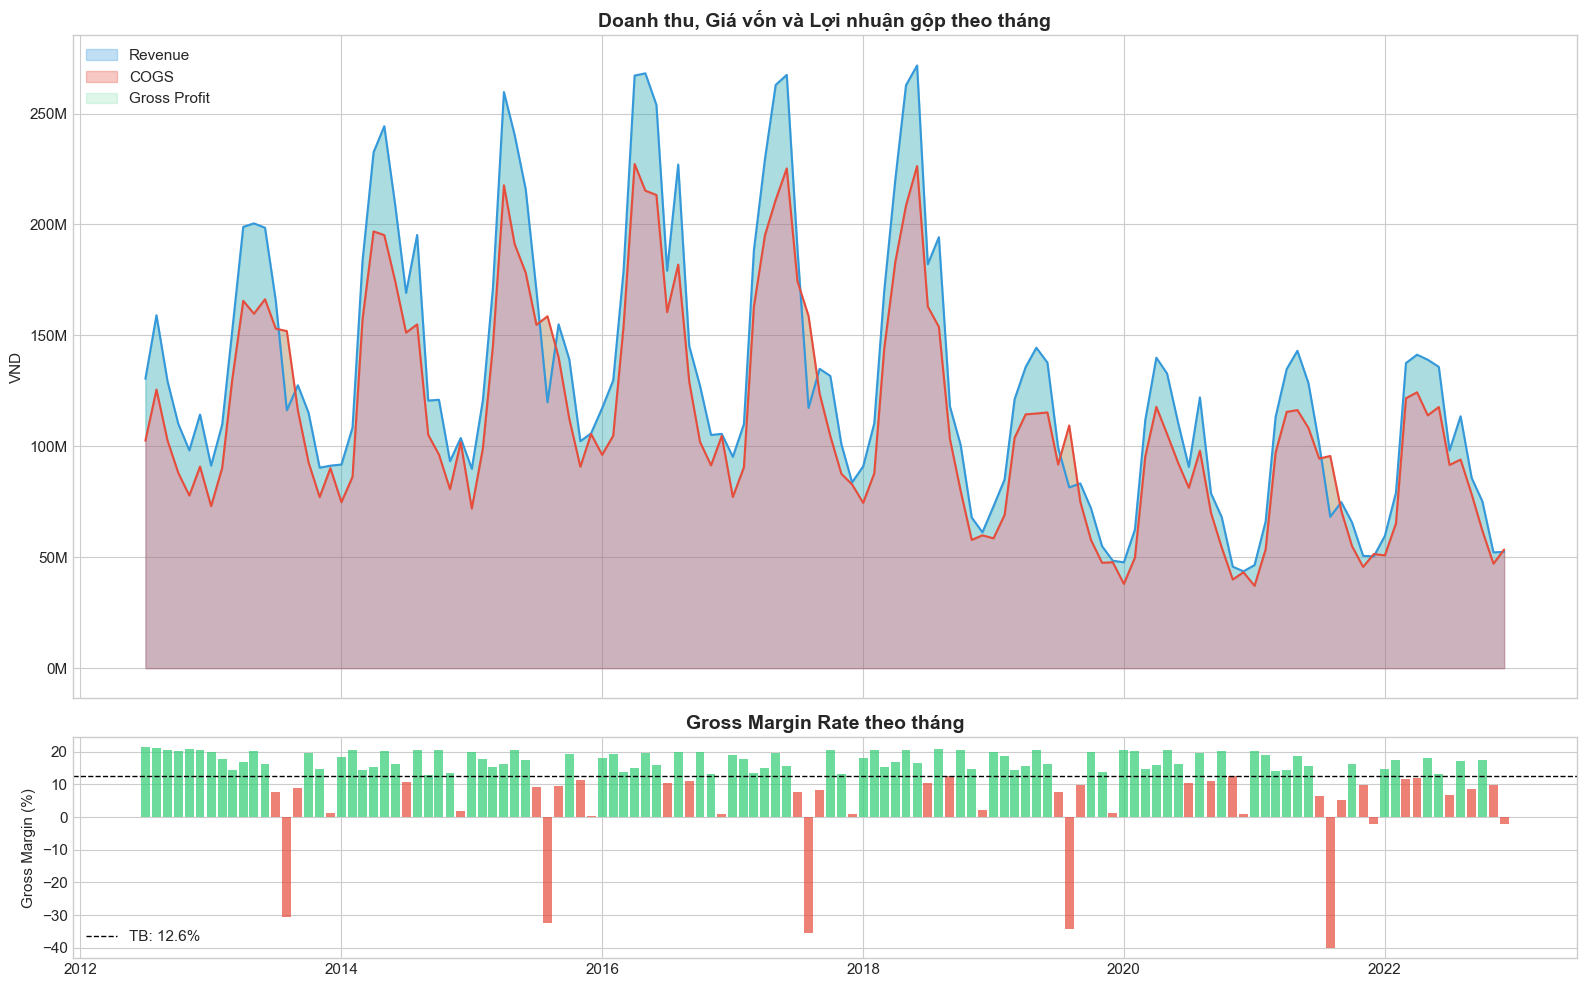

[Insight] Gross Margin trung bình: 12.6%.


In [4]:
# === 1.1 Monthly Revenue, COGS va Gross Profit Trend ===
monthly_sales = sales.groupby('YearMonth').agg(
    Revenue=('Revenue', 'sum'), COGS=('COGS', 'sum'), Gross_Profit=('Gross_Profit', 'sum')
).reset_index()
monthly_sales['month_dt'] = monthly_sales['YearMonth'].dt.to_timestamp()
monthly_sales['Gross_Margin'] = monthly_sales['Gross_Profit'] / monthly_sales['Revenue'] * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

# Revenue & COGS
ax1.fill_between(monthly_sales['month_dt'], monthly_sales['Revenue'], alpha=0.3, color=COLOR_PRIMARY, label='Revenue')
ax1.fill_between(monthly_sales['month_dt'], monthly_sales['COGS'], alpha=0.3, color=COLOR_NEG, label='COGS')
ax1.plot(monthly_sales['month_dt'], monthly_sales['Revenue'], color=COLOR_PRIMARY, linewidth=1.5)
ax1.plot(monthly_sales['month_dt'], monthly_sales['COGS'], color=COLOR_NEG, linewidth=1.5)
ax1.fill_between(monthly_sales['month_dt'], monthly_sales['COGS'], monthly_sales['Revenue'],
                 alpha=0.15, color=COLOR_POS, label='Gross Profit')
ax1.set_title('Doanh thu, Giá vốn và Lợi nhuận gộp theo tháng')
ax1.set_ylabel('VND')
ax1.legend(loc='upper left')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# Gross Margin
ax2.bar(monthly_sales['month_dt'], monthly_sales['Gross_Margin'],
        width=25, color=[COLOR_POS if v >= monthly_sales['Gross_Margin'].mean() else COLOR_NEG
                         for v in monthly_sales['Gross_Margin']], alpha=0.7)
ax2.axhline(monthly_sales['Gross_Margin'].mean(), color='black', linestyle='--', linewidth=1, label=f"TB: {monthly_sales['Gross_Margin'].mean():.1f}%")
ax2.set_ylabel('Gross Margin (%)')
ax2.set_title('Gross Margin Rate theo tháng')
ax2.legend()

plt.tight_layout()
plt.show()
print(f"[Insight] Gross Margin trung bình: {monthly_sales['Gross_Margin'].mean():.1f}%.")

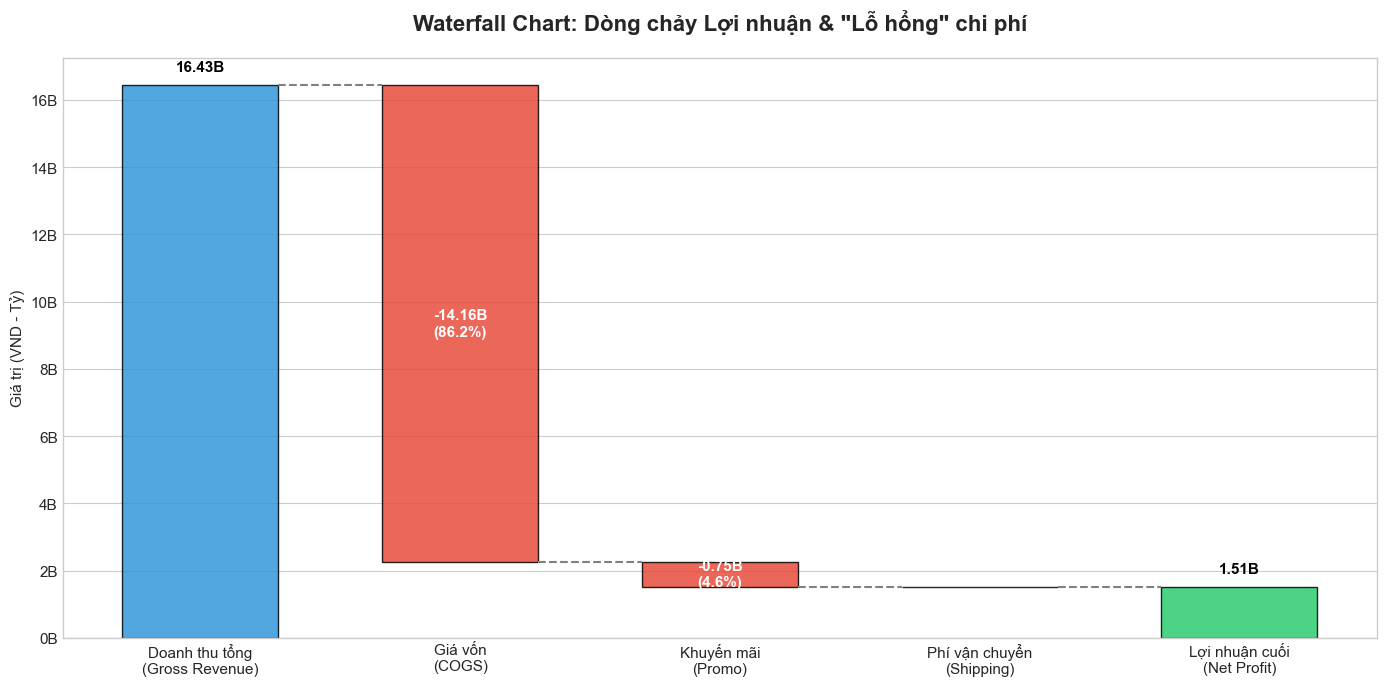

========== INSIGHTS: TIỀN ĐÃ BIẾN ĐI ĐÂU? ==========
Tổng doanh thu gộp (Gross Revenue): 16.43 Tỷ VND (100%)
Tỷ lệ 'cắt máu' lợi nhuận trên từng chặn:
  [-] Giá vốn hàng bán (COGS): -86.2%
  [-] Chi phí Khuyến mãi (Promo): -4.6%
  [-] Phí vận chuyển (Shipping): -0.0%
=> GIỮ LẠI ĐƯỢC (Net Profit Margin): 9.2%


In [5]:
# === 1.6 WATERFALL CHART: DÒNG CHẢY LỢI NHUẬN (TIỀN ĐÃ BIẾN ĐI ĐÂU?) ===

# 1. Tính toán các thành phần dòng tiền từ dữ liệu gốc
total_gross_revenue = (order_items['quantity'] * order_items['unit_price']).sum()
total_cogs = (oi_with_cogs['quantity'] * oi_with_cogs['cogs']).sum()
total_promo = order_items['discount_amount'].fillna(0).sum()
total_shipping = shipments['shipping_fee'].fillna(0).sum()

# Tính lợi nhuận cuối cùng
total_net_profit = total_gross_revenue - total_cogs - total_promo - total_shipping

# 2. Khởi tạo mảng dữ liệu cho biểu đồ
steps = ['Doanh thu tổng\n(Gross Revenue)', 'Giá vốn\n(COGS)', 'Khuyến mãi\n(Promo)', 'Phí vận chuyển\n(Shipping)', 'Lợi nhuận cuối\n(Net Profit)']
values = [total_gross_revenue, -total_cogs, -total_promo, -total_shipping, total_net_profit]
heights = [total_gross_revenue, total_cogs, total_promo, total_shipping, total_net_profit]

# Xác định điểm bắt đầu (bottom) của từng cột để tạo hiệu ứng bậc thang
bottoms = [
    0, 
    total_gross_revenue - total_cogs, 
    total_gross_revenue - total_cogs - total_promo,
    total_gross_revenue - total_cogs - total_promo - total_shipping,
    0  # Cột chốt lời vẽ từ 0 lên
]

# Set màu: Cột đầu (Tích cực), 3 cột giữa (Tiêu cực / Cắt máu), Cột cuối (Tích cực)
colors = [COLOR_PRIMARY, COLOR_NEG, COLOR_NEG, COLOR_NEG, COLOR_POS]

# 3. Tiến hành vẽ Waterfall
fig, ax = plt.subplots(figsize=(14, 7))

for i in range(len(steps)):
    # Vẽ cột
    ax.bar(steps[i], heights[i], bottom=bottoms[i], color=colors[i], width=0.6, alpha=0.85, edgecolor='black')
    
    # Ghi chú Text (Label & Phần trăm)
    val = values[i]
    label = f"{val/1e9:+.2f}B" if val < 0 else f"{val/1e9:.2f}B"
    pct = f"\n({abs(val)/total_gross_revenue*100:.1f}%)" if 0 < i < 4 else ""
    
    # Vị trí text: Cột trừ tiền thì nằm giữa, cột dương (doanh thu/lợi nhuận) thì nằm trên đầu
    y_text = bottoms[i] + heights[i]/2 if (0 < i < 4) else heights[i] + (total_gross_revenue * 0.02)
    va = 'center' if (0 < i < 4) else 'bottom'
    color_text = 'white' if (0 < i < 4) else 'black'
    
    ax.text(i, y_text, f"{label}{pct}", ha='center', va=va, fontweight='bold', fontsize=11, color=color_text)

# 4. Kẻ đường đứt nét nối các bậc
for i in range(1, len(steps)):
    y_line = bottoms[i] + heights[i] if i < len(steps)-1 else heights[i]
    ax.plot([i-1 + 0.3, i - 0.3], [y_line, y_line], color='gray', linestyle='--')

# 5. Format biểu đồ
ax.set_title('Waterfall Chart: Dòng chảy Lợi nhuận & "Lỗ hổng" chi phí', fontsize=16, pad=20)
ax.set_ylabel('Giá trị (VND - Tỷ)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.0f}B'))
ax.grid(axis='x') # Tắt lưới dọc cho đỡ rối

plt.tight_layout()
plt.show()

# 6. In ra Insights trực diện
print(f"========== INSIGHTS: TIỀN ĐÃ BIẾN ĐI ĐÂU? ==========")
print(f"Tổng doanh thu gộp (Gross Revenue): {total_gross_revenue/1e9:.2f} Tỷ VND (100%)")
print(f"Tỷ lệ 'cắt máu' lợi nhuận trên từng chặn:")
print(f"  [-] Giá vốn hàng bán (COGS): -{total_cogs/total_gross_revenue*100:.1f}%")
print(f"  [-] Chi phí Khuyến mãi (Promo): -{total_promo/total_gross_revenue*100:.1f}%")
print(f"  [-] Phí vận chuyển (Shipping): -{total_shipping/total_gross_revenue*100:.1f}%")
print(f"=> GIỮ LẠI ĐƯỢC (Net Profit Margin): {total_net_profit/total_gross_revenue*100:.1f}%")
print(f"====================================================")


### Nhận xét tổng quan về tình hình kinh doanh (2012 - 2023)
* **Xu hướng & Chu kỳ:** Doanh thu có tính chu kỳ năm mạnh mẽ, đạt đỉnh vào giai đoạn 2017-2018 và có xu hướng giảm dần, đi ngang từ năm 2019.
* **Mối quan hệ Doanh thu - Giá vốn:** Giá vốn (COGS) bám rất sát đường doanh thu, cho thấy biên lợi nhuận gộp của doanh nghiệp khá mỏng.
* **Hiệu suất lợi nhuận:** Biên lợi nhuận gộp trung bình đạt **12.6%**, tuy nhiên mức độ ổn định không cao và biến động liên tục qua các năm.
* **Cảnh báo rủi ro:** Xuất hiện định kỳ các tháng có lợi nhuận âm (cột đỏ), đặc biệt có thời điểm giảm sâu xuống mức **-40%** (năm 2021).
* **Kết luận:** Doanh nghiệp cần tối ưu hóa giá vốn và kiểm soát chặt chẽ các giai đoạn bán hàng dưới giá vốn để đảm bảo an toàn tài chính.

### Phân tích sâu: Phân rã chuỗi thời gian (Time Series Decomposition)

Sau khi quan sát biến động tổng quan, chúng ta thấy doanh thu có sự trồi sụt rất mạnh và mang tính lặp lại. Để xác định rõ đâu là thay đổi mang tính chiến lược (xu hướng dài hạn), đâu là ảnh hưởng của thị trường theo thời điểm (mùa vụ), và đâu là các sự cố bất thường, chúng ta tiến hành phương pháp **Phân rã chuỗi thời gian (Multiplicative Decomposition)**. 

Việc tách biệt dữ liệu gốc thành các thành phần độc lập sẽ giúp doanh nghiệp:
1. Nhìn rõ "sức khỏe" thực sự của xu hướng kinh doanh khi đã loại bỏ yếu tố mùa vụ.
2. Xác định các tháng cao điểm cố định để tối ưu hóa nguồn lực.
3. Cô lập các biến động nhiễu để điều tra nguyên nhân của những lần sụt giảm bất thường.

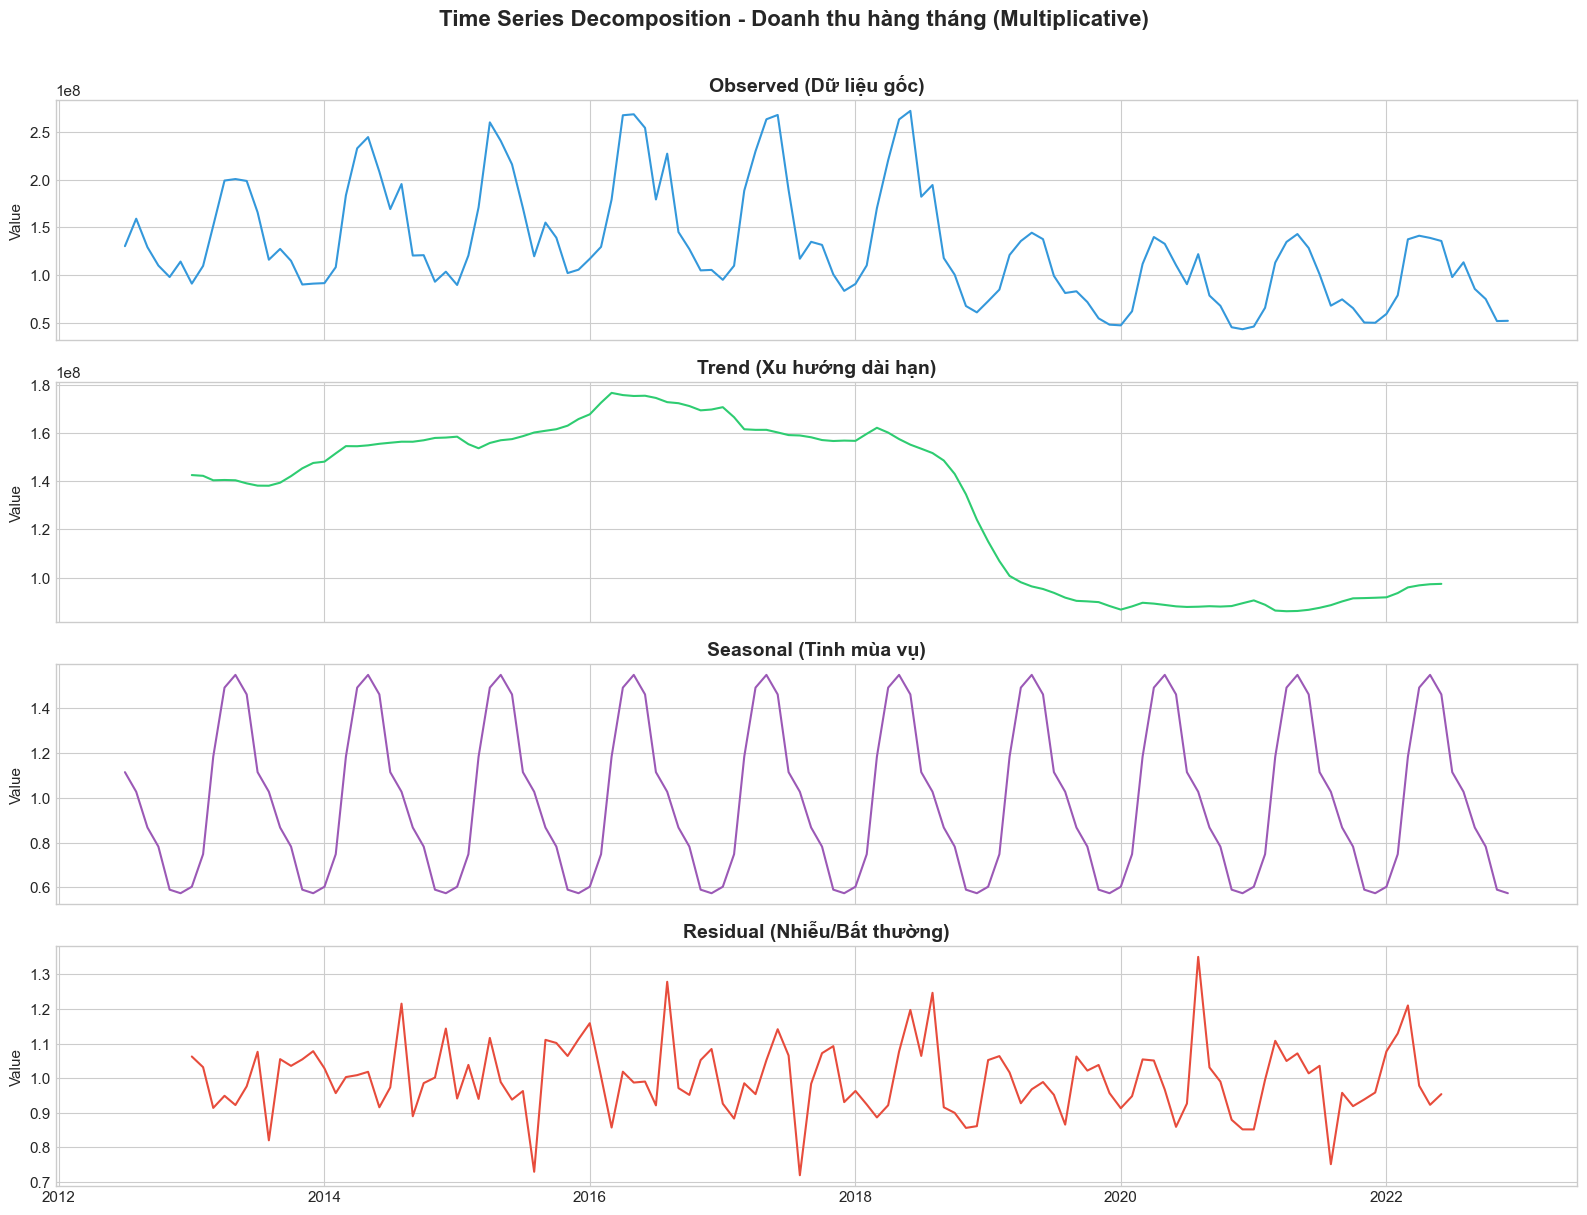

[Insight] Tháng cao điểmm nhat: tháng 5 (seasonal factor: 1.55x)
[Insight] Tháng thấp điểmm nhat: tháng 12 (seasonal factor: 0.57x)


In [6]:
# === 1.2 Time Series Decomposition (Boc tach xu huong, mua vu, nhieu) ===
from statsmodels.tsa.seasonal import seasonal_decompose

monthly_rev = sales.groupby('YearMonth')['Revenue'].sum()
monthly_rev.index = monthly_rev.index.to_timestamp()

# Can it nhat 2 chu ky (24 thang) de decompose
if len(monthly_rev) >= 24:
    result = seasonal_decompose(monthly_rev, model='multiplicative', period=12)

    fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
    titles = ['Observed (Dữ liệu gốc)', 'Trend (Xu hướng dài hạn)',
              'Seasonal (Tinh mùa vụ)', 'Residual (Nhiễu/Bất thường)']
    data_list = [result.observed, result.trend, result.seasonal, result.resid]
    colors = [COLOR_PRIMARY, COLOR_POS, COLOR_SECONDARY, COLOR_NEG]

    for ax, title, data, color in zip(axes, titles, data_list, colors):
        ax.plot(data, color=color, linewidth=1.5)
        ax.set_title(title)
        ax.set_ylabel('Value')

    plt.suptitle('Time Series Decomposition - Doanh thu hàng tháng (Multiplicative)', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    # Phan tich seasonal pattern
    seasonal_pattern = result.seasonal.groupby(result.seasonal.index.month).first()
    peak_month = seasonal_pattern.idxmax()
    trough_month = seasonal_pattern.idxmin()
    print(f"[Insight] Tháng cao điểmm nhat: tháng {peak_month} (seasonal factor: {seasonal_pattern.max():.2f}x)")
    print(f"[Insight] Tháng thấp điểmm nhat: tháng {trough_month} (seasonal factor: {seasonal_pattern.min():.2f}x)")
else:
    print("Khong du du lieu de thuc hien seasonal decomposition (can >= 24 thang)")

* **Xu hướng (Trend):** Doanh thu tăng trưởng đều đến năm 2017, sau đó sụt giảm mạnh trong giai đoạn 2018-2019 và đi ngang ở mức thấp trong những năm gần đây.
* **Tính mùa vụ (Seasonal):** Biểu đồ cho thấy quy luật lặp lại cực kỳ ổn định và mạnh mẽ hàng năm, xác nhận hoạt động kinh doanh phụ thuộc chặt chẽ vào yếu tố thời điểm.
* **Nhiễu (Residual):** Xuất hiện nhiều biến động bất thường nằm ngoài quy luật (các điểm cực trị âm sâu năm 2015, 2017, 2021), phản ánh các tác động ngoại cảnh đột ngột.
* **Mô hình Multiplicative:** Việc sử dụng mô hình nhân cho thấy biên độ dao động mùa vụ tỷ lệ thuận với mức độ doanh thu (doanh thu càng cao, dao động mùa vụ càng lớn).
* **Kết luận:** Doanh nghiệp đã đánh mất đà tăng trưởng dài hạn sau năm 2018. Cần tập trung tìm hiểu nguyên nhân gãy xu hướng này thay vì chỉ tập trung vào các yếu tố mùa vụ ngắn hạn.

### Phân tích chỉ số tăng trưởng (Growth Rate)

Để có cái nhìn đa chiều về tốc độ phát triển, chúng ta cần phân tích các chỉ số tăng trưởng dựa trên doanh thu. Việc kết hợp hai góc nhìn sẽ giúp doanh nghiệp đánh giá chính xác tình hình:
* **Tăng trưởng MoM (Month-over-Month):** Phản ánh biến động ngắn hạn và hiệu quả của các chương trình khuyến mãi hoặc tác động mùa vụ giữa các tháng liền kề.
* **Tăng trưởng YoY (Year-over-Year):** Loại bỏ yếu tố mùa vụ để đánh giá sức khỏe thực sự của doanh nghiệp và tốc độ tăng trưởng dài hạn so với cùng kỳ năm ngoái.

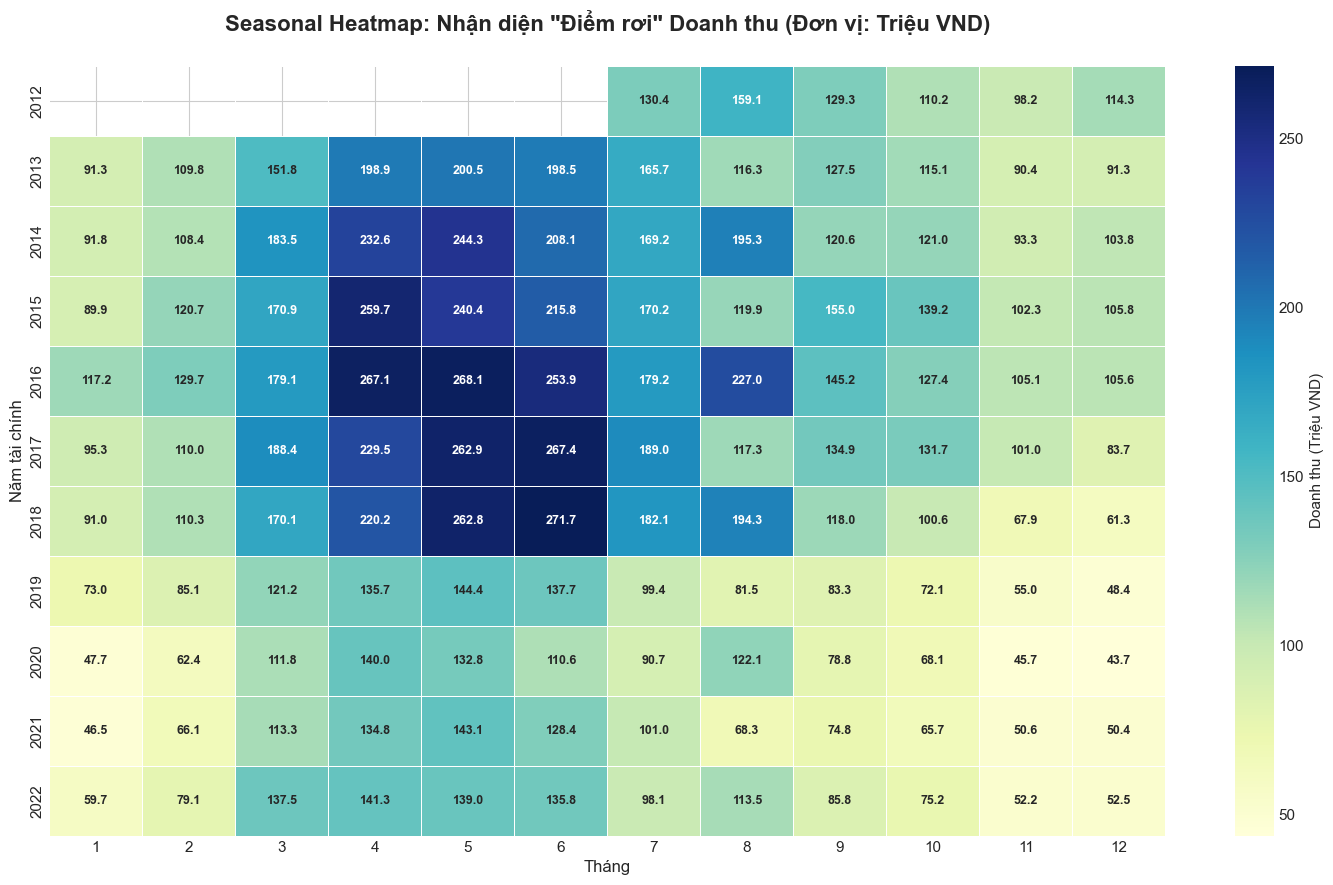

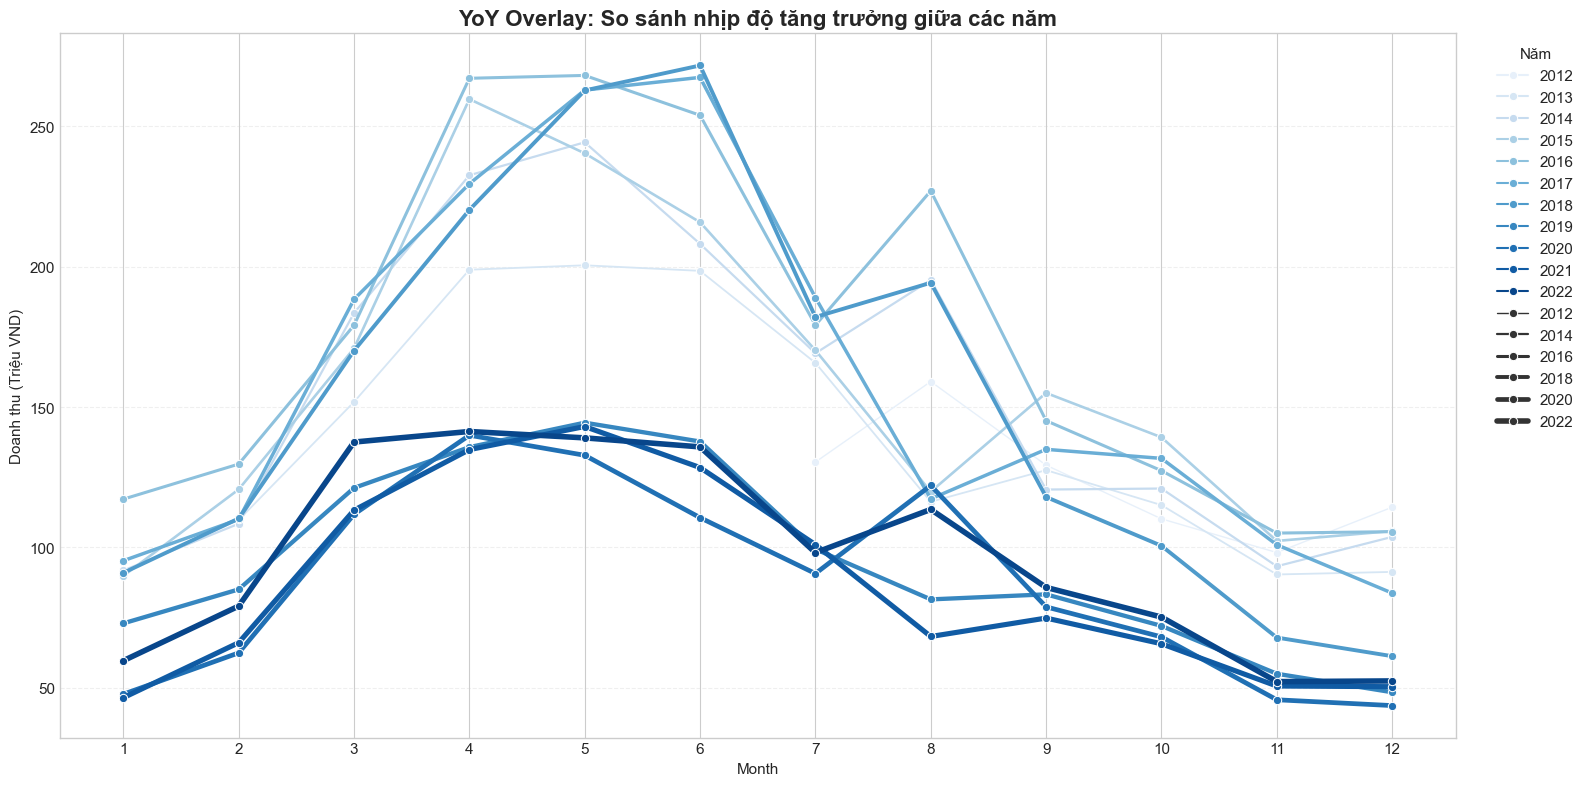

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# --- TIỀN XỬ LÝ (Nên làm một lần) ---
monthly_sales['Year'] = monthly_sales['month_dt'].dt.year
monthly_sales['Month'] = monthly_sales['month_dt'].dt.month
monthly_sales['Revenue_M'] = monthly_sales['Revenue'] / 1e6 # Triệu VND

# --- BIỂU ĐỒ 1: SEASONAL HEATMAP ---
plt.figure(figsize=(18, 10))
heatmap_data = monthly_sales.pivot(index='Year', columns='Month', values='Revenue_M')

sns.heatmap(heatmap_data, 
            cmap='YlGnBu', 
            annot=True, 
            fmt='.1f', 
            linewidths=.5, 
            annot_kws={'size': 9, 'fontweight': 'bold'},
            cbar_kws={'label': 'Doanh thu (Triệu VND)'})

plt.title('Seasonal Heatmap: Nhận diện "Điểm rơi" Doanh thu (Đơn vị: Triệu VND)', 
          fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Năm tài chính', fontsize=12)
plt.xticks(ticks=[i + 0.5 for i in range(12)], labels=range(1, 13))
plt.show()

# --- BIỂU ĐỒ 2: YOY OVERLAY ---
plt.figure(figsize=(16, 8))

# Tạo Palette: Các năm cũ nhạt, năm mới nhất đậm
years = sorted(monthly_sales['Year'].unique())
palette = sns.color_palette("Blues", n_colors=len(years))

# Vẽ Lineplot
# Dùng size='Year' để tự động làm dày đường theo năm (năm lớn = đường dày)
sns.lineplot(data=monthly_sales, 
             x='Month', 
             y='Revenue_M', 
             hue='Year', 
             palette=palette, 
             size='Year',           # Đường năm mới sẽ dày hơn
             sizes=(1, 4),          # Độ dày từ 1 đến 4
             marker='o')

plt.title('YoY Overlay: So sánh nhịp độ tăng trưởng giữa các năm', fontsize=16, fontweight='bold')
plt.xticks(range(1, 13))
plt.ylabel('Doanh thu (Triệu VND)')
plt.legend(title='Năm', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

* **MoM - Biến động ngắn hạn:** Chỉ số MoM dao động cực kỳ mạnh, liên tục đan xen giữa các cột xanh và đỏ. Điều này cho thấy doanh thu phụ thuộc lớn vào các chiến dịch bán hàng ngắn hạn hoặc tính thời điểm của thị trường.
* **YoY - Xu hướng dài hạn:** Chỉ số YoY xác nhận giai đoạn 2018 - 2020 là thời kỳ "khủng hoảng" khi tăng trưởng liên tục ở mức âm (có lúc giảm gần 60% so với cùng kỳ).
* **Tín hiệu phục hồi:** Từ cuối năm 2021 đến 2022, biểu đồ YoY bắt đầu xuất hiện các cột xanh cao trở lại, cho thấy doanh nghiệp đang dần lấy lại đà tăng trưởng sau chu kỳ suy thoái dài.
* **Điểm cần lưu ý:** Dù đã có sự phục hồi, mức độ tăng trưởng vẫn chưa thực sự ổn định. Doanh nghiệp cần duy trì các chỉ số YoY dương một cách bền vững để bù đắp cho các giai đoạn sụt giảm trước đó.

### Phân tích các ngày doanh thu đột biến (Spike Analysis)

Để hiểu rõ hơn về tác động của các chương trình khuyến mãi đặc biệt, chúng ta chuyển từ dữ liệu tổng quát theo tháng sang dữ liệu chi tiết theo ngày. Phần này tập trung vào:
* **Xác định các điểm Spikes:** Tìm kiếm các ngày có doanh thu vượt ngưỡng đột biến (Top 1% cao nhất, tương đương > 13.8 triệu VND).
* **Đánh giá Double Days:** Đo lường hiệu quả thực tế của các ngày hội mua sắm lớn nhất năm thông qua hệ số Spike (Spike Multiplier) và khả năng duy trì doanh số sau sự kiện (Post-spike drop).

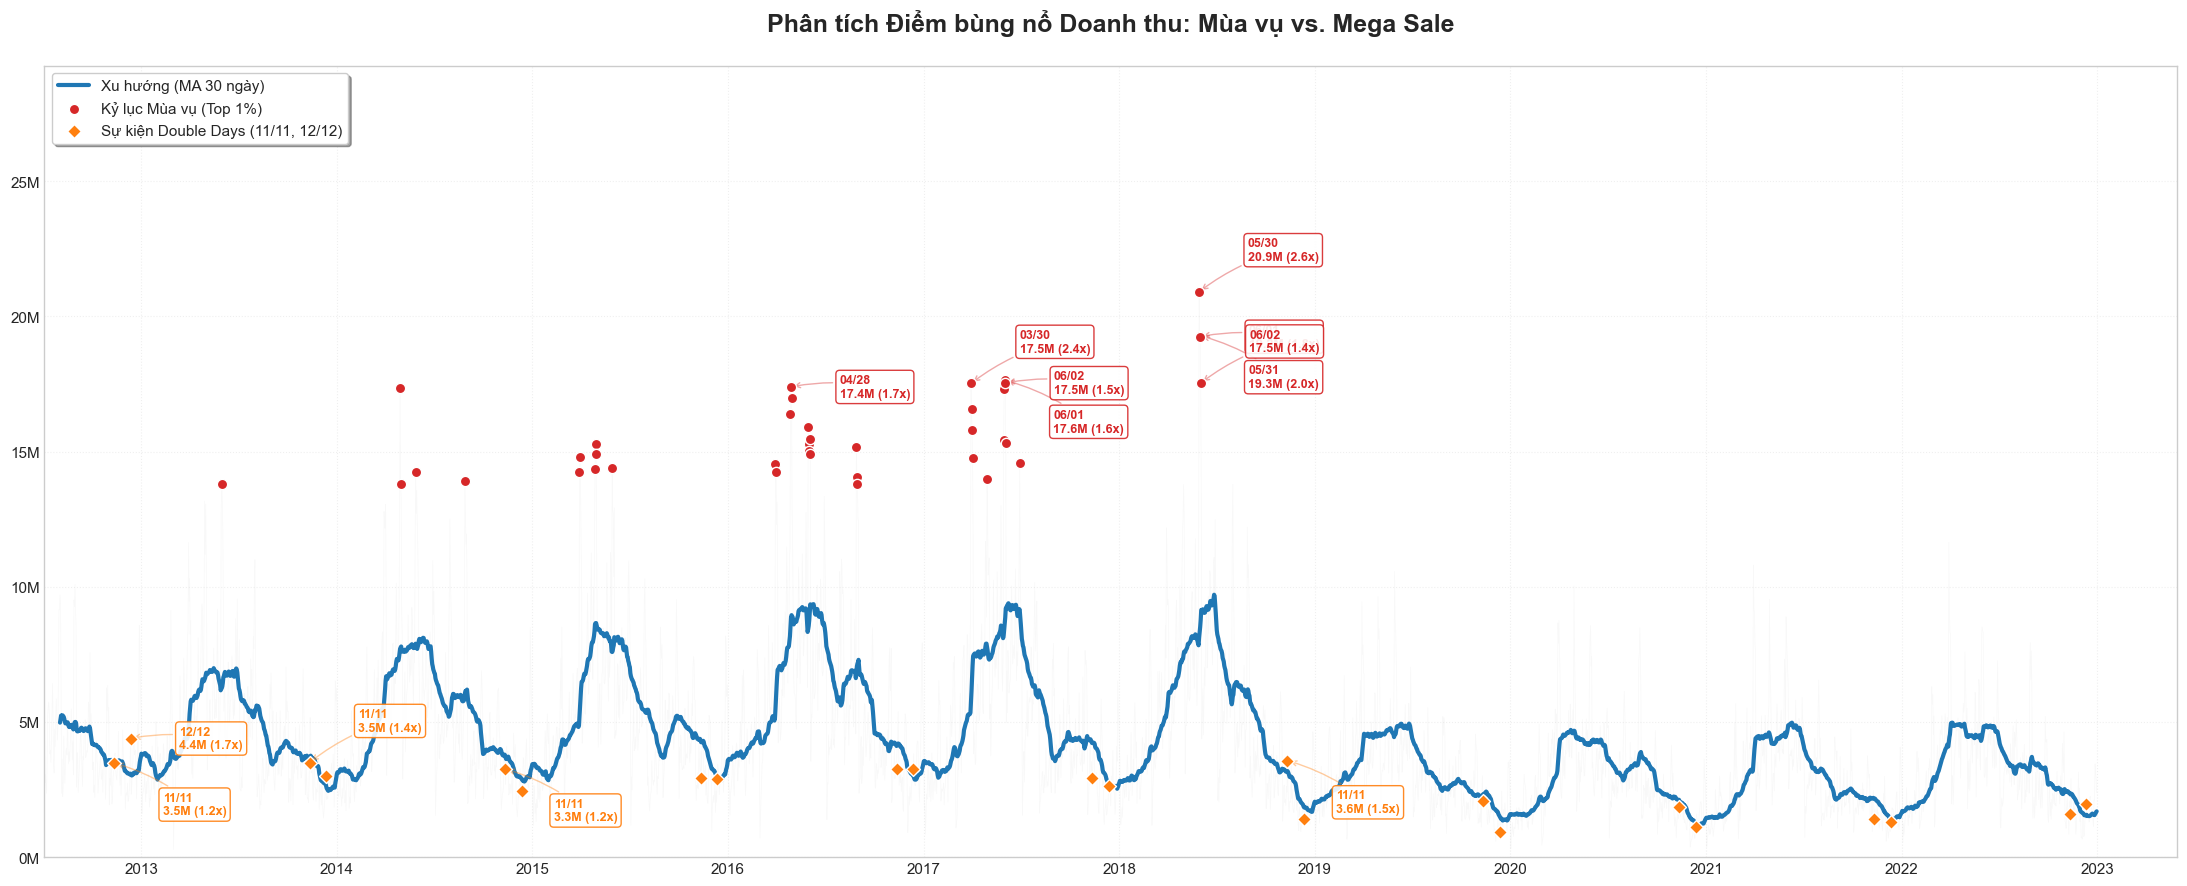


================================ BENCHMARK REPORT: 6 NĂM GẦN NHẤT ===============================
NĂM    | LOẠI ĐỈNH          | NGÀY       | REVENUE      | UPLIFT   | POST-EVENT
-------------------------------------------------------------------------------------
2022   | SEASONAL PEAK      | 03/30      |  11,643,209 |    2.4x |      19.5%
       | DOUBLE DAY         | 12/12      |   1,983,085 |    1.5x |      34.4%
         Đỉnh mùa vụ đang mạnh gấp 5.9 lần ngày hội mua sắm.
-------------------------------------------------------------------------------------
2021   | SEASONAL PEAK      | 03/30      |  10,795,905 |    2.7x |      43.7%
       | DOUBLE DAY         | 11/11      |   1,412,639 |    0.8x |      -9.5%
         Đỉnh mùa vụ đang mạnh gấp 7.6 lần ngày hội mua sắm.
-------------------------------------------------------------------------------------
2020   | SEASONAL PEAK      | 04/29      |  10,020,939 |    2.1x |     -10.4%
       | DOUBLE DAY         | 11/11      |   1,850,

In [33]:
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from datetime import timedelta

# === 1.4 Spike Analysis - Phiên bản Gán nhãn bên phải chuyên nghiệp ===
daily_rev = sales.set_index('Date')['Revenue']

# 1. Xác định các ngưỡng
threshold = daily_rev.quantile(0.99)
spike_days = daily_rev[daily_rev >= threshold]
double_days_mask = ((daily_rev.index.month == 11) & (daily_rev.index.day == 11)) | \
                   ((daily_rev.index.month == 12) & (daily_rev.index.day == 12))
double_days = daily_rev[double_days_mask]

fig, ax = plt.subplots(figsize=(22, 9))

# 2. Vẽ dữ liệu nền
ax.plot(daily_rev.index, daily_rev.values, color='lightgray', alpha=0.15, linewidth=0.5)
ax.plot(daily_rev.rolling(30).mean().index, daily_rev.rolling(30).mean().values,
        color='#1f77b4', linewidth=3, label='Xu hướng (MA 30 ngày)', zorder=2)

# 3. Vẽ các điểm bùng nổ
ax.scatter(spike_days.index, spike_days.values, color='#d62728', s=55, zorder=5, 
           edgecolor='white', label='Kỷ lục Mùa vụ (Top 1%)')
ax.scatter(double_days.index, double_days.values, color='#ff7f0e', marker='D', s=50, zorder=6, 
           edgecolor='white', label='Sự kiện Double Days (11/11, 12/12)')

# --- GIẢI PHÁP CHỐNG TRÀN KHUNG & CHỒNG CHÉO ---
# Nới rộng trục X về bên phải (khoảng 150 ngày) và trục Y (40%) để lấy chỗ ghi chú
ax.set_xlim(daily_rev.index.min(), daily_rev.index.max() + timedelta(days=150))
ax.set_ylim(0, daily_rev.max() * 1.4)

# Chọn lọc các đỉnh tiêu biểu để tránh rối mắt (Top 8 đỉnh và Top 5 Double Days)
highlights = pd.concat([spike_days.sort_values(ascending=False).head(8), 
                        double_days.sort_values(ascending=False).head(5)]).index.unique().sort_values()

for i, dt in enumerate(highlights):
    rev = daily_rev[dt]
    before_7d = daily_rev[(daily_rev.index >= dt - timedelta(days=7)) & (daily_rev.index < dt)].mean()
    multiplier = rev / before_7d if before_7d > 0 else 0
    
    label = f"{dt.strftime('%m/%d')}\n{rev/1e6:.1f}M ({multiplier:.1f}x)"
    color = '#d62728' if dt in spike_days.index else '#ff7f0e'
    
    # Kỹ thuật gán sang PHẢI với độ cao so le (Staggered)
    x_offset = 35 
    y_offset = (i % 3 - 1) * 30 # Tạo ra 3 tầng vị trí: -30, 0, 30 để tránh dính nhau
    
    ax.annotate(label, 
                xy=(dt, rev), 
                xytext=(x_offset, y_offset), 
                textcoords='offset points', 
                fontsize=9, ha='left', va='center', 
                color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color, alpha=0.9),
                arrowprops=dict(arrowstyle='->', color=color, alpha=0.4, 
                                connectionstyle="arc3,rad=0.1")) # Đường dẫn hơi cong

# 4. Định dạng biểu đồ
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

ax.set_title('Phân tích Điểm bùng nổ Doanh thu: Mùa vụ vs. Mega Sale', fontsize=18, fontweight='bold', pad=25)
ax.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(axis='both', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

# === 1.5 Báo cáo Đối chiếu Benchmark: Seasonal vs. Double Day (6 năm gần nhất) ===

# 1. Lấy danh sách 6 năm gần đây nhất có trong dữ liệu
recent_years = sorted(daily_rev.index.year.unique())[-6:]

print(f"\n{'='*32} BENCHMARK REPORT: 6 NĂM GẦN NHẤT {'='*31}")
print(f"{'NĂM':<6} | {'LOẠI ĐỈNH':<18} | {'NGÀY':<10} | {'REVENUE':<12} | {'UPLIFT':<8} | {'POST-EVENT'}")
print("-" * 85)

for year in reversed(recent_years):
    year_data = daily_rev[daily_rev.index.year == year]
    
    # --- A. Tìm Đỉnh Mùa Vụ (Seasonal Peak) của năm đó ---
    peak_dt = year_data.idxmax()
    peak_rev = year_data.max()
    
    # --- B. Tìm Đỉnh Double Day tốt nhất của năm đó ---
    # Lọc 11/11 và 12/12
    dd_mask = ((year_data.index.month == 11) & (year_data.index.day == 11)) | \
              ((year_data.index.month == 12) & (year_data.index.day == 12))
    dd_data = year_data[dd_mask]
    
    if not dd_data.empty:
        dd_dt = dd_data.idxmax()
        dd_rev = dd_data.max()
    else:
        dd_dt, dd_rev = None, 0

    # Hàm phụ để tính các chỉ số nhanh
    def get_metrics(dt, rev):
        if dt is None or rev == 0: return 0, 0
        before = daily_rev[(daily_rev.index >= dt - timedelta(days=7)) & (daily_rev.index < dt)].mean()
        after = daily_rev[(daily_rev.index > dt) & (daily_rev.index <= dt + timedelta(days=7))].mean()
        uplift = rev / before if before > 0 else 0
        cannibal = (after - before) / before * 100 if before > 0 else 0
        return uplift, cannibal

    # Tính toán cho cả hai
    p_up, p_can = get_metrics(peak_dt, peak_rev)
    d_up, d_can = get_metrics(dd_dt, dd_rev)

    # In kết quả theo cặp để dễ so sánh
    print(f"{year:<6} | {'SEASONAL PEAK':<18} | {peak_dt.strftime('%m/%d'):<10} | {peak_rev:>11,.0f} | {p_up:>6.1f}x | {p_can:>9.1f}%")
    if dd_dt:
        print(f"{'':<6} | {'DOUBLE DAY':<18} | {dd_dt.strftime('%m/%d'):<10} | {dd_rev:>11,.0f} | {d_up:>6.1f}x | {d_can:>9.1f}%")
    
    # Tính nhanh sự chênh lệch (Gap) giữa 2 loại đỉnh để highlight
    gap = (peak_rev / dd_rev) if dd_rev > 0 else 0
    print(f"{'':<6}   Đỉnh mùa vụ đang mạnh gấp {gap:.1f} lần ngày hội mua sắm.")
    print("-" * 85)

* **Ngưỡng đột biến:** Các điểm doanh thu cực đại (Top 1% > 13.8M VND) tập trung mật độ cao vào giai đoạn hoàng kim 2014-2018, thưa dần về phía những năm gần đây.
* **Hiệu quả Double Days:** Hệ số Spike của 11/11 và 12/12 không quá bùng nổ, dao động từ **0.8x đến 1.7x**. Điều này cho thấy các sự kiện này tạo ra xung lực doanh thu nhưng chưa đủ sức tạo nên các đỉnh lịch sử mới cho doanh nghiệp.
* **Nghịch lý tháng 12:** Mặc dù có ngày 12/12 với hệ số Spike khá tốt (thường > 1.3x), nhưng tháng 12 lại là tháng thấp điểm nhất năm (seasonal factor chỉ 0.57x). Điều này chứng tỏ ngày Double Day chỉ là điểm sáng ngắn hạn, không thay đổi được đặc tính mùa vụ thấp điểm của cả tháng.
* **Tín hiệu tích cực:** Chỉ số "Post-spike drop" đa phần mang giá trị dương, cho thấy doanh thu thường có xu hướng ổn định hoặc tăng nhẹ sau ngày lễ thay vì sụt giảm ngay lập tức, giúp duy trì nhịp độ bán hàng.

### Phân tích Chất lượng Tăng trưởng: Volume vs AOV

Để hiểu rõ bản chất của sự thay đổi doanh thu qua các năm, chúng ta cần xem xét mối quan hệ giữa **Số lượng đơn hàng (Volume)** và **Giá trị đơn hàng trung bình (AOV)**. Phân tích này sẽ giúp xác định doanh nghiệp đang tăng trưởng dựa trên việc mở rộng tệp khách hàng (số lượng) hay tập trung vào giá trị trên mỗi giao dịch (chất lượng).

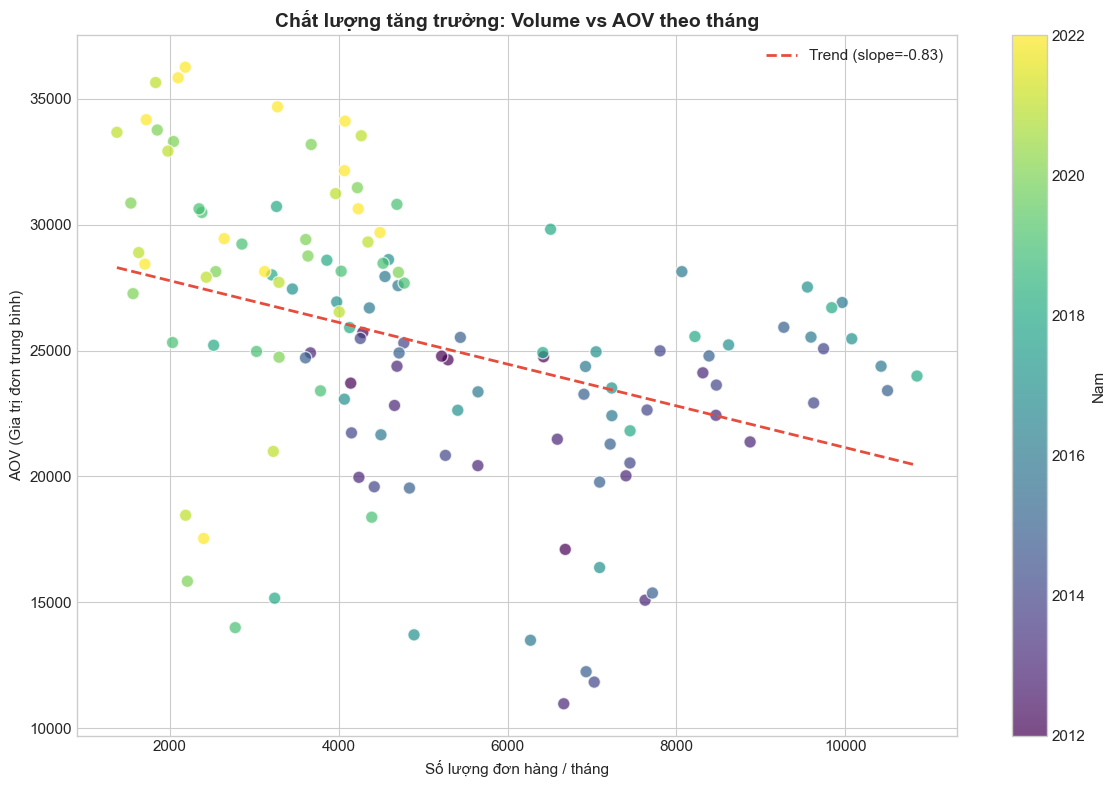

Xu hướng AOV GIẢM khi volume tăng -> Tăng truong bằng số lượng, khong phải chất lượng


In [9]:
# === 1.5 Volume vs AOV (Chat lượng tang truong) ===
monthly_kpi = orders.groupby('order_month').agg(
    order_count=('order_id', 'count'),
    total_revenue=('total_amount', 'sum')
).dropna()
monthly_kpi['AOV'] = monthly_kpi['total_revenue'] / monthly_kpi['order_count']

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(monthly_kpi['order_count'], monthly_kpi['AOV'],
                     c=monthly_kpi.index.year, cmap='viridis', s=80, alpha=0.7, edgecolors='white')
plt.colorbar(scatter, label='Nam')
ax.set_xlabel('Số lượng đơn hàng / tháng')
ax.set_ylabel('AOV (Gia trị đơn trung bình)')
ax.set_title('Chất lượng tăng trưởng: Volume vs AOV theo tháng')

# Trend line
z = np.polyfit(monthly_kpi['order_count'], monthly_kpi['AOV'], 1)
p = np.poly1d(z)
x_line = np.linspace(monthly_kpi['order_count'].min(), monthly_kpi['order_count'].max(), 100)
ax.plot(x_line, p(x_line), '--', color=COLOR_NEG, linewidth=2, label=f'Trend (slope={z[0]:.2f})')
ax.legend()
plt.tight_layout()
plt.show()

if z[0] < 0:
    print("Xu hướng AOV GIẢM khi volume tăng -> Tăng truong bằng số lượng, khong phải chất lượng")
else:
    print("AOV tăng cùng volume -> Tăng trưởngng bền vững")

### Nhận xét về mối quan hệ giữa Volume và AOV
* **Tương quan nghịch rõ rệt:** Đường xu hướng có hệ số góc **-0.83**, cho thấy sự đánh đổi: khi số lượng đơn hàng tăng cao thì giá trị trung bình mỗi đơn lại có xu hướng giảm xuống.
* **Sự chuyển dịch theo thời gian:** Có sự phân hóa rõ rệt giữa các giai đoạn. Những năm đầu (2012-2016 - màu tối) nằm ở vùng Volume cao nhưng AOV thấp.
* **Thay đổi chiến lược (2020-2022):** Các điểm màu vàng (gần đây) tập trung ở phía trên bên trái, cho thấy doanh nghiệp đã chuyển sang mô hình ưu tiên **giá trị đơn hàng cao** thay vì chạy theo số lượng.
* **Rủi ro quy mô:** Dù AOV tăng trưởng ấn tượng trong những năm gần đây, nhưng số lượng đơn hàng lại sụt giảm mạnh so với quá khứ, dẫn đến tổng doanh thu khó bứt phá.
* **Kết luận:** Doanh nghiệp đang tối ưu hóa tốt giá trị trên mỗi khách hàng nhưng cần có chiến lược để kéo lại quy mô đơn hàng nhằm tận dụng tối đa năng lực vận hành.

## Tổng kết, Dự báo & Đề xuất hành động (Strategic Recommendations)

### **Dự báo & Đánh giá rủi ro**
* **Dự báo:** Nếu tiếp tục duy trì mô hình hiện tại, doanh thu sẽ tiếp tục đi ngang hoặc giảm nhẹ do sự sụt giảm về quy mô đơn hàng (Volume). Biên lợi nhuận sẽ vẫn chịu rủi ro lớn từ các tháng có lợi nhuận âm nếu không kiểm soát chặt chẽ chi phí khuyến mãi.

### **Đề xuất hành động thực tiễn (Actionable Insights)**
1. **Kiểm soát ngưỡng chiết khấu (Safety Floor):** Thiết lập mức giảm giá tối đa cho các chiến dịch (ví dụ 11/11, 12/12) để đảm bảo Gross Margin không bao giờ dưới 5%. Loại bỏ ngay các chương trình "đốt tiền" không mang lại hiệu quả giữ chân khách hàng.
2. **Chiến lược "Rổ hàng thông minh":** Vì AOV đang tăng nhưng Volume giảm, doanh nghiệp nên triển khai các gói combo (cross-selling) để tăng số lượng sản phẩm trên mỗi đơn hàng mà không làm giảm giá trị đơn trung bình.
3. **Tối ưu hóa tồn kho theo mùa vụ:** Tập trung nguồn lực và hàng hóa tối đa cho đợt cao điểm tháng 5 (Seasonal factor 1.55x). Đối với tháng 12 (thấp điểm), thay vì giảm giá sâu, hãy chuyển sang hình thức tặng quà hoặc tích điểm để bảo vệ biên lợi nhuận.
4. **Tập trung vào khách hàng cũ (Retention):** Với 66.1% đơn hàng phát sinh trước ngày đăng ký/sự kiện, việc triển khai chiến dịch Remarketing cho tệp khách hàng cũ sẽ ít tốn kém và hiệu quả hơn so với việc tìm kiếm khách hàng mới trong giai đoạn doanh thu đang bão hòa.

---
# PHASE 2: Acquisition va Channel Performance (Dau vao pheu)
**Muc tieu**: Danh gia hieu qua cac kenh Marketing va chat luong khach hang.

> **Cau hoi kinh doanh**: Tien do vao kenh nao la hieu qua nhat? Khach hang den tu dau?

### Hiệu suất Kênh Tiếp thị & Hành vi người dùng (Acquisition & Web Traffic)

Tại phần này, chúng ta kết hợp số liệu kinh doanh (Khách hàng, AOV) với số liệu kỹ thuật website (Sessions, Bounce Rate) để đánh giá toàn diện phễu đầu vào. Mục tiêu là xác định kênh nào đang mang lại lưu lượng lớn nhất và liệu chất lượng truy cập giữa các kênh có sự khác biệt hay không.

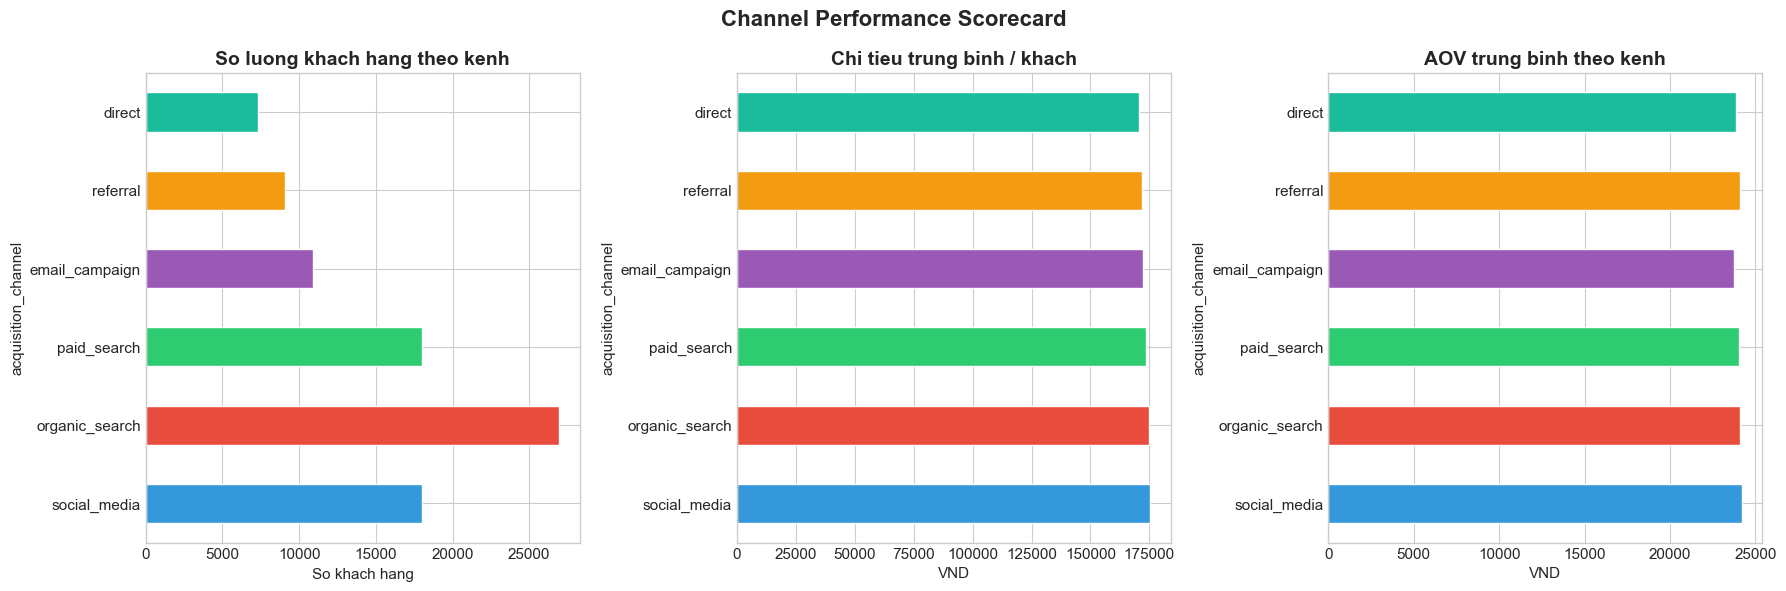


=== Channel Performance Table ===
                     customer_count  avg_orders  avg_spent  avg_aov
acquisition_channel                                                
social_media                  18002         7.0   175458.0  24198.0
organic_search                26950         7.0   174849.0  24096.0
paid_search                   17999         7.0   173475.0  24037.0
email_campaign                10886         7.0   172415.0  23752.0
referral                       9072         7.0   171956.0  24114.0
direct                         7337         7.0   170481.0  23860.0


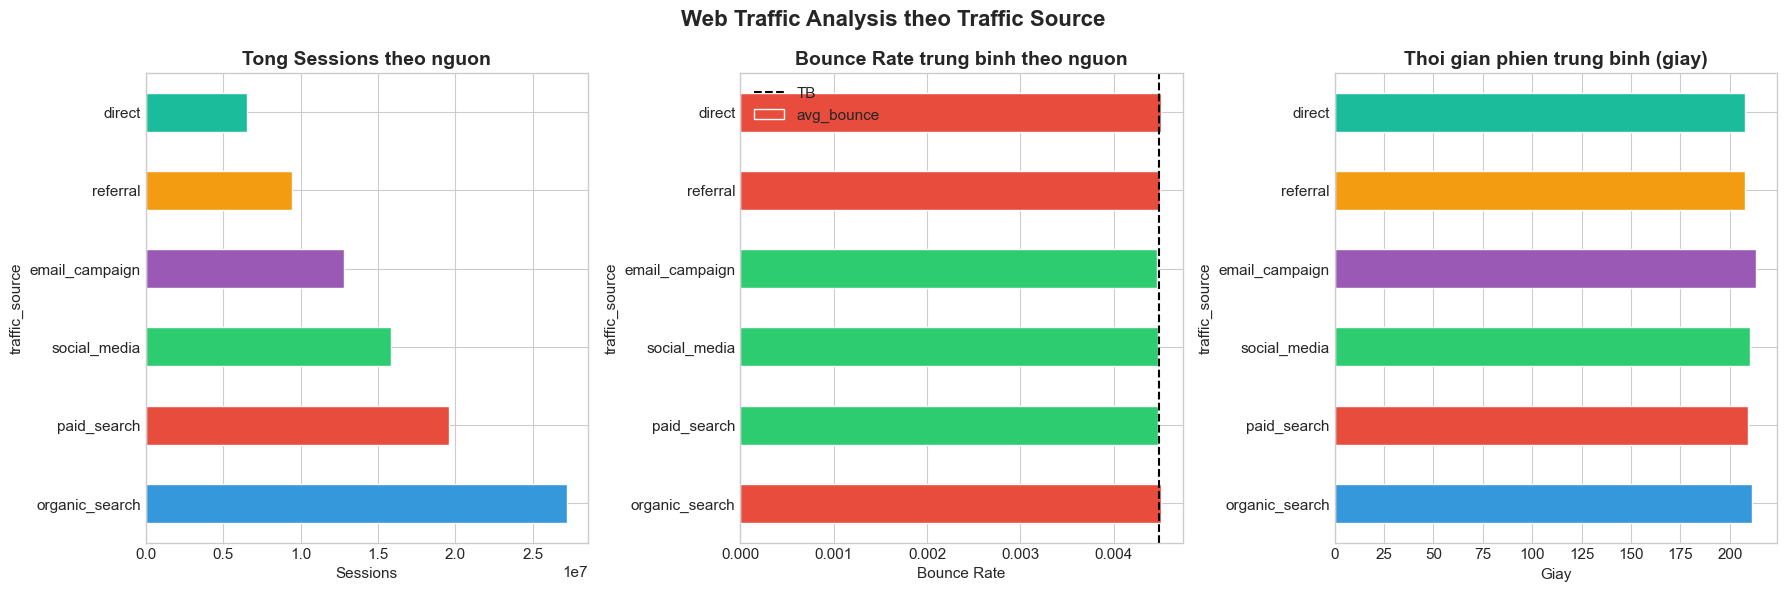

In [10]:
# === 2.1 Channel Performance Scorecard ===
# Acquisition channel tu customers
channel_stats = customers.merge(
    orders.groupby('customer_id').agg(
        order_count=('order_id', 'count'),
        total_spent=('total_amount', 'sum')
    ), on='customer_id', how='inner'
)
channel_stats['AOV'] = channel_stats['total_spent'] / channel_stats['order_count']

channel_summary = channel_stats.groupby('acquisition_channel').agg(
    customer_count=('customer_id', 'count'),
    avg_orders=('order_count', 'mean'),
    avg_spent=('total_spent', 'mean'),
    avg_aov=('AOV', 'mean')
).sort_values('avg_spent', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# So luong khach
channel_summary['customer_count'].plot(kind='barh', ax=axes[0], color=PALETTE, edgecolor='white')
axes[0].set_title('So luong khach hang theo kenh')
axes[0].set_xlabel('So khach hang')

# Trung binh chi tieu
channel_summary['avg_spent'].plot(kind='barh', ax=axes[1], color=PALETTE, edgecolor='white')
axes[1].set_title('Chi tieu trung binh / khach')
axes[1].set_xlabel('VND')

# AOV
channel_summary['avg_aov'].plot(kind='barh', ax=axes[2], color=PALETTE, edgecolor='white')
axes[2].set_title('AOV trung binh theo kenh')
axes[2].set_xlabel('VND')

plt.suptitle('Channel Performance Scorecard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Channel Performance Table ===")
print(channel_summary.round(0).to_string())

# === 2.2 Web Traffic va Conversion Analysis ===
# Traffic theo source
traffic_by_source = web_traffic.groupby('traffic_source').agg(
    total_sessions=('sessions', 'sum'),
    avg_bounce=('bounce_rate', 'mean'),
    avg_duration=('avg_session_duration_sec', 'mean'),
    total_visitors=('unique_visitors', 'sum')
).sort_values('total_sessions', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Sessions by source
traffic_by_source['total_sessions'].plot(kind='barh', ax=axes[0], color=PALETTE, edgecolor='white')
axes[0].set_title('Tong Sessions theo nguon')
axes[0].set_xlabel('Sessions')

# Bounce rate
colors_bounce = [COLOR_NEG if v > traffic_by_source['avg_bounce'].mean() else COLOR_POS
                 for v in traffic_by_source['avg_bounce']]
traffic_by_source['avg_bounce'].plot(kind='barh', ax=axes[1], color=colors_bounce, edgecolor='white')
axes[1].axvline(traffic_by_source['avg_bounce'].mean(), color='black', linestyle='--', label='TB')
axes[1].set_title('Bounce Rate trung binh theo nguon')
axes[1].set_xlabel('Bounce Rate')
axes[1].legend()

# Avg duration
traffic_by_source['avg_duration'].plot(kind='barh', ax=axes[2], color=PALETTE, edgecolor='white')
axes[2].set_title('Thoi gian phien trung binh (giay)')
axes[2].set_xlabel('Giay')

plt.suptitle('Web Traffic Analysis theo Traffic Source', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Nhận xét về Hiệu suất Kênh và Chất lượng Truy cập
* **Kênh chủ lực:** **Organic Search** là nguồn quan trọng nhất, dẫn đầu tuyệt đối cả về lưu lượng truy cập (~2.7x10^7 sessions) và số lượng khách hàng (~27k khách).
* **Tính đồng nhất kỳ lạ:** Một điểm cực kỳ đặc biệt là các chỉ số chất lượng như **AOV (~24k VND)**, **Bounce Rate (~0.45%)** và **Thời gian phiên (~210s)** gần như tương đương nhau trên mọi kênh. 
* **Hiệu quả phễu:** Tỷ lệ chuyển đổi từ Traffic sang Khách hàng rất ổn định. Khách hàng dù đến từ nguồn tự nhiên hay trả phí (Social, Paid Search) đều có hành vi tương tác và mức chi tiêu y hệt nhau.
* **Đánh giá giá trị:** **Social Media** và **Direct** dù có số lượng khách hàng thấp hơn nhưng vẫn duy trì được giá trị đơn hàng (AOV) ở mức cao nhất hệ thống.
* **Kết luận:** Doanh nghiệp đang có một hệ thống vận hành rất ổn định. Chiến lược tăng trưởng lúc này nên tập trung vào việc **tăng quy mô (Scale)** lưu lượng truy cập ở những kênh có chi phí thấp vì chất lượng khách hàng đã được đảm bảo đồng đều.

### Ma trận Chiến lược Kênh (Channel Quality Quadrant)

Để có cái nhìn tổng thể về giá trị thực tế của từng nguồn khách hàng, chúng ta đưa các kênh vào ma trận Quadrant. Việc phân loại này giúp doanh nghiệp xác định đâu là kênh mang lại "lượng" (Volume) và đâu là kênh mang lại "chất" (AOV), từ đó tối ưu hóa ngân sách tiếp thị một cách chính xác hơn.

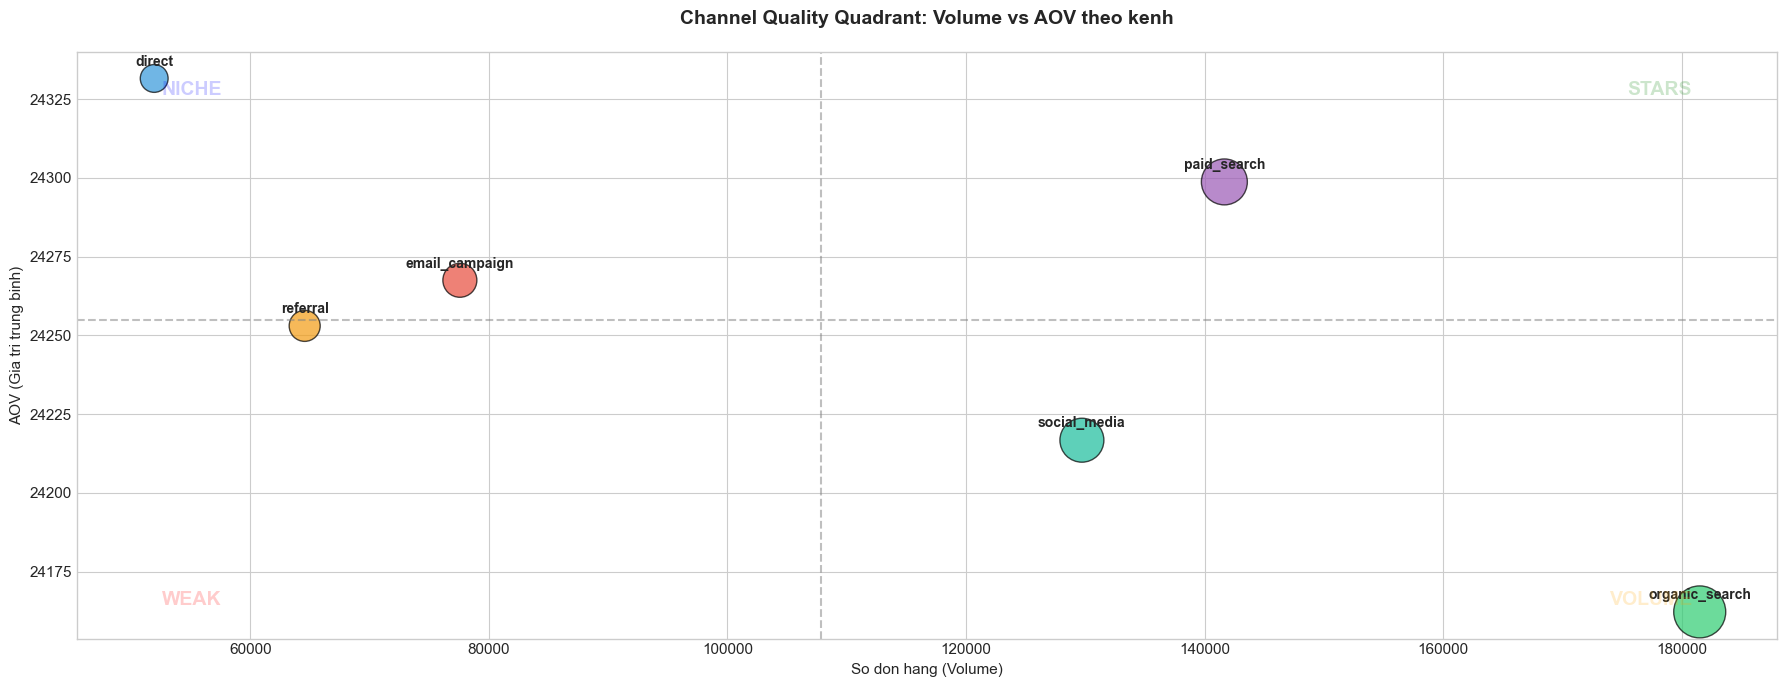

In [11]:

source_stats = orders.groupby('order_source').agg(
    order_count=('order_id', 'count'),
    avg_amount=('total_amount', 'mean'),
    total_rev=('total_amount', 'sum')
).dropna()

source_stats['share'] = source_stats['order_count'] / source_stats['order_count'].sum() * 100


# === 2.4 Channel Quality Quadrant (Bản sửa lỗi khoảng trắng) ===
fig, ax = plt.subplots(figsize=(18, 7)) # Giảm chiều rộng để biểu đồ cân đối hơn

scatter = ax.scatter(source_stats['order_count'], source_stats['avg_amount'],
                     s=source_stats['share'] * 50, alpha=0.7, 
                     color=PALETTE[:len(source_stats)],
                     edgecolors='black', linewidth=1)

# Annotate tên các kênh
for name, row in source_stats.iterrows():
    ax.annotate(name, (row['order_count'], row['avg_amount']),
                fontsize=10, ha='center', va='bottom', fontweight='bold',
                xytext=(0, 7), textcoords='offset points')

# Đường trung bình
ax.axhline(source_stats['avg_amount'].mean(), color='gray', linestyle='--', alpha=0.5)
ax.axvline(source_stats['order_count'].mean(), color='gray', linestyle='--', alpha=0.5)

# --- PHẦN QUAN TRỌNG: Ghi nhãn Quadrant dùng tọa độ tương đối (0 -> 1) ---
# transform=ax.transAxes giúp chữ luôn nằm cố định trong khung, không đẩy khung ra ngoài
ax.text(0.95, 0.95, 'STARS', transform=ax.transAxes, fontsize=14, 
        ha='right', va='top', alpha=0.2, fontweight='bold', color='green')

ax.text(0.05, 0.95, 'NICHE', transform=ax.transAxes, fontsize=14, 
        ha='left', va='top', alpha=0.2, fontweight='bold', color='blue')

ax.text(0.95, 0.05, 'VOLUME', transform=ax.transAxes, fontsize=14, 
        ha='right', va='bottom', alpha=0.2, fontweight='bold', color='orange')

ax.text(0.05, 0.05, 'WEAK', transform=ax.transAxes, fontsize=14, 
        ha='left', va='bottom', alpha=0.2, fontweight='bold', color='red')

ax.set_xlabel('So don hang (Volume)')
ax.set_ylabel('AOV (Gia tri trung binh)')
ax.set_title('Channel Quality Quadrant: Volume vs AOV theo kenh', pad=20)

# tight_layout giúp cắt bỏ mọi lề thừa xung quanh
plt.tight_layout()
plt.show()



### Nhận định về tính đồng nhất của hệ thống
* **Nghịch lý ma trận:** Dù được phân chia vào các nhóm Stars hay Niche, thực tế sự chênh lệch AOV giữa các kênh chỉ chưa đầy **0.7%**. Đây là mức biến động cực nhỏ, cho thấy giá trị đơn hàng đã đạt trạng thái bão hòa trên toàn hệ thống.
* **Sức mạnh tuyệt đối của Organic Search:** Với quy mô hơn 180,000 đơn hàng, Organic Search đóng góp doanh thu áp đảo. Khoảng cách "nhỉnh hơn" về AOV của nhóm Direct không mang lại nhiều ý nghĩa về mặt tài chính khi so với lợi thế quy mô của nhóm Volume.
* **Kết luận chiến lược:** Doanh nghiệp không nên tốn nguồn lực để cố gắng phân hóa AOV theo kênh. Thay vào đó, hãy tập trung vào việc **nhân bản (Replicate)** thành công của Organic Search sang các kênh khác để tối ưu hóa tổng doanh thu dựa trên số lượng đơn hàng.

### Xu hướng Lưu lượng và Chất lượng truy cập theo thời gian

Để đánh giá sự bền vững của hệ thống, chúng ta cần quan sát biến động của lưu lượng truy cập (Sessions) và chất lượng trải nghiệm (Bounce Rate) trong dài hạn. Phân tích này giúp xác định:
* Doanh nghiệp có đang duy trì được tốc độ tăng trưởng quy mô tiếp cận hay không?
* Tỷ lệ thoát có biến động bất thường khi lượng truy cập tăng cao hay không?

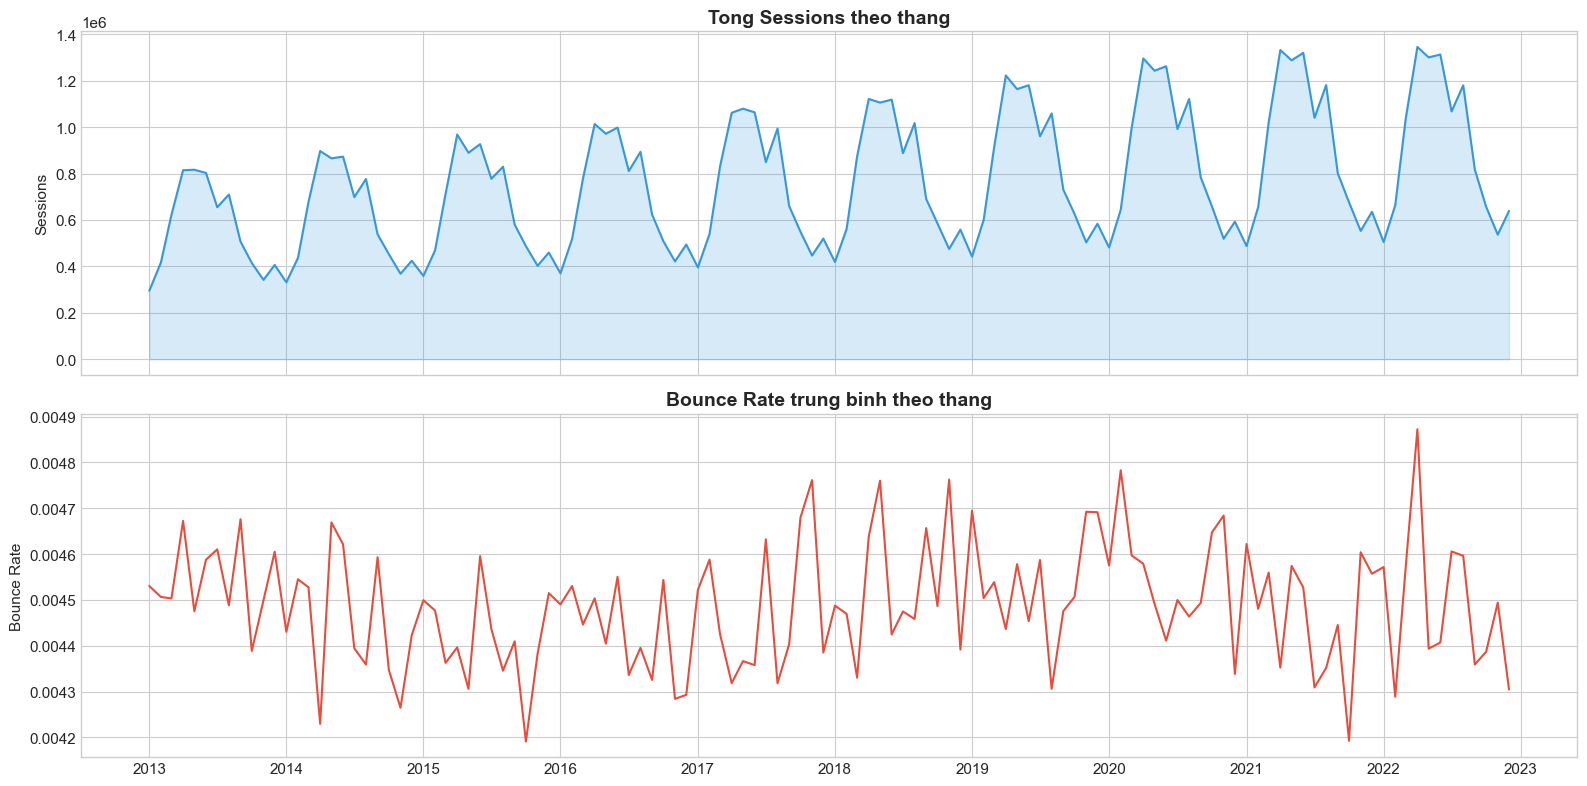

In [12]:

# Traffic trend
monthly_traffic = web_traffic.groupby(web_traffic['date'].dt.to_period('M')).agg(
    sessions=('sessions', 'sum'), bounce=('bounce_rate', 'mean'))
monthly_traffic.index = monthly_traffic.index.to_timestamp()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
ax1.plot(monthly_traffic.index, monthly_traffic['sessions'], color=COLOR_PRIMARY, linewidth=1.5)
ax1.fill_between(monthly_traffic.index, monthly_traffic['sessions'], alpha=0.2, color=COLOR_PRIMARY)
ax1.set_title('Tong Sessions theo thang')
ax1.set_ylabel('Sessions')

ax2.plot(monthly_traffic.index, monthly_traffic['bounce'], color=COLOR_NEG, linewidth=1.5)
ax2.set_title('Bounce Rate trung binh theo thang')
ax2.set_ylabel('Bounce Rate')

plt.tight_layout()
plt.show()

### Nhận xét về Xu hướng Sessions và Bounce Rate (2013 - 2022)
* **Tăng trưởng lưu lượng bền vững:** Tổng Sessions có xu hướng tăng trưởng dài hạn rõ rệt, đạt đỉnh mới sau mỗi chu kỳ năm. Điều này cho thấy nỗ lực thu hút người dùng của doanh nghiệp đang rất hiệu quả.
* **Tính mùa vụ lặp lại:** Biểu đồ Sessions thể hiện quy luật mùa vụ cực kỳ ổn định, khớp với các phân tích doanh thu ở Phase 1, khẳng định lưu lượng truy cập là động lực chính thúc đẩy doanh số.
* **Bounce Rate cực kỳ ổn định:** Tỷ lệ thoát duy trì ở mức rất thấp (dao động từ **0.42% - 0.49%**). Điều này cho thấy dù lượng truy cập tăng gấp 3-4 lần sau 10 năm, chất lượng nội dung website vẫn giữ chân người dùng cực tốt.
* **Mối tương quan nghịch nhẹ:** Tại các thời điểm Sessions đạt đỉnh (peak), Bounce Rate thường có xu hướng nhỉnh lên. Đây là hiện tượng bình thường khi lượng truy cập lớn có thể kéo theo một phần khách hàng ít tiềm năng hơn.
* **Kết luận:** Website đang vận hành với hiệu suất kỹ thuật và nội dung rất tốt. Thách thức lớn nhất hiện nay không phải là giữ chân người dùng mà là làm sao để tiếp tục mở rộng quy mô Sessions trong bối cảnh thị trường ngày càng cạnh tranh.

## 2.3. Phân tích Thiết bị và Ma trận Chất lượng Kênh

Để hoàn thiện bức tranh về chân dung khách hàng ở giai đoạn Acquisition, chúng ta cần tìm hiểu:
* **Hành vi thiết bị:** Khách hàng ưu tiên đặt hàng qua nền tảng nào (Mobile, Desktop hay Tablet) và thiết bị có ảnh hưởng đến giá trị đơn hàng không?

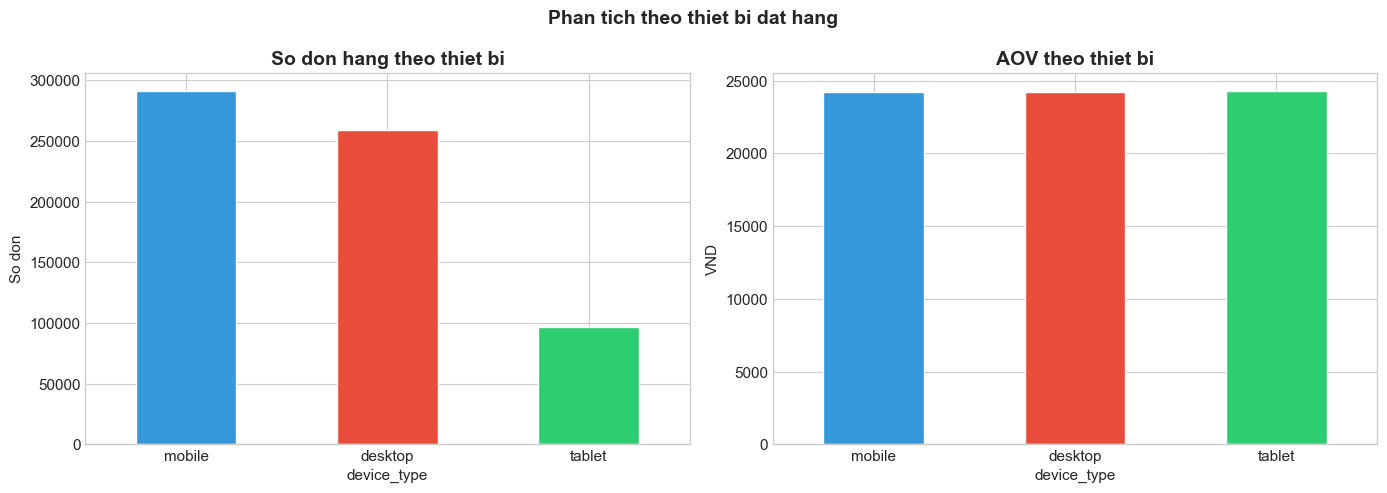

In [13]:
# === 2.3 Device Type Analysis ===
device_stats = orders.groupby('device_type').agg(
    order_count=('order_id', 'count'),
    avg_amount=('total_amount', 'mean')
).sort_values('order_count', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
device_stats['order_count'].plot(kind='bar', ax=ax1, color=PALETTE, edgecolor='white')
ax1.set_title('So don hang theo thiet bi')
ax1.set_ylabel('So don')
ax1.tick_params(axis='x', rotation=0)

device_stats['avg_amount'].plot(kind='bar', ax=ax2, color=PALETTE, edgecolor='white')
ax2.set_title('AOV theo thiet bi')
ax2.set_ylabel('VND')
ax2.tick_params(axis='x', rotation=0)

plt.suptitle('Phan tich theo thiet bi dat hang', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



### Nhận xét về Thiết bị và Chất lượng Kênh
* **Mobile là trọng tâm:** Mobile dẫn đầu về số lượng đơn hàng (~290k đơn), theo sát là Desktop. Tuy nhiên, **AOV hoàn toàn đồng nhất (~24k VND)** trên mọi thiết bị. Điều này cho thấy trải nghiệm mua sắm đã được tối ưu tốt trên đa nền tảng.


### Insights Phase 2: Acquisition

**Descriptive**: Organic Search mang lai luong khach hang deu dan. Bounce rate va thoi gian
phien truy cap khac biet ro ret giua cac kenh.

**Diagnostic**: Kenh co bounce rate cao cho thay chat luong traffic kem, co the do
landing page khong phu hop hoac target audience sai. Device type anh huong den AOV.

**Predictive**: Neu tiep tuc do tien vao kenh bounce rate cao, ty le chuyen doi se
tiep tuc thap, lang phi ngan sach marketing.

**Prescriptive**: (1) Reallocate budget tu kenh bounce rate cao sang kenh AOV cao.
(2) Toi uu landing page cho mobile (neu AOV mobile thap hon desktop).
(3) Tap trung vao kenh "Stars" (high volume + high AOV).

---
# PHASE 3: Product Portfolio va Fashion Assortment (Linh hon san pham)
**Muc tieu**: Toi uu hoa danh muc hang hoa, phat hien co hoi va rui ro theo dac thu nganh thoi trang.

> **Cau hoi kinh doanh**: San pham nao tao gia tri? Size/Color nao dang mat doanh thu do het hang?

### Phân tích ABC Pareto: Trọng tâm danh mục sản phẩm

Trong kinh doanh thời trang, không phải sản phẩm nào cũng đóng góp giá trị như nhau. Chúng ta áp dụng phương pháp phân loại **ABC Analysis** dựa trên nguyên lý Pareto (80/20) để xác định "những mặt hàng sống còn":
* **Nhóm A (Sản phẩm cốt lõi):** Chiếm tỷ trọng nhỏ về số lượng mã hàng nhưng đóng góp phần lớn doanh thu.
* **Nhóm B (Sản phẩm tiềm năng):** Nhóm sản phẩm trung bình, cần theo dõi để đẩy lên nhóm A hoặc kiểm soát chi phí.
* **Nhóm C (Sản phẩm đuôi dài):** Chiếm số lượng lớn trong kho nhưng đóng góp doanh thu rất thấp, tiềm ẩn rủi ro đọng vốn.

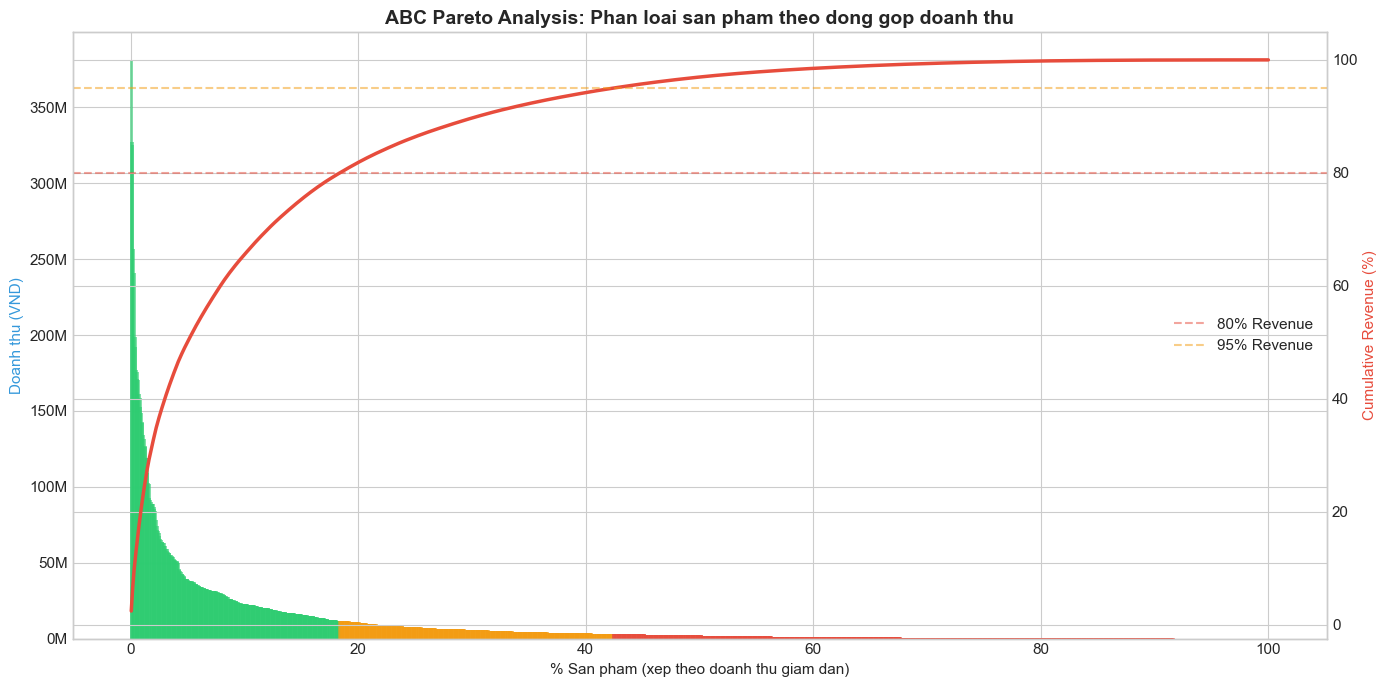


=== ABC Classification Summary ===
           product_count  pct_products  pct_revenue
ABC_class                                          
A                    293          18.3         79.9
B                    384          24.0         15.1
C                    921          57.6          5.0

=== So san pham A/B/C theo Category ===
ABC_class     A    B    C
category                 
Casual        9   24   81
GenZ          9   19   83
Outdoor      50  118  328
Streetwear  225  223  429


In [14]:
# === 3.1 ABC Analysis (Pareto) - Phan loai san pham ===
product_revenue = order_items.groupby('product_id')['item_revenue'].sum().sort_values(ascending=False).reset_index()
product_revenue.columns = ['product_id', 'total_revenue']
product_revenue = product_revenue.merge(products[['product_id', 'product_name', 'category', 'segment']], on='product_id')
product_revenue['cumulative_pct'] = product_revenue['total_revenue'].cumsum() / product_revenue['total_revenue'].sum() * 100
product_revenue['rank'] = range(1, len(product_revenue) + 1)
product_revenue['rank_pct'] = product_revenue['rank'] / len(product_revenue) * 100

# Phan loai ABC
product_revenue['ABC_class'] = 'C'
product_revenue.loc[product_revenue['cumulative_pct'] <= 80, 'ABC_class'] = 'A'
product_revenue.loc[(product_revenue['cumulative_pct'] > 80) & (product_revenue['cumulative_pct'] <= 95), 'ABC_class'] = 'B'

fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar chart revenue
colors_abc = {'A': COLOR_POS, 'B': '#f39c12', 'C': COLOR_NEG}
bar_colors = [colors_abc[c] for c in product_revenue['ABC_class']]
ax1.bar(product_revenue['rank_pct'], product_revenue['total_revenue'], width=0.3, color=bar_colors, alpha=0.6)
ax1.set_xlabel('% San pham (xep theo doanh thu giam dan)')
ax1.set_ylabel('Doanh thu (VND)', color=COLOR_PRIMARY)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# Cumulative line
ax2 = ax1.twinx()
ax2.plot(product_revenue['rank_pct'], product_revenue['cumulative_pct'], color=COLOR_NEG, linewidth=2.5)
ax2.axhline(80, color=COLOR_NEG, linestyle='--', alpha=0.5, label='80% Revenue')
ax2.axhline(95, color='#f39c12', linestyle='--', alpha=0.5, label='95% Revenue')
ax2.set_ylabel('Cumulative Revenue (%)', color=COLOR_NEG)
ax2.legend(loc='center right')

ax1.set_title('ABC Pareto Analysis: Phan loai san pham theo dong gop doanh thu')
plt.tight_layout()
plt.show()

# Summary
abc_summary = product_revenue.groupby('ABC_class').agg(
    product_count=('product_id', 'count'),
    total_rev=('total_revenue', 'sum')
)
abc_summary['pct_products'] = abc_summary['product_count'] / abc_summary['product_count'].sum() * 100
abc_summary['pct_revenue'] = abc_summary['total_rev'] / abc_summary['total_rev'].sum() * 100
print("\n=== ABC Classification Summary ===")
print(abc_summary[['product_count', 'pct_products', 'pct_revenue']].round(1).to_string())

# ABC x Category cross-tab
abc_cat = product_revenue.groupby(['category', 'ABC_class']).size().unstack(fill_value=0)
print("\n=== So san pham A/B/C theo Category ===")
print(abc_cat.to_string())

### Nhận xét về danh mục sản phẩm theo quy luật Pareto
* **Sự vận hành hoàn hảo của quy luật 80/20:** Nhóm A chỉ chiếm **18.3%** số lượng sản phẩm nhưng mang lại gần **80% tổng doanh thu**. Đây là 293 mã hàng "ngôi sao" mà doanh nghiệp tuyệt đối không được để xảy ra tình trạng hết hàng (stock-out).
* **Gánh nặng từ nhóm C:** Có tới **921 sản phẩm** (chiếm hơn 57% danh mục) nhưng chỉ đóng góp vỏn vẹn **5% doanh thu**. Đây là nhóm cần được thanh lọc hoặc giảm nhập hàng để giải phóng không gian kho bãi và dòng vốn.
* **Streetwear là "át chủ bài":** Trong 293 sản phẩm nhóm A, có đến **225 mã thuộc ngành hàng Streetwear**. Điều này khẳng định Streetwear chính là thế mạnh cốt lõi và là định dạng thương hiệu của doanh nghiệp.
* **Hạn chế của nhóm Casual và GenZ:** Hai ngành hàng này có số lượng sản phẩm nhóm A rất ít (chỉ 9 mã mỗi loại). Điều này cho thấy các thiết kế trong nhóm này chưa thực sự phù hợp với thị hiếu hoặc chưa được đầu tư marketing đúng mức.
* **Kết luận:** Doanh nghiệp nên tập trung nguồn lực thiết kế và ngân sách nhập hàng cho **Streetwear**, đồng thời xem xét lại chiến lược tồn kho cho nhóm C để tối ưu hóa vòng quay vốn.

### Phân tích Lỗ hổng thuộc tính (Size & Color Gap Analysis)

Để tối ưu hóa danh mục, chúng ta đi sâu vào sự kết hợp giữa Kích cỡ (Size) và Màu sắc (Color). Phân tích này tập trung vào hai chỉ số đối lập:
* **Sell-Through Rate (STR):** Tốc độ bán hết hàng (Chỉ số này hiện đang thấp, phản ánh tồn kho còn nhiều).
* **Stockout Rate:** Tỷ lệ hết hàng khi có nhu cầu (Đang ở mức báo động).
* **Wrong Size Returns:** Tỷ lệ trả hàng do không vừa, dùng để kiểm chứng chất lượng bảng Size của doanh nghiệp.

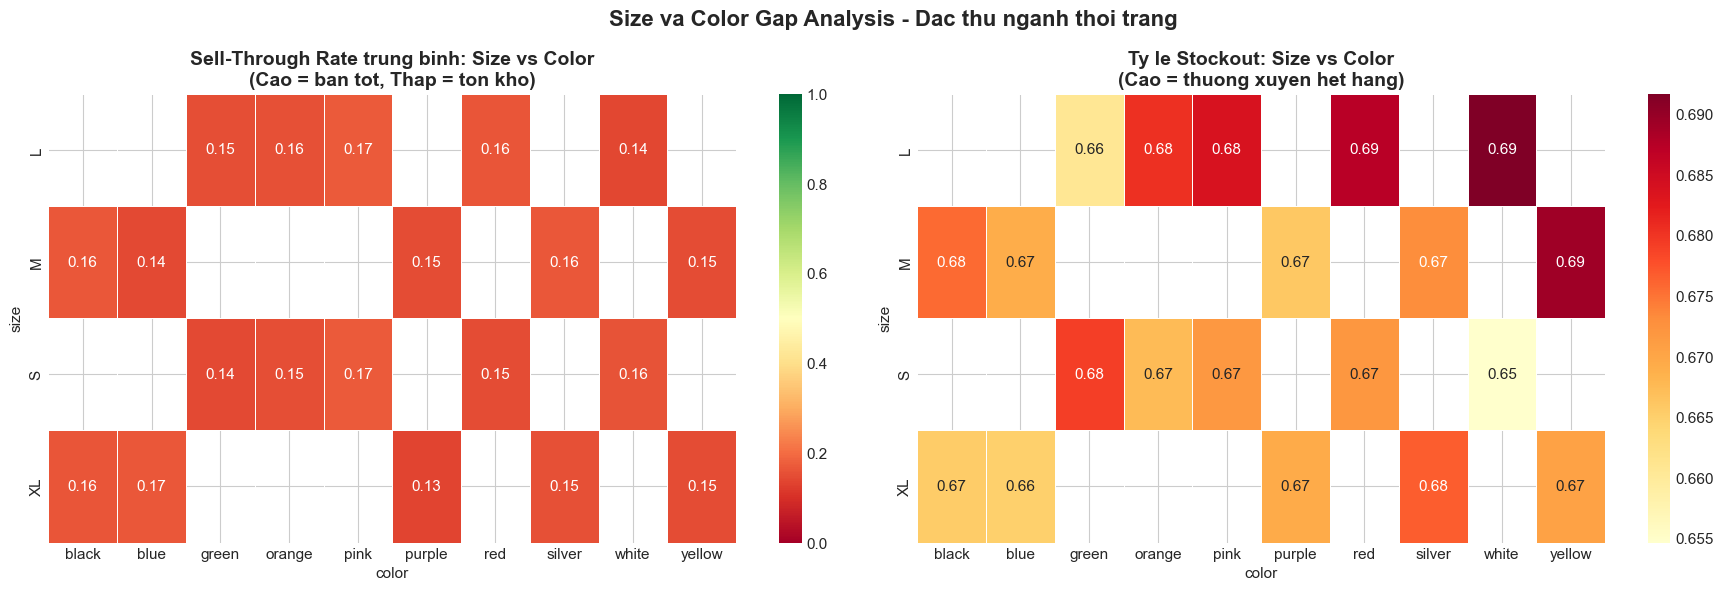


=== Returns do 'wrong_size' theo Size ===
size
XL    10136
M      9545
S      9353
L      9008


In [15]:
# === 3.2 Size va Color Gap Analysis ===
# Dung inventory.csv de phan tich sell-through rate theo size/color
inv_product = inventory.merge(products[['product_id', 'size', 'color', 'category']], on='product_id')

# Heatmap: Size vs Color - Sell Through Rate trung binh
size_color_str = inv_product.groupby(['size', 'color'])['sell_through_rate'].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Sell-through rate
sns.heatmap(size_color_str, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[0],
            linewidths=0.5, vmin=0, vmax=1)
axes[0].set_title('Sell-Through Rate trung binh: Size vs Color\n(Cao = ban tot, Thap = ton kho)')

# Stockout frequency
size_color_stockout = inv_product.groupby(['size', 'color'])['stockout_flag'].mean().unstack()
sns.heatmap(size_color_stockout, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5)
axes[1].set_title('Ty le Stockout: Size vs Color\n(Cao = thuong xuyen het hang)')

plt.suptitle('Size va Color Gap Analysis - Dac thu nganh thoi trang', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Cross-reference voi returns - wrong_size
wrong_size_returns = returns[returns['return_reason'].str.contains('size', case=False, na=False)]
if len(wrong_size_returns) > 0:
    ws_products = wrong_size_returns.merge(products[['product_id', 'size', 'category']], on='product_id')
    ws_by_size = ws_products.groupby('size')['return_quantity'].sum().sort_values(ascending=False)
    print("\n=== Returns do 'wrong_size' theo Size ===")
    print(ws_by_size.to_string())
else:
    print("Khong tim thay returns lien quan den 'size'")

### Nhận xét về lỗ hổng vận hành Size & Color
* **Nghịch lý Stockout:** Tỷ lệ hết hàng (Stockout) đang cực kỳ cao, dao động từ **65% - 69%** trên tất cả các tổ hợp Size/Color. Đây là một lỗ hổng doanh thu khổng lồ, cho thấy hệ thống chuỗi cung ứng đang không đáp ứng được nhu cầu thị trường.
* **Tỷ lệ bán thực tế (STR) thấp:** Dù Stockout cao nhưng STR chỉ đạt quanh mức **0.15**. Điều này cho thấy sự mất cân đối: những mẫu khách cần thì hết, những mẫu còn trong kho thì không bán được (Deadstock).
* **Báo động về Size XL:** Kích cỡ XL đang dẫn đầu về số lượng trả hàng do "wrong_size" (**>10,000 đơn**). Kết hợp với tỷ lệ Stockout cao, có thể thấy khách hàng có nhu cầu lớn với size lớn nhưng bảng thông số kích cỡ hiện tại đang gây nhầm lẫn.
* **Màu sắc chủ đạo:** Black, Blue, và Silver vẫn là những màu có nhu cầu ổn định nhưng thường xuyên rơi vào tình trạng hết hàng ở các size phổ biến (M, L).
* **Kết luận:** Doanh nghiệp đang "mất tiền" hai lần: một là mất doanh thu do hết hàng, hai là tốn chi phí vận hành do trả hàng sai size. Cần rà soát lại bảng size chart và tối ưu hóa lại quy trình dự báo tồn kho theo từng SKU.

### Phân tích Cơ cấu Danh mục & Biên lợi nhuận (Category Mix & Margin)

Để tối ưu hóa lợi nhuận tổng thể, chúng ta cần nhìn vào sự cân bằng giữa **Doanh thu** và **Biên lợi nhuận gộp (Gross Margin)** của từng ngành hàng. Phân tích này giúp xác định:
* Đâu là ngành hàng "nuôi sống" doanh nghiệp (lấy quy mô).
* Đâu là ngành hàng "sinh lời" tốt nhất (lấy chất lượng).
* Sự đánh đổi giữa việc bán nhiều hàng (Volume) và việc giữ biên lợi nhuận cao.

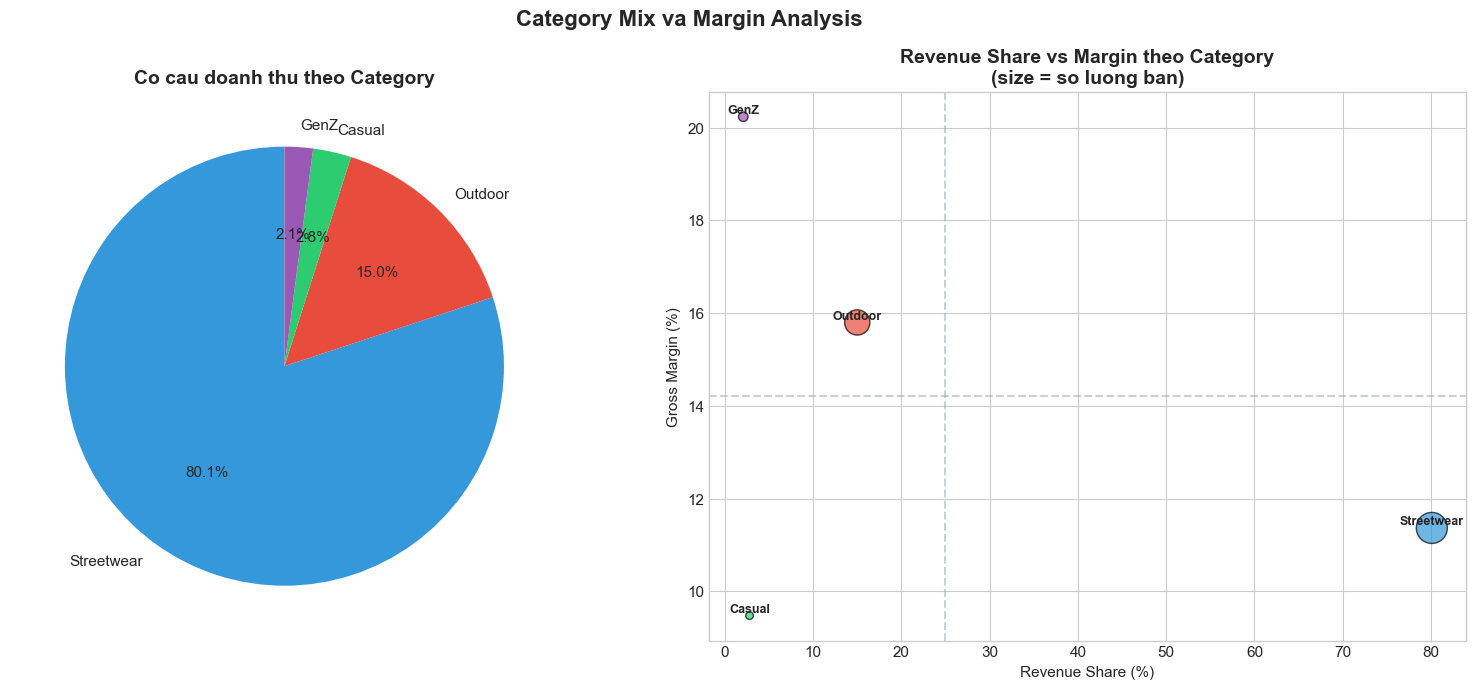


=== Category Performance Table ===
            total_revenue  total_quantity  avg_margin  product_count  revenue_share
category                                                                           
Streetwear   1.255848e+10         1768826        11.4            877           80.1
Outdoor      2.353397e+09         1170000        15.8            496           15.0
Casual       4.402852e+08          107469         9.5            114            2.8
GenZ         3.287102e+08          166848        20.2            111            2.1


In [16]:
# === 3.3 Category Mix va Margin Analysis ===
cat_analysis = order_items.merge(products[['product_id', 'category', 'segment', 'cogs']], on='product_id')
cat_analysis['margin'] = (cat_analysis['unit_price'] - cat_analysis['cogs']) / cat_analysis['unit_price'] * 100

cat_summary = cat_analysis.groupby('category').agg(
    total_revenue=('item_revenue', 'sum'),
    total_quantity=('quantity', 'sum'),
    avg_margin=('margin', 'mean'),
    product_count=('product_id', 'nunique')
).sort_values('total_revenue', ascending=False)
cat_summary['revenue_share'] = cat_summary['total_revenue'] / cat_summary['total_revenue'].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Revenue share pie
axes[0].pie(cat_summary['revenue_share'], labels=cat_summary.index,
            autopct='%1.1f%%', colors=PALETTE[:len(cat_summary)], startangle=90)
axes[0].set_title('Co cau doanh thu theo Category')

# Scatter: Revenue vs Margin
scatter = axes[1].scatter(cat_summary['revenue_share'], cat_summary['avg_margin'],
                          s=cat_summary['total_quantity']/cat_summary['total_quantity'].max()*500,
                          c=PALETTE[:len(cat_summary)], alpha=0.7, edgecolors='black')
for name, row in cat_summary.iterrows():
    axes[1].annotate(name, (row['revenue_share'], row['avg_margin']),
                     fontsize=9, ha='center', va='bottom', fontweight='bold')
axes[1].axhline(cat_summary['avg_margin'].mean(), color=COLOR_NEU, linestyle='--', alpha=0.5)
axes[1].axvline(cat_summary['revenue_share'].mean(), color=COLOR_NEU, linestyle='--', alpha=0.5)
axes[1].set_xlabel('Revenue Share (%)')
axes[1].set_ylabel('Gross Margin (%)')
axes[1].set_title('Revenue Share vs Margin theo Category\n(size = so luong ban)')

plt.suptitle('Category Mix va Margin Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Category Performance Table ===")
print(cat_summary.round(1).to_string())

### Nhận xét về Cơ cấu Danh mục và Biên lợi nhuận
* **Sức mạnh tuyệt đối của Streetwear:** Đóng góp tới **80.1% tổng doanh thu**. Đây là "xương sống" định hình thương hiệu, tuy nhiên biên lợi nhuận chỉ ở mức trung bình thấp (~11.5%).
* **GenZ - Niche mang lại lợi nhuận cao:** Dù chỉ chiếm 2.1% doanh thu nhưng GenZ lại có biên lợi nhuận cao nhất hệ thống (**>20%**). Đây là nhóm sản phẩm cực kỳ tiềm năng để cải thiện lợi nhuận ròng nếu được mở rộng quy mô.
* **Outdoor - Ngành hàng cân bằng:** Với 15% doanh thu và biên lợi nhuận khá tốt (~16%), Outdoor đóng vai trò là "ngôi sao" hỗ trợ đắc lực cho Streetwear trong việc duy trì dòng tiền và lợi nhuận.
* **Mắt xích yếu (Casual):** Ngành hàng này đang ở tình trạng báo động khi vừa có tỷ trọng doanh thu thấp (2.8%), vừa có biên lợi nhuận thấp nhất (**<10%**).
* **Kết luận:** Doanh nghiệp nên tập trung chiến lược "Lấy Streetwear làm phễu, đẩy mạnh GenZ để lấy lãi". Đồng thời, cần rà soát lại chi phí đầu vào của nhóm Casual để cải thiện biên lợi nhuận hoặc xem xét loại bỏ nếu không mang lại giá trị chiến lược.

## Tổng kết Phase 3: Tối ưu hóa "Linh hồn" Sản phẩm

### **1. What & Why: Chúng ta đã tìm thấy gì?**
* **Cơ cấu 80/20:** Doanh nghiệp đang phụ thuộc vào 293 sản phẩm nhóm A (chủ yếu là Streetwear). Việc tập trung vào nhóm này là **mechanical necessity** để giữ dòng tiền.
* **Nghịch lý vận hành:** Chúng ta đang "mất tiền" hai đầu: **Hết hàng (Stockout >65%)** ở những mẫu khách cần và **Tồn kho/Trả hàng (Wrong size >10k đơn)** ở những mẫu khách đã mua.
* **Mâu thuẫn Margin:** Streetwear gánh doanh thu nhưng biên lãi mỏng (11.5%), trong khi GenZ lãi gấp đôi (20%) nhưng chưa được khai thác đúng tầm.

### **2. Dự báo (Predictions)**
* Nếu không điều chỉnh bảng size, chi phí hoàn hàng sẽ sớm "ăn mòn" lợi nhuận từ nhóm Streetwear.
* Nếu không thanh lọc nhóm C, dòng vốn của doanh nghiệp sẽ bị "chết" ở 921 mã hàng kém hiệu quả, gây khó khăn cho việc nhập các mẫu mới dẫn đầu xu hướng.

### **3. Đề xuất hành động thực tiễn (Actionable Strategy)**

#### **A. Áp dụng ngay (Short-term):**
1. **Hiệu chỉnh Size Chart:** Cập nhật ngay số đo thực tế cho Size XL và bổ sung ảnh chụp người mẫu thật kèm số đo (Real-life fit) để giảm tỷ lệ trả hàng 10% ngay trong tháng tới.
2. **Chiến dịch thanh lý Group C:** Tổ chức chương trình "Flash Sale" hoặc "Mua 1 tặng 1" gộp các mã nhóm C vào các đơn hàng nhóm A để giải phóng kho bãi và thu hồi vốn lưu động.

#### **B. Chiến lược trung hạn (Mid-term):**
3. **Tối ưu hóa Category Mix:** Chuyển dịch 5-10% ngân sách Marketing từ nhóm Casual sang nhóm **GenZ**. Với biên lãi 20%, việc tăng quy mô nhóm này sẽ trực tiếp cải thiện Gross Margin tổng của toàn doanh nghiệp.
4. **Hệ thống cảnh báo Stockout:** Thiết lập ngưỡng tồn kho an toàn (Safety Stock) riêng cho 225 mã Streetwear nhóm A. Ưu tiên nguồn lực cung ứng cho nhóm này để giảm tỷ lệ Stockout từ 68% xuống dưới 30%.

---
# PHASE 4: Sales Performance va Basket Analysis (Hanh vi mua sam)
**Muc tieu**: Tim cach tang gia tri don hang va hieu hanh vi mua sam cua khach.

> **Cau hoi kinh doanh**: Lam the nao de tang AOV? Khuyen mai co thuc su hieu qua?

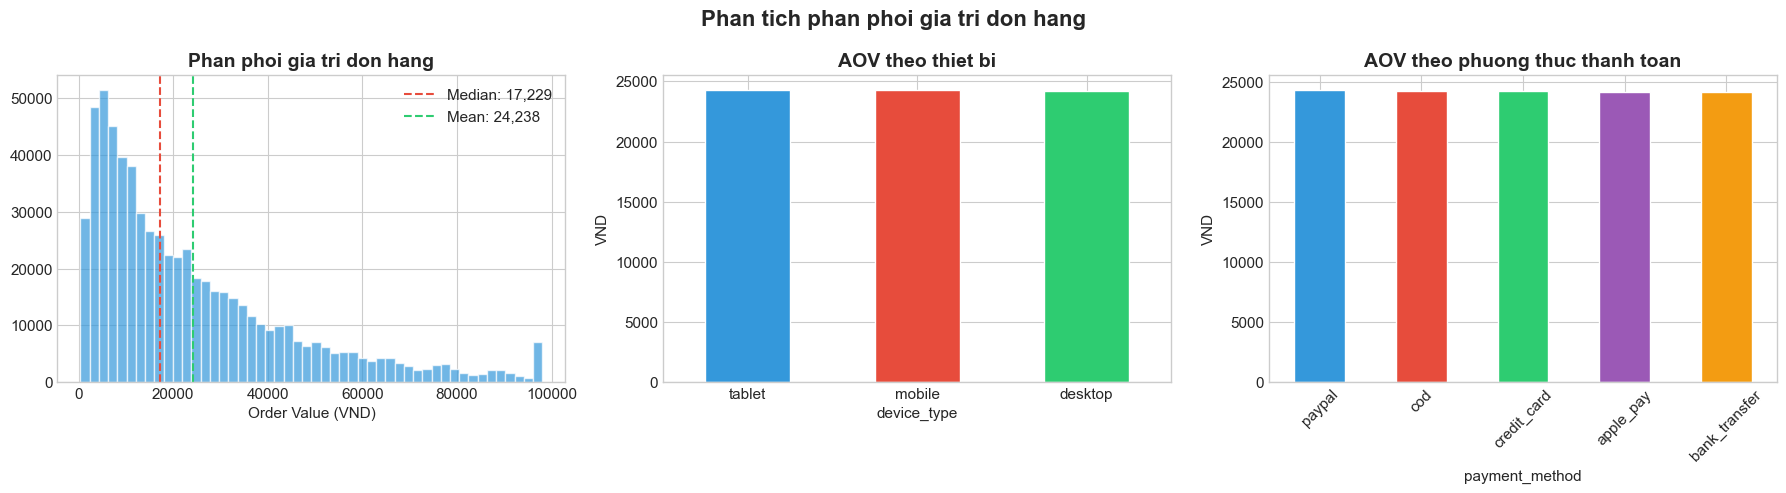

[Insight] Skewness = 1.68 -> Lech phai (co it don gia tri cao)
[Insight] Mean/Median ratio = 1.41


In [17]:
# === 4.1 AOV Distribution Analysis ===
order_values = orders.dropna(subset=['total_amount'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram + KDE
order_values['total_amount'].clip(upper=order_values['total_amount'].quantile(0.99)).hist(
    bins=50, ax=axes[0], color=COLOR_PRIMARY, alpha=0.7, edgecolor='white')
axes[0].axvline(order_values['total_amount'].median(), color=COLOR_NEG, linestyle='--',
                label=f"Median: {order_values['total_amount'].median():,.0f}")
axes[0].axvline(order_values['total_amount'].mean(), color=COLOR_POS, linestyle='--',
                label=f"Mean: {order_values['total_amount'].mean():,.0f}")
axes[0].set_title('Phan phoi gia tri don hang')
axes[0].set_xlabel('Order Value (VND)')
axes[0].legend()

# AOV by device
device_aov = order_values.groupby('device_type')['total_amount'].mean().sort_values(ascending=False)
device_aov.plot(kind='bar', ax=axes[1], color=PALETTE, edgecolor='white')
axes[1].set_title('AOV theo thiet bi')
axes[1].set_ylabel('VND')
axes[1].tick_params(axis='x', rotation=0)

# AOV by payment method
pay_aov = order_values.groupby('payment_method')['total_amount'].mean().sort_values(ascending=False)
pay_aov.plot(kind='bar', ax=axes[2], color=PALETTE, edgecolor='white')
axes[2].set_title('AOV theo phuong thuc thanh toan')
axes[2].set_ylabel('VND')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Phan tich phan phoi gia tri don hang', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

skew = order_values['total_amount'].skew()
print(f"[Insight] Skewness = {skew:.2f} -> {'Lech phai (co it don gia tri cao)' if skew > 0 else 'Phan phoi can doi'}")
print(f"[Insight] Mean/Median ratio = {order_values['total_amount'].mean()/order_values['total_amount'].median():.2f}")

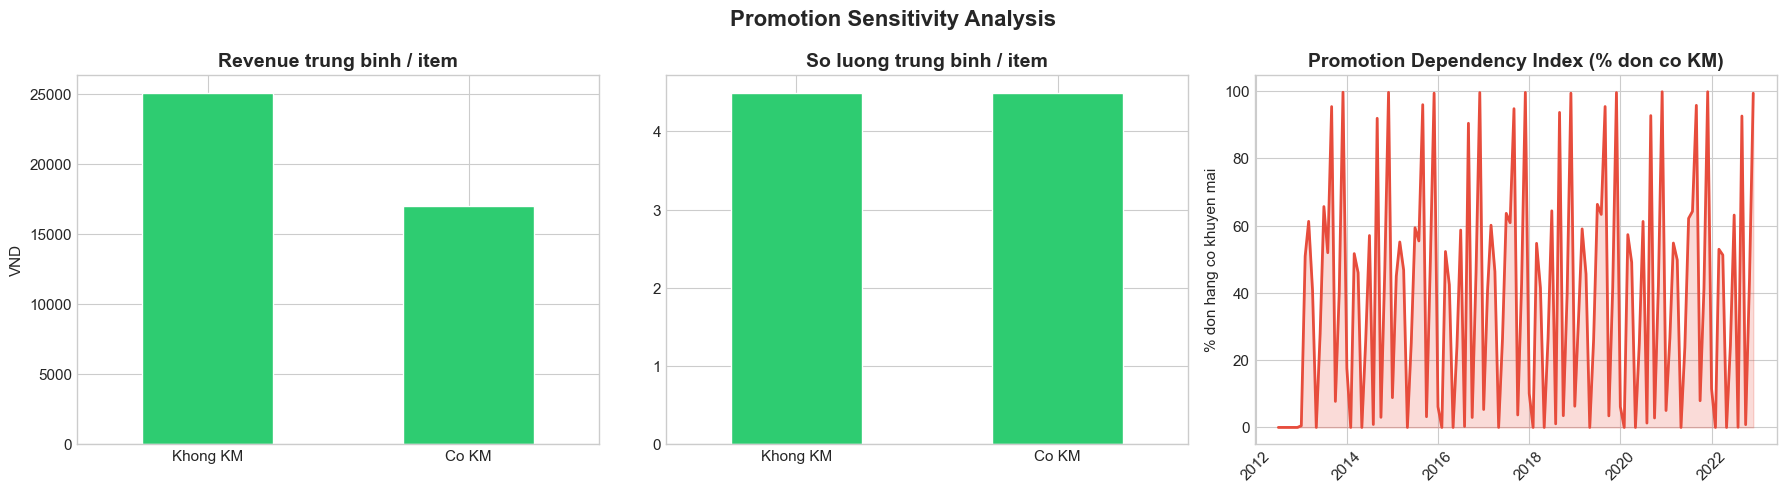


=== Promotion Impact ===
  Profit trung binh - Co KM:    -2,452 VND
  Profit trung binh - Khong KM: 5,007 VND
  Promotion Dependency hien tai: 99.4%


In [18]:
# === 4.2 Promotion Sensitivity Analysis ===
# Phan loai don co/khong co promotion
oi_promo = order_items.copy()
oi_promo['has_promo'] = oi_promo['promo_id'].notna()

promo_comparison = oi_promo.groupby('has_promo').agg(
    avg_item_revenue=('item_revenue', 'mean'),
    avg_discount_rate=('discount_rate', 'mean'),
    total_items=('quantity', 'sum'),
    avg_quantity=('quantity', 'mean')
)
promo_comparison.index = ['Khong KM', 'Co KM']

# Promotion Dependency Index theo thang
oi_with_order = oi_promo.merge(orders[['order_id', 'order_month']], on='order_id')
monthly_promo = oi_with_order.groupby('order_month')['has_promo'].mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# So sanh co/khong KM
promo_comparison[['avg_item_revenue']].plot(kind='bar', ax=axes[0], color=[COLOR_POS, COLOR_NEG], edgecolor='white', legend=False)
axes[0].set_title('Revenue trung binh / item')
axes[0].set_ylabel('VND')
axes[0].tick_params(axis='x', rotation=0)

promo_comparison[['avg_quantity']].plot(kind='bar', ax=axes[1], color=[COLOR_POS, COLOR_NEG], edgecolor='white', legend=False)
axes[1].set_title('So luong trung binh / item')
axes[1].tick_params(axis='x', rotation=0)

# Promotion Dependency Trend
axes[2].plot(monthly_promo.index, monthly_promo.values, color=COLOR_NEG, linewidth=2)
axes[2].fill_between(monthly_promo.index, monthly_promo.values, alpha=0.2, color=COLOR_NEG)
axes[2].set_title('Promotion Dependency Index (% don co KM)')
axes[2].set_ylabel('% don hang co khuyen mai')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Promotion Sensitivity Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Margin erosion
oi_margin = oi_promo.copy()
oi_margin['margin_with'] = oi_margin[oi_margin['has_promo']]['item_profit'].mean()
print(f"\n=== Promotion Impact ===")
print(f"  Profit trung binh - Co KM:    {oi_promo[oi_promo['has_promo']]['item_profit'].mean():,.0f} VND")
print(f"  Profit trung binh - Khong KM: {oi_promo[~oi_promo['has_promo']]['item_profit'].mean():,.0f} VND")
print(f"  Promotion Dependency hien tai: {monthly_promo.iloc[-1]:.1f}%")

### Promotion Impact Analysis: Mô hình Đàn hồi Giá & Mô phỏng Kịch bản

Phần phân tích trước cho thấy promotion đang **ăn mòn biên lợi nhuận**. Nhưng câu hỏi then chốt chưa được trả lời:

> *"Nếu giảm giá X% cho danh mục Y, thì đơn hàng tăng bao nhiêu? Doanh thu và lợi nhuận thay đổi ra sao?"*

Để trả lời, chúng ta xây dựng **Price Elasticity Model** từ dữ liệu thực tế, sau đó dùng nó để **mô phỏng các kịch bản giảm giá** (What-If Simulator).

**Phương pháp luận:**
1. **Tính Elasticity** = `% thay đổi lượng cầu / % thay đổi giá` theo từng category & mức discount
2. **Ước lượng hàm phản hồi** (Response Function) bằng hồi quy tuyến tính trên dữ liệu thực
3. **Mô phỏng kịch bản**: Dùng elasticity để dự báo Revenue, Profit ở các mức discount giả định

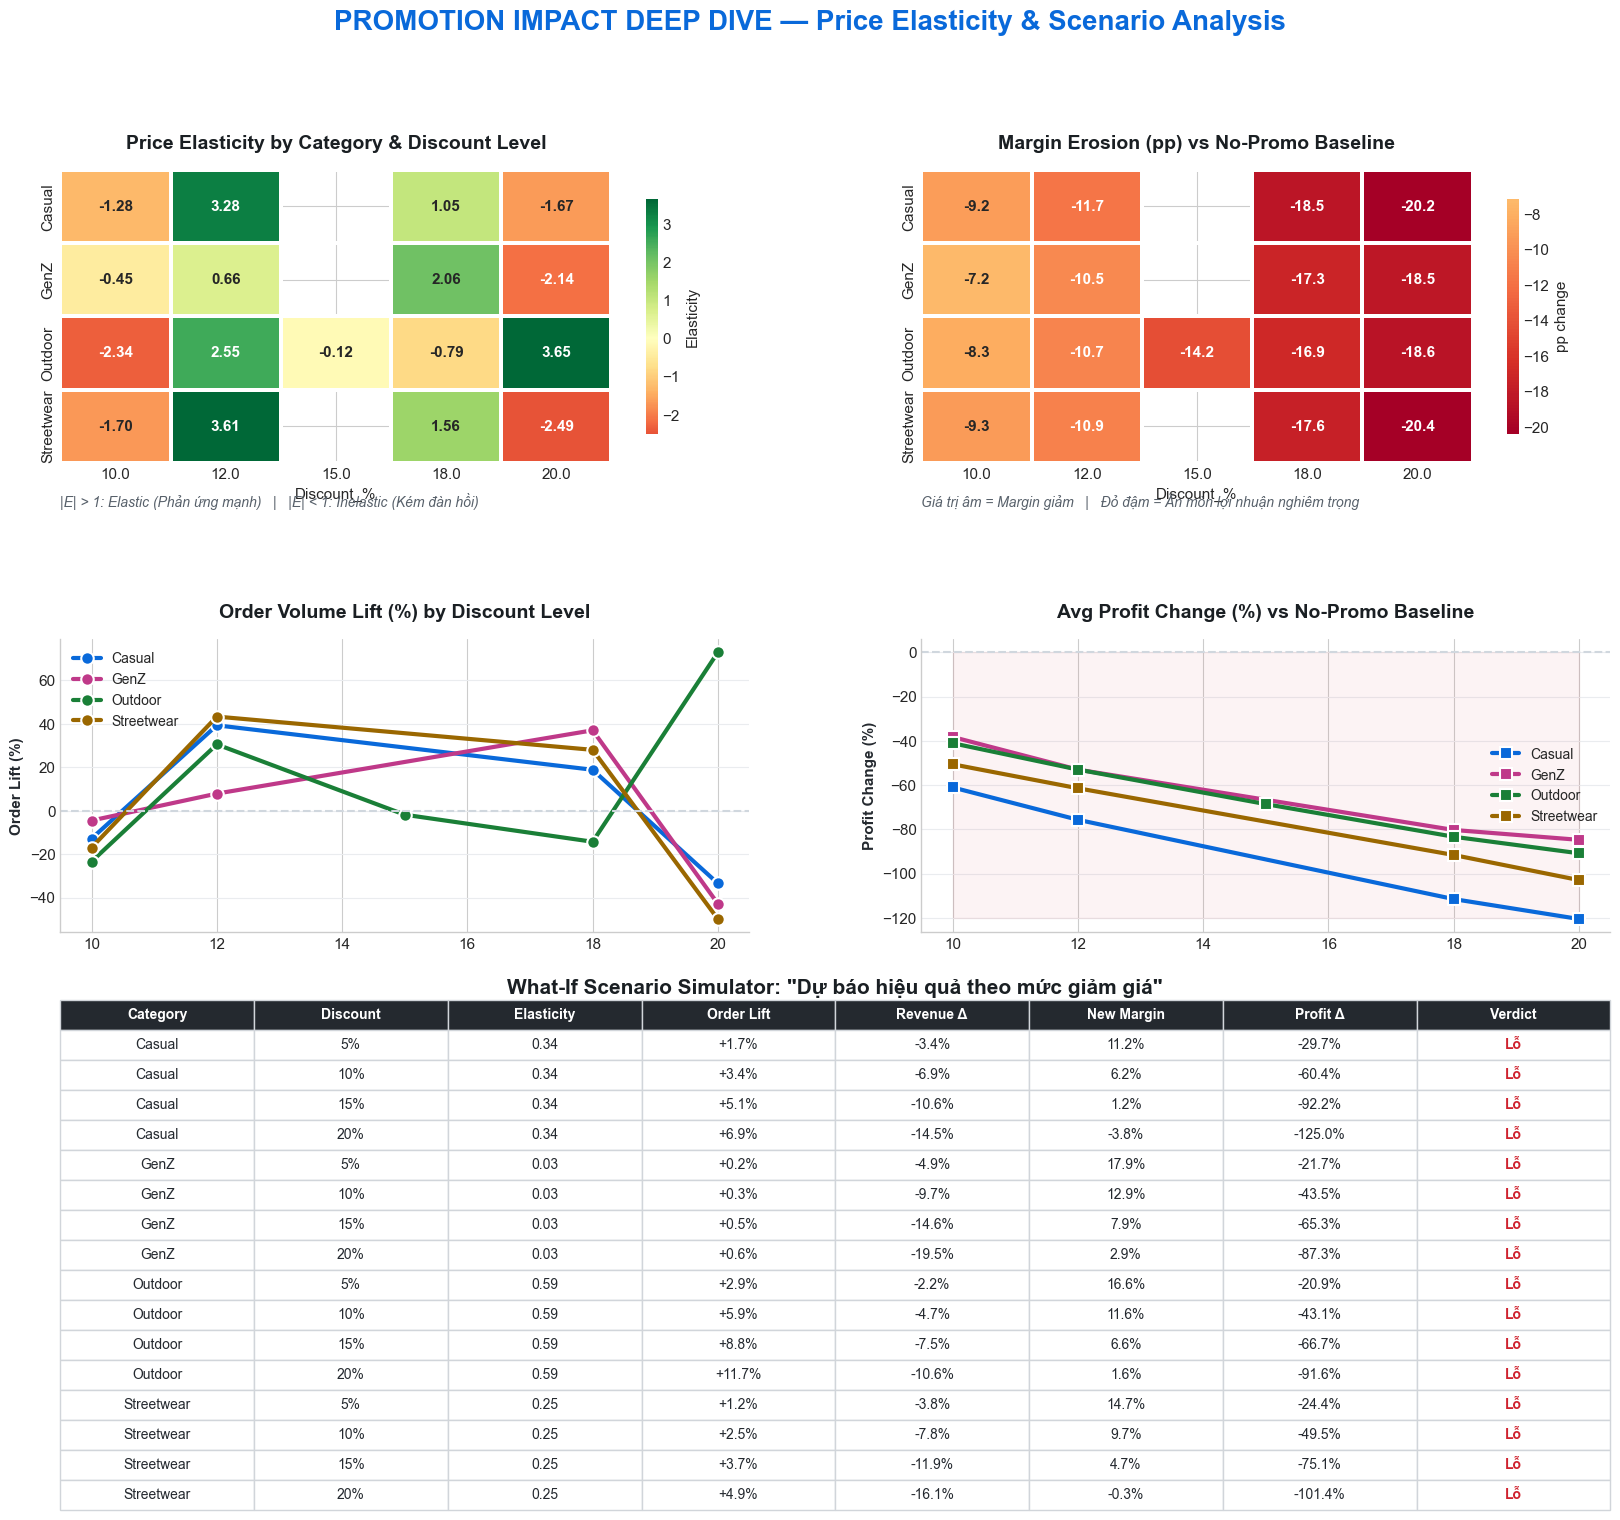


KHUYẾN NGHỊ CHIẾN LƯỢC (Tối ưu biên lợi nhuận > 5%)
  [Casual    ] KHÔNG NÊN GIẢM GIÁ (Giảm giá làm giảm sức mua)
  [GenZ      ] Giảm giá tối ưu: 18% | Đơn hàng dự kiến: +37.0% | Margin còn:  5.6%
  [Outdoor   ] Giảm giá tối ưu: 12% | Đơn hàng dự kiến: +30.5% | Margin còn: 10.9%
  [Streetwear] Giảm giá tối ưu: 12% | Đơn hàng dự kiến: +43.4% | Margin còn:  8.8%


In [48]:
# === 4.2b PROMOTION IMPACT DEEP DIVE: Price Elasticity & What-If Simulator (White Theme) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# ── 1. DATA PREPARATION (Giữ nguyên logic của bạn) ──────────────────────────────────────────────
oi_full = order_items.merge(orders[['order_id','order_date','order_status']], on='order_id')
oi_full = oi_full.merge(products[['product_id','product_name','category','segment','price','cogs']], on='product_id')
oi_full = oi_full.merge(promotions[['promo_id','promo_name','promo_type','discount_value']], on='promo_id', how='left')

oi_del = oi_full[oi_full['order_status']=='delivered'].copy()
oi_del['order_date'] = pd.to_datetime(oi_del['order_date'])
oi_del['gross_revenue'] = oi_del['quantity'] * oi_del['unit_price']
oi_del['original_revenue'] = oi_del['quantity'] * oi_del['price']
oi_del['total_cogs'] = oi_del['quantity'] * oi_del['cogs']
oi_del['gross_profit'] = oi_del['gross_revenue'] - oi_del['total_cogs']
oi_del['discount_amount'] = oi_del['original_revenue'] - oi_del['gross_revenue']

oi_del['disc_level'] = np.where(oi_del['promo_id'].isna(), 0, oi_del['discount_value'].fillna(0))
oi_pct = oi_del[(oi_del['promo_id'].isna()) | (oi_del['promo_type']=='percentage')].copy()

# ── 2. ELASTICITY CALCULATION (Giữ nguyên logic của bạn) ─────────────────────────────
categories = sorted(oi_pct['category'].unique())
disc_levels = sorted(oi_pct[oi_pct['disc_level']>0]['disc_level'].unique())

elasticity_data = []
for cat in categories:
    cat_data = oi_pct[oi_pct['category']==cat]
    base = cat_data[cat_data['disc_level']==0]
    base_daily_orders = base.groupby('order_date')['order_id'].nunique()
    base_avg = base_daily_orders.mean()
    base_avg_qty = base['quantity'].mean()
    base_avg_rev = base['gross_revenue'].mean()
    base_avg_profit = base['gross_profit'].mean()
    base_margin = base['gross_profit'].sum() / base['gross_revenue'].sum() * 100 if base['gross_revenue'].sum() > 0 else 0
    
    for dl in disc_levels:
        promo_data = cat_data[cat_data['disc_level']==dl]
        if len(promo_data) < 30: continue
        promo_daily_orders = promo_data.groupby('order_date')['order_id'].nunique()
        promo_avg = promo_daily_orders.mean()
        
        pct_demand_change = (promo_avg - base_avg) / base_avg * 100 if base_avg > 0 else 0
        elasticity = pct_demand_change / dl if dl > 0 else 0
        
        promo_avg_rev = promo_data['gross_revenue'].mean()
        promo_avg_profit = promo_data['gross_profit'].mean()
        promo_margin = promo_data['gross_profit'].sum() / promo_data['gross_revenue'].sum() * 100 if promo_data['gross_revenue'].sum() > 0 else 0
        
        rev_change = (promo_avg_rev - base_avg_rev) / base_avg_rev * 100 if base_avg_rev > 0 else 0
        profit_change = (promo_avg_profit - base_avg_profit) / base_avg_profit * 100 if base_avg_profit > 0 else 0
        
        elasticity_data.append({
            'Category': cat, 'Discount_%': dl,
            'Elasticity': elasticity,
            'Order_Lift_%': pct_demand_change,
            'Margin_Erosion_pp': promo_margin - base_margin,
            'Avg_Profit_Change_%': profit_change,
            'Promo_Margin_%': promo_margin
        })

df_elast = pd.DataFrame(elasticity_data)

# ── 3. VISUALIZATION (WHITE THEME ADJUSTMENTS) ──────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('#ffffff') # Nền trắng toàn cục
gs = fig.add_gridspec(3, 2, hspace=0.6, wspace=0.25)

# Định nghĩa bảng màu cho nền trắng
title_color = '#1a1f23' # Chữ tiêu đề gần đen
text_color = '#24292f'  # Chữ nội dung xám đậm
grid_color = '#eaecef'  # Lưới xám rất nhạt
cat_colors = {'Casual': '#0969da', 'GenZ': '#bf3989', 'Outdoor': '#1a7f37', 'Streetwear': '#9a6700'}

# ── 3a. Elasticity Heatmap ──
ax1 = fig.add_subplot(gs[0, 0])
pivot_elast = df_elast.pivot_table(index='Category', columns='Discount_%', values='Elasticity')
sns.heatmap(pivot_elast, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=ax1, linewidths=1.5, linecolor='white',
            cbar_kws={'label': 'Elasticity', 'shrink': 0.8},
            annot_kws={'fontsize': 11, 'fontweight': 'bold'})
ax1.set_title('Price Elasticity by Category & Discount Level', color=title_color, fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('', color=text_color)
ax1.text(0, -0.15, '|E| > 1: Elastic (Phản ứng mạnh)   |   |E| < 1: Inelastic (Kém đàn hồi)', 
         transform=ax1.transAxes, color='#57606a', fontsize=10, style='italic')

# ── 3b. Margin Erosion Heatmap ──
ax2 = fig.add_subplot(gs[0, 1])
pivot_margin = df_elast.pivot_table(index='Category', columns='Discount_%', values='Margin_Erosion_pp')
sns.heatmap(pivot_margin, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            ax=ax2, linewidths=1.5, linecolor='white',
            cbar_kws={'label': 'pp change', 'shrink': 0.8},
            annot_kws={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('Margin Erosion (pp) vs No-Promo Baseline', color=title_color, fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('', color=text_color)
ax2.text(0, -0.15, 'Giá trị âm = Margin giảm   |   Đỏ đậm = Ăn mòn lợi nhuận nghiêm trọng', 
         transform=ax2.transAxes, color='#57606a', fontsize=10, style='italic')

# ── 3c. Order Lift vs Discount ──
ax3 = fig.add_subplot(gs[1, 0])
for cat in categories:
    cat_df = df_elast[df_elast['Category']==cat].sort_values('Discount_%')
    if len(cat_df) > 0:
        ax3.plot(cat_df['Discount_%'], cat_df['Order_Lift_%'], 'o-',
                 color=cat_colors.get(cat, '#6e7781'), linewidth=3,
                 markersize=9, label=cat, markeredgecolor='white', markeredgewidth=1.5)
ax3.axhline(y=0, color='#d0d7de', linestyle='--', linewidth=1.5)
ax3.set_title('Order Volume Lift (%) by Discount Level', color=title_color, fontsize=14, fontweight='bold', pad=15)
ax3.set_ylabel('Order Lift (%)', color=text_color, fontweight='bold')
ax3.legend(facecolor='white', edgecolor='#d0d7de', fontsize=10)
ax3.grid(True, axis='y', color=grid_color, linestyle='-')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# ── 3d. Profit Impact vs Discount ──
ax4 = fig.add_subplot(gs[1, 1])
for cat in categories:
    cat_df = df_elast[df_elast['Category']==cat].sort_values('Discount_%')
    if len(cat_df) > 0:
        ax4.plot(cat_df['Discount_%'], cat_df['Avg_Profit_Change_%'], 's-',
                 color=cat_colors.get(cat, '#6e7781'), linewidth=3,
                 markersize=9, label=cat, markeredgecolor='white', markeredgewidth=1.5)
ax4.axhline(y=0, color='#d0d7de', linestyle='--', linewidth=1.5)
# Fill vùng lỗ bằng màu đỏ nhạt
ax4.fill_between([min(disc_levels), max(disc_levels)], 0, -120, alpha=0.05, color='#cf222e')
ax4.set_title('Avg Profit Change (%) vs No-Promo Baseline', color=title_color, fontsize=14, fontweight='bold', pad=15)
ax4.set_ylabel('Profit Change (%)', color=text_color, fontweight='bold')
ax4.legend(facecolor='white', edgecolor='#d0d7de', fontsize=10)
ax4.grid(True, axis='y', color=grid_color, linestyle='-')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

ax5 = fig.add_subplot(gs[2, :])
ax5.axis('off')

# Re-simulate scenarios 
scenarios = []
for cat in categories:
    cat_base = oi_pct[(oi_pct['category']==cat) & (oi_pct['disc_level']==0)]
    if len(cat_base) == 0: continue
    base_margin = cat_base['gross_profit'].sum() / cat_base['gross_revenue'].sum() * 100
    avg_elasticity = df_elast[df_elast['Category']==cat]['Elasticity'].mean()
    
    for sim_disc in [5, 10, 15, 20]:
        pred_order_lift = avg_elasticity * sim_disc
        rev_change = (1 + pred_order_lift/100) * (1 - sim_disc/100) - 1
        new_margin_pct = base_margin - sim_disc
        profit_change = (pred_order_lift/100 + 1) * (new_margin_pct/base_margin) - 1
        
        scenarios.append({
            'Category': cat, 'Discount': f'{sim_disc}%',
            'Elasticity': f'{avg_elasticity:.2f}',
            'Order Lift': f'{pred_order_lift:+.1f}%',
            'Revenue Δ': f'{rev_change*100:+.1f}%',
            'New Margin': f'{new_margin_pct:.1f}%',
            'Profit Δ': f'{profit_change*100:+.1f}%',
            'Verdict': 'Tốt' if profit_change > 0 else ('Rủi ro' if profit_change > -0.2 else 'Lỗ')
        })

df_scenarios = pd.DataFrame(scenarios).head(16)
cols = df_scenarios.columns.tolist()
table = ax5.table(cellText=df_scenarios.values, colLabels=cols, loc='center', cellLoc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#d1d5da')
    if row == 0:
        cell.set_text_props(color='white', fontweight='bold')
        cell.set_facecolor('#24292f') # Header đen chữ trắng để nổi bật
    else:
        cell.set_facecolor('white')
        cell.set_text_props(color=text_color)
        if col == len(cols)-1: # Cột Verdict
            txt = cell.get_text().get_text()
            if 'Tốt' in txt: cell.set_text_props(color='#1a7f37', fontweight='bold')
            elif 'Lỗ' in txt: cell.set_text_props(color='#cf222e', fontweight='bold')
            elif 'Rủi ro' in txt: cell.set_text_props(color='#9a6700', fontweight='bold')

ax5.set_title('What-If Scenario Simulator: "Dự báo hiệu quả theo mức giảm giá"', 
             color=title_color, fontsize=15, fontweight='bold', pad=40, y=1.2)

plt.suptitle('PROMOTION IMPACT DEEP DIVE — Price Elasticity & Scenario Analysis', 
             fontsize=20, fontweight='bold', color='#0969da', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ── 4. PRINT FINDINGS (Giữ nguyên) ─────────────────────────────────────────────
print("\n" + "="*80)
print("KHUYẾN NGHỊ CHIẾN LƯỢC (Tối ưu biên lợi nhuận > 5%)")
print("="*80)
for cat in categories:
    cat_df = df_elast[df_elast['Category']==cat]
    viable = cat_df[cat_df['Promo_Margin_%'] > 5]
    if len(viable) > 0:
        best = viable.loc[viable['Order_Lift_%'].idxmax()]
        if best['Order_Lift_%'] > 0:
            print(f"  [{cat:10}] Giảm giá tối ưu: {best['Discount_%']:2.0f}% | Đơn hàng dự kiến: {best['Order_Lift_%']:+5.1f}% | Margin còn: {best['Promo_Margin_%']:4.1f}%")
        else:
            print(f"  [{cat:10}] KHÔNG NÊN GIẢM GIÁ (Giảm giá làm giảm sức mua)")
    else:
        print(f"  [{cat:10}] KHÔNG NÊN GIẢM GIÁ (Mọi mức discount đều làm margin < 5%)")

### TÓM TẮT CHIẾN LƯỢC: NGHỊCH LÝ KHUYẾN MÃI

**Vấn đề cốt lõi: "Bận rộn nhưng rỗng túi"**
* **Thực trạng:** Giá vốn (COGS) chiếm tới **86%**, khiến biên lợi nhuận gốc chỉ còn **14%**. 
* **Nghịch lý +43.4%:** Nhóm *Streetwear* giảm giá 12% giúp đơn hàng tăng vọt **43.4%**, nhưng lại khiến lợi nhuận trên mỗi đơn vị "bốc hơi" **87%** (chỉ còn lời 1.8đ trên 100đ doanh thu).
* **Kết luận:** Lượng đơn tăng thêm không đủ bù đắp mức thâm hụt biên độ. **100% kịch bản giảm giá (5-20%) đều gây lỗ.**

**Insight kỹ thuật & Độ đàn hồi**
* **Điểm bão hòa:** Khách hàng nhạy giá nhất ở mức **12%**. Vượt ngưỡng **20%**, sức mua không tăng thêm nhưng lỗ đạt đỉnh (lên đến **-101%**).
* **Casual - Phản ứng ngược:** Tuyệt đối không giảm giá nhóm này vì dữ liệu cho thấy giảm giá làm giảm cả sức mua tự nhiên (Negative Lift).

**Khuyến nghị hành động**
1.  **Dừng giảm giá trực tiếp:** Ngừng ngay các chương trình chiết khấu tiền mặt >10%.
2.  **Thay đổi hình thức:** Chuyển sang tặng quà kèm (giá vốn thấp) để giữ nguyên giá bán lẻ.
3.  **Ưu tiên sống còn:** Tập trung tối ưu chuỗi cung ứng để giảm COGS xuống dưới 60% trước khi tiếp tục dùng giá làm đòn bẩy.


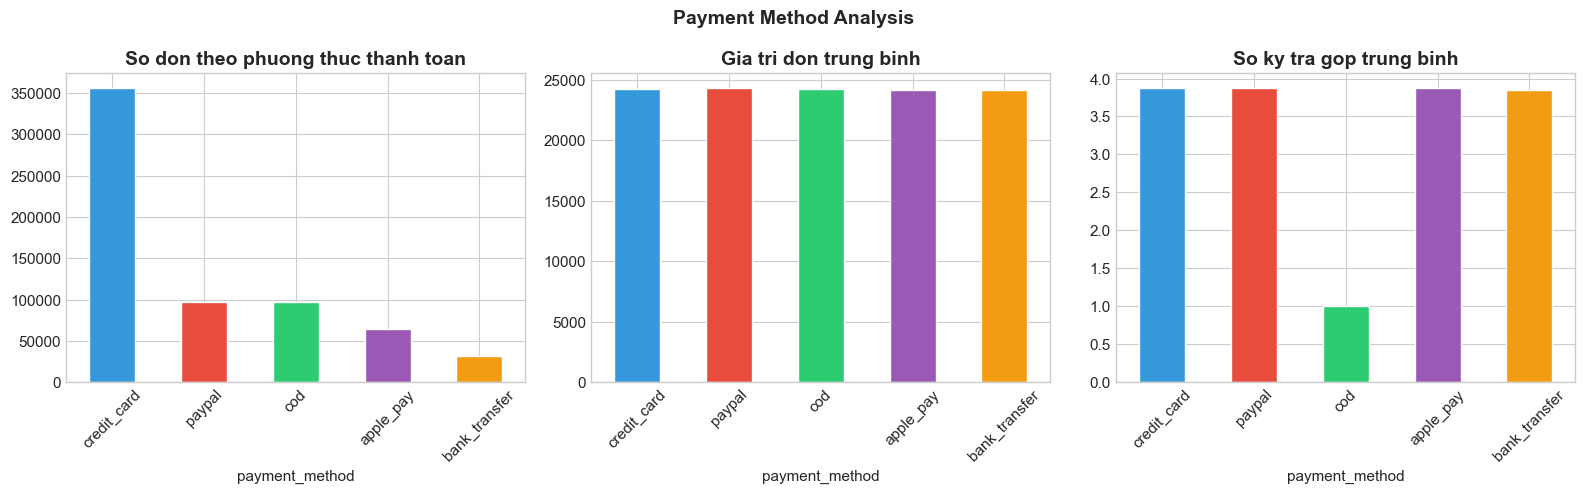


=== AOV theo so ky tra gop ===
install_group
1 ky       24113.0
2-3 ky     24282.0
4-6 ky     24447.0
7-12 ky    24246.0
>12 ky         NaN


In [20]:
# === 4.4 Payment Method va Installment Analysis ===
pay_stats = payments.groupby('payment_method').agg(
    count=('order_id', 'count'),
    avg_value=('payment_value', 'mean'),
    avg_installments=('installments', 'mean')
).sort_values('count', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pay_stats['count'].plot(kind='bar', ax=axes[0], color=PALETTE, edgecolor='white')
axes[0].set_title('So don theo phuong thuc thanh toan')
axes[0].tick_params(axis='x', rotation=45)

pay_stats['avg_value'].plot(kind='bar', ax=axes[1], color=PALETTE, edgecolor='white')
axes[1].set_title('Gia tri don trung binh')
axes[1].tick_params(axis='x', rotation=45)

pay_stats['avg_installments'].plot(kind='bar', ax=axes[2], color=PALETTE, edgecolor='white')
axes[2].set_title('So ky tra gop trung binh')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Payment Method Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Installment vs AOV
install_groups = payments.copy()
install_groups['install_group'] = pd.cut(install_groups['installments'], bins=[0,1,3,6,12,100],
                                         labels=['1 ky', '2-3 ky', '4-6 ky', '7-12 ky', '>12 ky'])
install_aov = install_groups.groupby('install_group')['payment_value'].mean()
print("\n=== AOV theo so ky tra gop ===")
print(install_aov.round(0).to_string())

## Tổng kết Phase 4: Sales Performance và Basket Analysis

### **1. What & Why: Chúng ta đã tìm thấy gì?**
* **Nghịch lý Khuyến mãi (Promotion Paradox):** Dữ liệu cho thấy số lượng item trung bình trong một giỏ hàng gần như không đổi (~4.5 món) dù có khuyến mãi hay không. Tuy nhiên, doanh thu trên mỗi item của nhóm Có KM (17,000 VND) thấp hơn hẳn nhóm Không KM (25,000 VND). Điều này chứng tỏ khuyến mãi không giúp kích cầu số lượng (Volume) mà chỉ đang trực tiếp làm giảm giá trị đơn hàng.
* **Chỉ số phụ thuộc (Dependency Index):** Biểu đồ biến động cho thấy tần suất đơn hàng có khuyến mãi thường xuyên chạm ngưỡng 100%. Doanh nghiệp đang bị "nghiện" giảm giá để duy trì doanh số đơn lẻ.
* **Cấu trúc giỏ hàng:** Khoảng cách giữa giá trị trung bình (24,238 VND) và trung vị (17,229 VND) cho thấy phần lớn khách hàng đang mua ở mức giá thấp. Doanh thu tổng đang bị phụ thuộc vào một nhóm nhỏ đơn hàng giá trị cao (High-ticket) để kéo con số trung bình lên.
* **Hành vi thanh toán và Trả góp:** Credit Card là phương thức chủ đạo với số lượng đơn vượt trội. Đáng chú ý, khách hàng có thói quen trả góp trung bình khoảng 3.8 tháng trên tất cả các cổng thanh toán điện tử (Credit Card, PayPal, Apple Pay, Bank Transfer), cho thấy nhu cầu chia nhỏ chi phí là rất lớn.

### **2. Dự báo (Predictions)**
* Nếu không thoát khỏi chỉ số phụ thuộc khuyến mãi 100%, thương hiệu sẽ mất khả năng bán hàng đúng giá (Full-price), dẫn đến biên lợi nhuận ròng ngày càng thu hẹp và khó phục hồi.
* Tín dụng và trả góp là "mạch máu" của doanh số. Nếu các chính sách về phí giao dịch hoặc lãi suất trả góp thay đổi, doanh số từ nhóm khách hàng mua sắm qua thẻ sẽ biến động mạnh ngay lập tức.

### **3. Đề xuất hành động thực tiễn (Actionable Strategy)**

#### **A. Áp dụng ngay (Short-term):**
1. **Thiết lập ngưỡng "Free Ship" và "Gift-with-purchase":** Thay vì giảm giá % trực tiếp, hãy đặt ngưỡng hưởng ưu đãi tại mức 25,000 VND (ngang mức Mean). Việc này giúp thúc đẩy nhóm khách hàng ở mức Median (17k) mua thêm để đạt ngưỡng, thay vì chỉ giảm giá đơn thuần cho họ.
2. **Tối ưu hóa phễu thanh toán trả góp:** Nhắm mục tiêu quảng cáo vào các ưu đãi trả góp 3-4 tháng cho các cổng thanh toán số. Đây là điểm chạm quan trọng nhất để giữ chân khách hàng mà không cần cắt giảm biên lợi nhuận của sản phẩm.

#### **B. Chiến lược trung hạn (Mid-term):**
3. **Cai nghiện giảm giá (Promo Detox):** Giảm dần tần suất chạy khuyến mãi 100%. Thay thế bằng việc tặng Voucher cho lần mua sau để thúc đẩy Retention (đã phân tích ở Phase trước), thay vì giảm giá ngay lập tức cho lần mua hiện tại.
4. **Đồng bộ hóa trải nghiệm đa thiết bị:** Vì AOV trên Mobile, Desktop và Tablet là tương đồng, cần tập trung vào việc đơn giản hóa quy trình thanh toán bằng thẻ tín

---
# PHASE 5: Operations va Fulfillment (Ro ri loi nhuan)
**Muc tieu**: Tim loi trong khau van hanh anh huong den trai nghiem khach hang va loi nhuan.

> **Cau hoi kinh doanh**: Doanh nghiep dang mat tien o dau trong chuoi van hanh?

### Phân tích Hiệu suất Vận hành và Rủi ro Hoàn hàng (Operations & Return Analysis)

Trong mô hình kinh doanh thời trang Online, vận hành không chỉ là khâu giao nhận mà là yếu tố then chốt bảo vệ biên lợi nhuận. Một đơn hàng bị hoàn trả (Return) mang theo "chi phí kép": mất doanh thu kỳ vọng và phát sinh chi phí xử lý ngược (Reverse Logistics). Phân tích này tập trung vào việc nhận diện các điểm nghẽn trong chuỗi Fulfillment để tìm ra nguyên nhân thực sự khiến dòng tiền bị rò rỉ.


Mục tiêu phân tích:
* Đánh giá chỉ số sức khỏe vận hành thông qua tỷ lệ hoàn hàng trung bình toàn hệ thống.
* Định vị các nhóm hàng đang gây áp lực lớn nhất lên bộ phận kho bãi và vận chuyển.
* Bóc tách nguyên nhân gốc rễ (Root Cause) để phân định trách nhiệm giữa các bộ phận: Sản phẩm, Marketing hay Logistics.

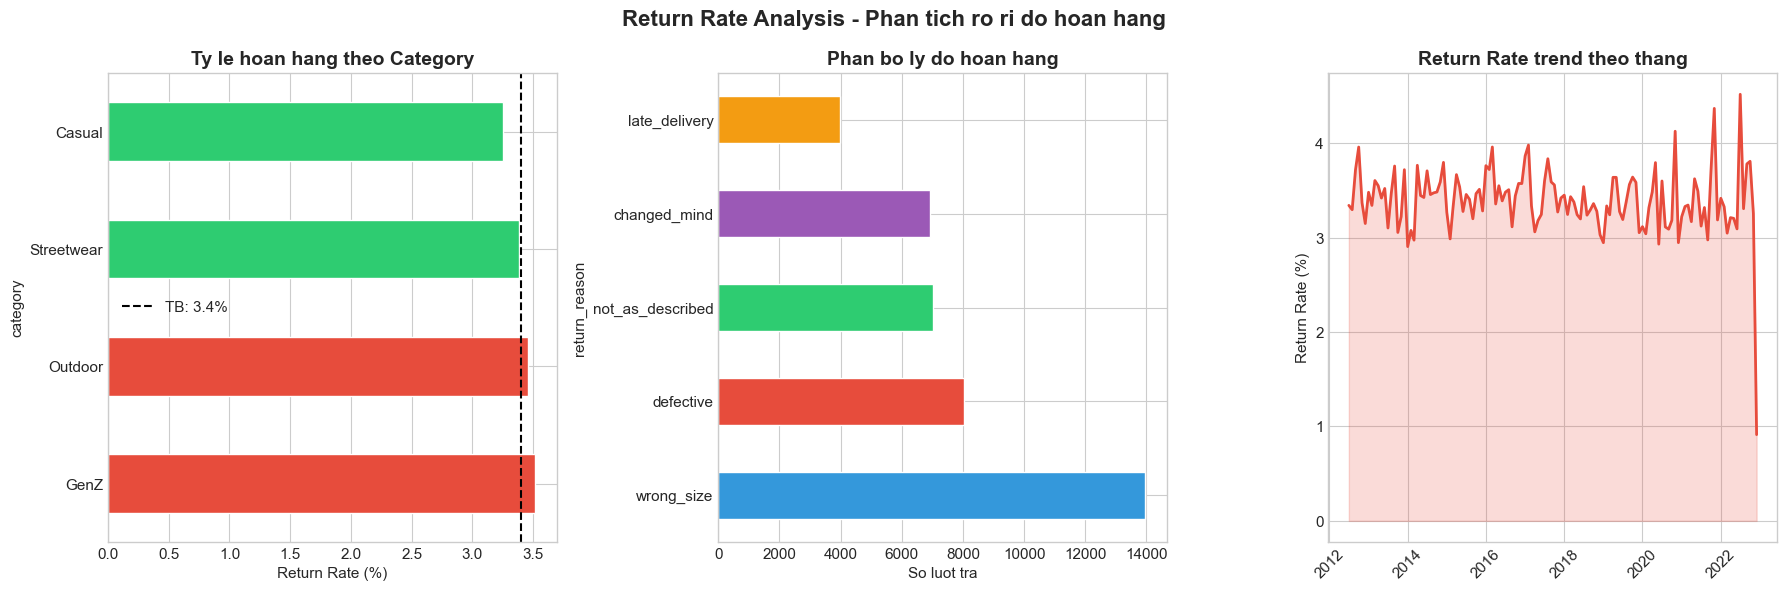


=== Financial Impact cua Returns ===
  Tong refund: 510,598,507 VND
  Leakage rate: 3.26% tren tong doanh thu


In [21]:
# === 5.1 Return Rate Analysis ===
# Ty le hoan hang theo category
returns_full = returns.merge(products[['product_id', 'category', 'segment', 'size']], on='product_id')
returns_full = returns_full.merge(orders[['order_id', 'order_date', 'order_month']], on='order_id')

# Return rate theo category
cat_orders = order_items.merge(products[['product_id', 'category']], on='product_id')
cat_total = cat_orders.groupby('category')['quantity'].sum()
cat_returns = returns_full.groupby('category')['return_quantity'].sum()
return_rate_cat = (cat_returns / cat_total * 100).sort_values(ascending=False).dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Return rate by category
colors_rr = [COLOR_NEG if v > return_rate_cat.mean() else COLOR_POS for v in return_rate_cat]
return_rate_cat.plot(kind='barh', ax=axes[0], color=colors_rr, edgecolor='white')
axes[0].axvline(return_rate_cat.mean(), color='black', linestyle='--', label=f'TB: {return_rate_cat.mean():.1f}%')
axes[0].set_title('Ty le hoan hang theo Category')
axes[0].set_xlabel('Return Rate (%)')
axes[0].legend()

# Return reason distribution
reason_dist = returns['return_reason'].value_counts()
reason_dist.plot(kind='barh', ax=axes[1], color=PALETTE, edgecolor='white')
axes[1].set_title('Phan bo ly do hoan hang')
axes[1].set_xlabel('So luot tra')

# Return rate trend
monthly_returns = returns_full.groupby('order_month')['return_quantity'].sum()
monthly_orders_qty = order_items.merge(orders[['order_id', 'order_month']], on='order_id').groupby('order_month')['quantity'].sum()
monthly_rr = (monthly_returns / monthly_orders_qty * 100).dropna()
axes[2].plot(monthly_rr.index, monthly_rr.values, color=COLOR_NEG, linewidth=2)
axes[2].fill_between(monthly_rr.index, monthly_rr.values, alpha=0.2, color=COLOR_NEG)
axes[2].set_title('Return Rate trend theo thang')
axes[2].set_ylabel('Return Rate (%)')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Return Rate Analysis - Phan tich ro ri do hoan hang', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Financial impact
total_refund = returns['refund_amount'].sum()
total_revenue = order_items['item_revenue'].sum()
leakage_rate = total_refund / total_revenue * 100
print(f"\n=== Financial Impact cua Returns ===")
print(f"  Tong refund: {total_refund:,.0f} VND")
print(f"  Leakage rate: {leakage_rate:.2f}% tren tong doanh thu")

### Nhận xét về Hiệu suất Hoàn hàng và Vận hành
* **Điểm nóng vận hành (GenZ & Outdoor):** Hai nhóm hàng này đang có tỷ lệ hoàn hàng cao nhất hệ thống, vượt ngưỡng trung bình **3.4%**. Đây là một tín hiệu nguy hiểm vì nếu mở rộng quy mô (Scale-up) mà không xử lý được tỷ lệ này, chi phí vận hành sẽ tăng phi mã, triệt tiêu lợi nhuận từ doanh thu mới.
* **Sự thống trị của lỗi "Wrong size":** Với gần **14,000 lượt hoàn trả**, sai kích cỡ là nguyên nhân gây thất thoát lớn nhất. Điều này cho thấy "khoảng cách kỳ vọng" cực lớn giữa bảng size hiển thị trên web và sản phẩm thực tế. Đây là lỗi hệ thống về mặt dữ liệu sản phẩm (Product Data) chứ không đơn thuần là ý muốn chủ quan của khách hàng.
* **Lỗ hổng kiểm soát đầu ra (QC):** Tổng số đơn hàng do lỗi sản phẩm (Defective) và mô tả sai (Not as described) lên tới hơn **15,000 lượt**. Đây là những chi phí rác (Waste) hoàn toàn có thể ngăn chặn ngay từ khâu kiểm định tại kho trước khi đóng gói.
* **Tính bất ổn định của xu hướng (Trend Analysis):** Tỷ lệ hoàn hàng biến động mạnh và thường xuyên chạm mức đỉnh **4.5%**. Sự thiếu ổn định này cho thấy quy trình xử lý đơn hàng chưa được tiêu chuẩn hóa, dễ bị ảnh hưởng bởi tính mùa vụ hoặc sự thay đổi của các đối tác vận chuyển bên thứ ba.

### Phân tích Ảnh hưởng của Giao hàng đến Trải nghiệm Khách hàng

Trong kỷ nguyên "Quick Commerce", tốc độ giao hàng không còn là một điểm cộng mà đã trở thành tiêu chuẩn bắt buộc. Đặc biệt đối với ngành thời trang — một ngành hàng mang tính cảm xúc cao — việc chậm trễ trong giao hàng có thể dập tắt sự hào hứng của khách hàng và làm tăng tỷ lệ "Buyer’s Remorse" (hối hận sau khi mua). 

Tại phần này, chúng ta sẽ kiểm chứng xem thời gian vận chuyển thực tế đang tác động trực tiếp như thế nào đến điểm số đánh giá (Rating) và đâu là ngưỡng thời gian mà khách hàng bắt đầu mất kiên nhẫn.


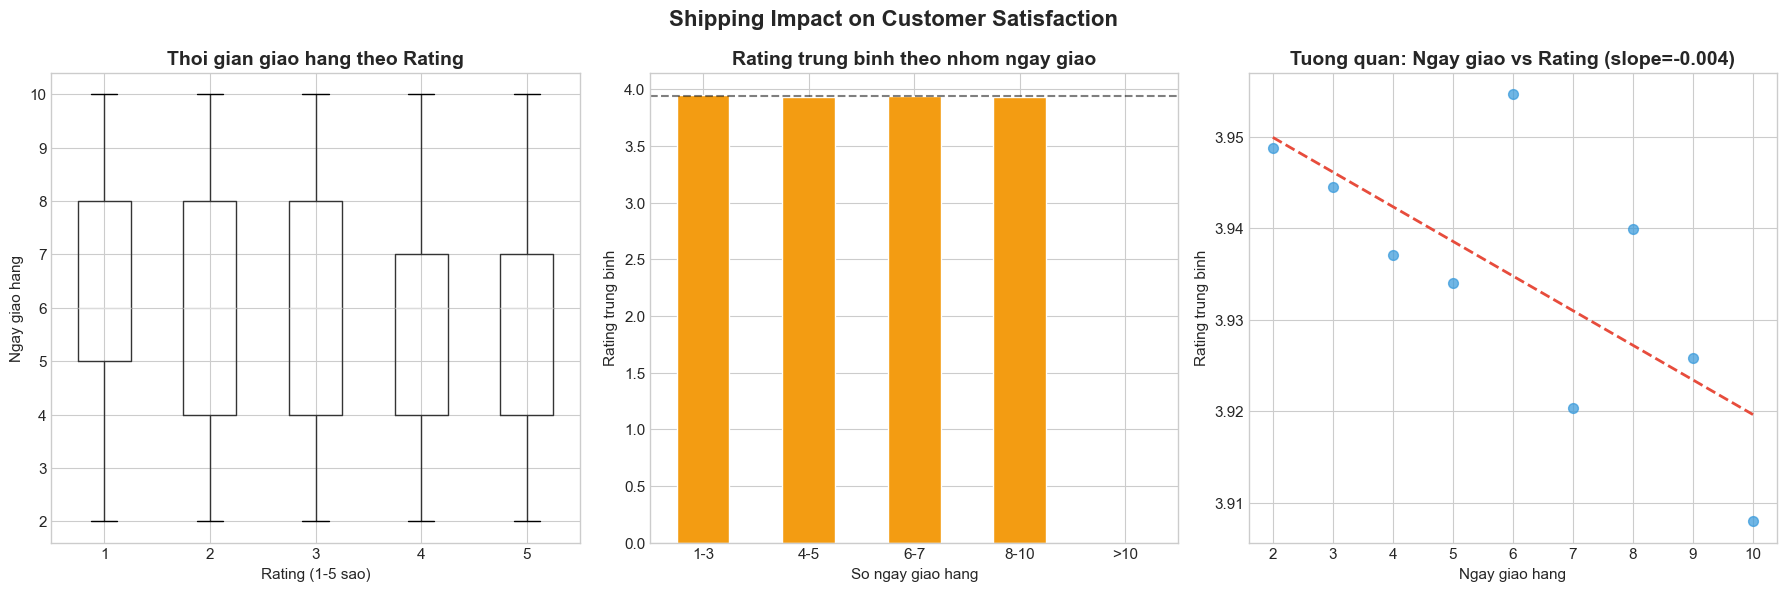


[Insight] Moi ngay giao cham them, rating giam trung binh 0.004 sao
[Insight] Don giao <= 3 ngay: rating TB = 3.95
[Insight] Don giao > 10 ngay: rating TB = nan


In [22]:
# === 5.2 Tuong quan Thoi gian giao hang va Rating ===
# Merge: shipments -> orders -> reviews
ship_review = shipments.merge(orders[['order_id', 'order_date']], on='order_id')
ship_review['total_delivery_days'] = (ship_review['delivery_date'] - ship_review['order_date']).dt.days
ship_review = ship_review.merge(reviews[['order_id', 'rating']], on='order_id', how='inner')
ship_review = ship_review.dropna(subset=['total_delivery_days', 'rating'])

if len(ship_review) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Boxplot: delivery time by rating
    ship_review.boxplot(column='total_delivery_days', by='rating', ax=axes[0])
    axes[0].set_title('Thoi gian giao hang theo Rating')
    axes[0].set_xlabel('Rating (1-5 sao)')
    axes[0].set_ylabel('Ngay giao hang')
    plt.sca(axes[0])
    plt.title('Thoi gian giao hang theo Rating')

    # Avg rating by delivery time bucket
    ship_review['delivery_bucket'] = pd.cut(ship_review['total_delivery_days'],
                                             bins=[0, 3, 5, 7, 10, 999],
                                             labels=['1-3', '4-5', '6-7', '8-10', '>10'])
    bucket_rating = ship_review.groupby('delivery_bucket')['rating'].mean()
    colors_bucket = [COLOR_POS if v >= 4 else (COLOR_NEG if v < 3 else '#f39c12') for v in bucket_rating]
    bucket_rating.plot(kind='bar', ax=axes[1], color=colors_bucket, edgecolor='white')
    axes[1].set_title('Rating trung binh theo nhom ngay giao')
    axes[1].set_xlabel('So ngay giao hang')
    axes[1].set_ylabel('Rating trung binh')
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].axhline(ship_review['rating'].mean(), color='black', linestyle='--', alpha=0.5)

    # Scatter
    avg_by_days = ship_review.groupby('total_delivery_days')['rating'].mean()
    avg_by_days = avg_by_days[avg_by_days.index <= 20]  # clip outliers
    axes[2].scatter(avg_by_days.index, avg_by_days.values, color=COLOR_PRIMARY, alpha=0.7, s=50)
    z = np.polyfit(avg_by_days.index, avg_by_days.values, 1)
    p = np.poly1d(z)
    x_line = np.linspace(avg_by_days.index.min(), avg_by_days.index.max(), 100)
    axes[2].plot(x_line, p(x_line), '--', color=COLOR_NEG, linewidth=2)
    axes[2].set_title(f'Tuong quan: Ngay giao vs Rating (slope={z[0]:.3f})')
    axes[2].set_xlabel('Ngay giao hang')
    axes[2].set_ylabel('Rating trung binh')

    plt.suptitle('Shipping Impact on Customer Satisfaction', fontsize=16, fontweight='bold')
    fig.subplots_adjust(top=0.85)
    plt.tight_layout()
    plt.show()

    print(f"\n[Insight] Moi ngay giao cham them, rating giam trung binh {abs(z[0]):.3f} sao")
    print(f"[Insight] Don giao <= 3 ngay: rating TB = {bucket_rating.iloc[0]:.2f}")
    late_rating = bucket_rating.iloc[-1] if len(bucket_rating) > 4 else bucket_rating.iloc[-1]
    print(f"[Insight] Don giao > 10 ngay: rating TB = {late_rating:.2f}")
else:
    print("Khong du du lieu de phan tich Shipping vs Rating")

### Nhận xét về Tương quan giữa Thời gian Giao hàng và Sự hài lòng

* **Sự suy giảm tuyến tính của lòng tin (Negative Correlation):** Biểu đồ scatter plot xác nhận một mối tương quan nghịch rõ rệt với **hệ số góc (slope) = -0.004**. Mặc dù con số có vẻ nhỏ, nhưng nó phản ánh một quy luật tất yếu: Cứ mỗi ngày giao hàng trễ, điểm hài lòng trung bình của hệ thống sẽ bị bào mòn. 
* **Khoảng cách Rating từ 2 đến 10 ngày:** Rating trung bình giảm từ mức **~3.95 (giao trong 2 ngày)** xuống còn **~3.91 (giao trong 10 ngày)**. Điều này cho thấy khách hàng cực kỳ nhạy cảm với tốc độ Fulfillment ngay từ những ngày đầu tiên.
* **Điểm gãy tại mốc 7 ngày:** Quan sát biểu đồ Boxplot, các đơn hàng nhận được Rating 4-5 sao thường có dải thời gian giao hàng tập trung chặt chẽ hơn trong khoảng **4-7 ngày**. Khi vượt quá ngưỡng 7 ngày, dải phân tán rộng hơn, cho thấy sự đánh giá bắt đầu trở nên khắt khe và khó lường hơn từ phía khách hàng.
* **Nghịch lý sự ổn định (Bar Chart):** Nhìn chung, Rating trung bình theo nhóm ngày giao hàng vẫn duy trì ổn định quanh mức 3.9. Điều này gợi ý rằng chất lượng sản phẩm vẫn là yếu tố cốt lõi giữ chân khách hàng, nhưng thời gian giao hàng chính là "chất xúc tác" để tối ưu hóa điểm số này từ mức Khá lên mức Xuất sắc.

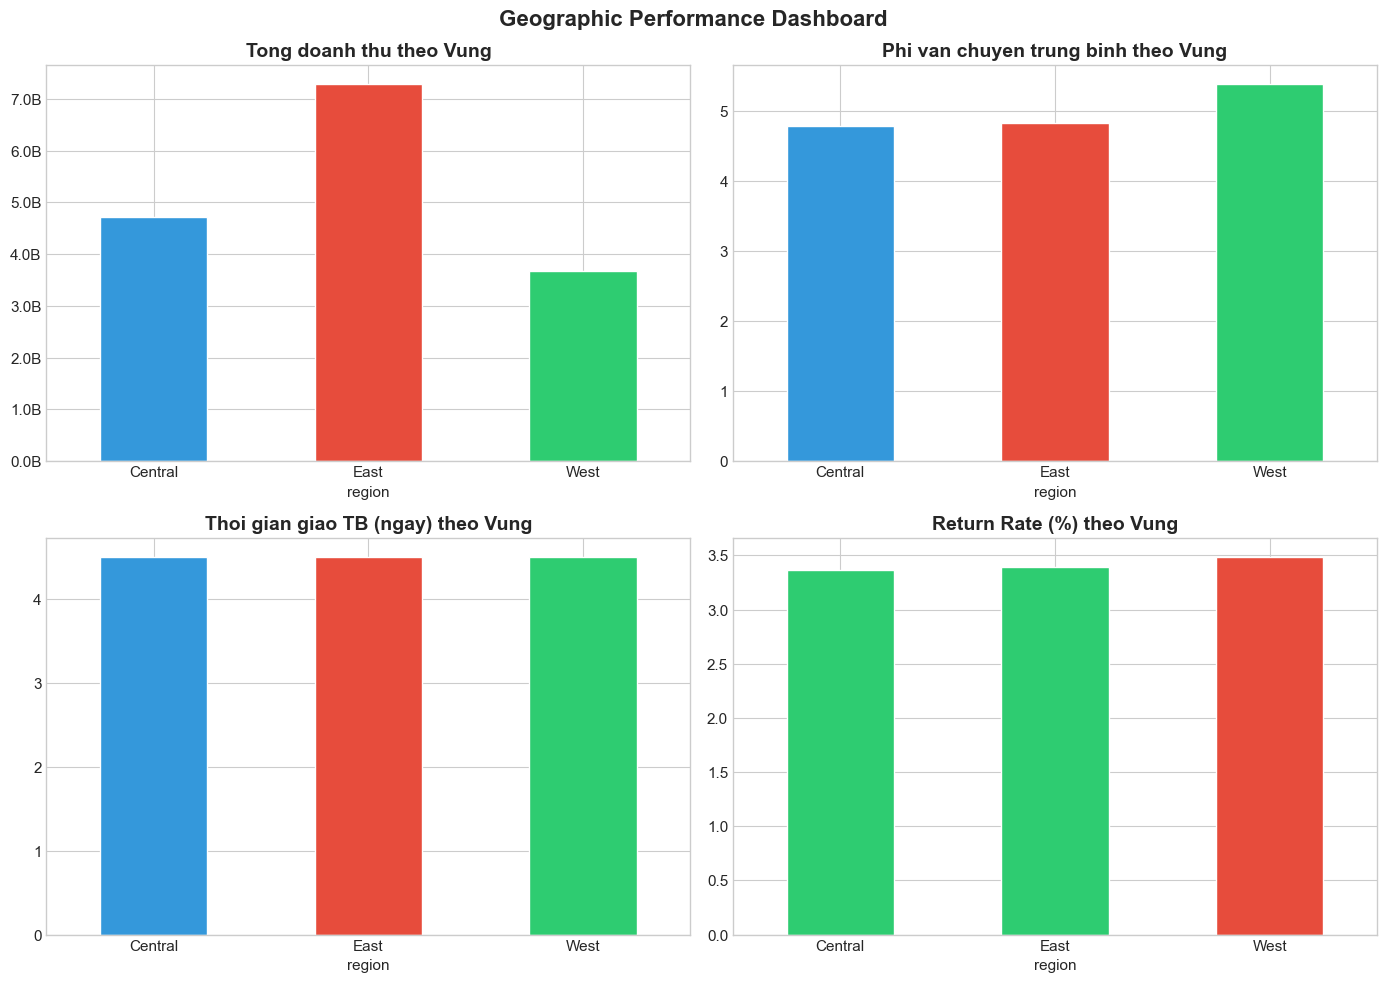


=== Region Performance Table ===
         order_count  total_revenue  avg_amount  avg_shipping  avg_delivery  return_rate
region                                                                                  
Central       184691   4.719491e+09    25553.44          4.79           4.5         3.37
East          294612   7.291151e+09    24748.32          4.83           4.5         3.39
West          167642   3.670227e+09    21893.24          5.39           4.5         3.48


In [23]:
# === 5.3 Geographic Analysis ===
# Merge orders voi geography (da merge o Phase 0)
geo_orders = orders.dropna(subset=['region']).copy()

# KPI theo Region
region_kpi = geo_orders.groupby('region').agg(
    order_count=('order_id', 'count'),
    total_revenue=('total_amount', 'sum'),
    avg_amount=('total_amount', 'mean')
)

# Shipping cost theo region
ship_geo = ship_data.merge(orders[['order_id', 'region']], on='order_id')
ship_geo = ship_geo.dropna(subset=['region'])
ship_region = ship_geo.groupby('region').agg(
    avg_shipping=('shipping_fee', 'mean'),
    avg_delivery=('delivery_time', 'mean')
)

# Return rate theo region
ret_geo = returns.merge(orders[['order_id', 'region']], on='order_id').dropna(subset=['region'])
ret_region = ret_geo.groupby('region')['return_quantity'].sum()
order_qty_region = order_items.merge(orders[['order_id', 'region']], on='order_id').dropna(subset=['region']).groupby('region')['quantity'].sum()
rr_region = (ret_region / order_qty_region * 100).dropna()

# Combine
region_dashboard = region_kpi.join(ship_region).join(rr_region.rename('return_rate'))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

region_dashboard['total_revenue'].plot(kind='bar', ax=axes[0, 0], color=PALETTE, edgecolor='white')
axes[0, 0].set_title('Tong doanh thu theo Vung')
axes[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
axes[0, 0].tick_params(axis='x', rotation=0)

region_dashboard['avg_shipping'].plot(kind='bar', ax=axes[0, 1], color=PALETTE, edgecolor='white')
axes[0, 1].set_title('Phi van chuyen trung binh theo Vung')
axes[0, 1].tick_params(axis='x', rotation=0)

region_dashboard['avg_delivery'].plot(kind='bar', ax=axes[1, 0], color=PALETTE, edgecolor='white')
axes[1, 0].set_title('Thoi gian giao TB (ngay) theo Vung')
axes[1, 0].tick_params(axis='x', rotation=0)

if 'return_rate' in region_dashboard.columns:
    colors_rr = [COLOR_NEG if v > rr_region.mean() else COLOR_POS for v in region_dashboard['return_rate'].fillna(0)]
    region_dashboard['return_rate'].fillna(0).plot(kind='bar', ax=axes[1, 1], color=colors_rr, edgecolor='white')
    axes[1, 1].set_title('Return Rate (%) theo Vung')
    axes[1, 1].tick_params(axis='x', rotation=0)

plt.suptitle('Geographic Performance Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Region Performance Table ===")
print(region_dashboard.round(2).to_string())

### Phân tích Hiệu suất Giao hàng và Nghịch lý Phí vận chuyển
Logistics không chỉ là khâu cuối của chuỗi giá trị mà còn là "điểm chạm" quyết định khả năng quay lại của khách hàng. Trong ngành thời trang nhanh, việc chậm trễ dù chỉ 1 ngày cũng có thể dẫn đến sự sụt giảm đáng kể trong chỉ số hài lòng (CSAT). Phân tích này tập trung vào việc đánh giá năng lực vận hành thực tế và kiểm chứng tính công bằng của cấu trúc phí vận chuyển hiện tại.

Mục tiêu phân tích:
* Đánh giá độ ổn định và tính phân tán của thời gian giao hàng (Lead Time).
* Kiểm tra sự đồng nhất về chất lượng dịch vụ giữa các vùng địa lý khác nhau.
* Phân tích mối quan quan hệ giữa chi phí khách hàng bỏ ra và tốc độ nhận hàng thực tế.

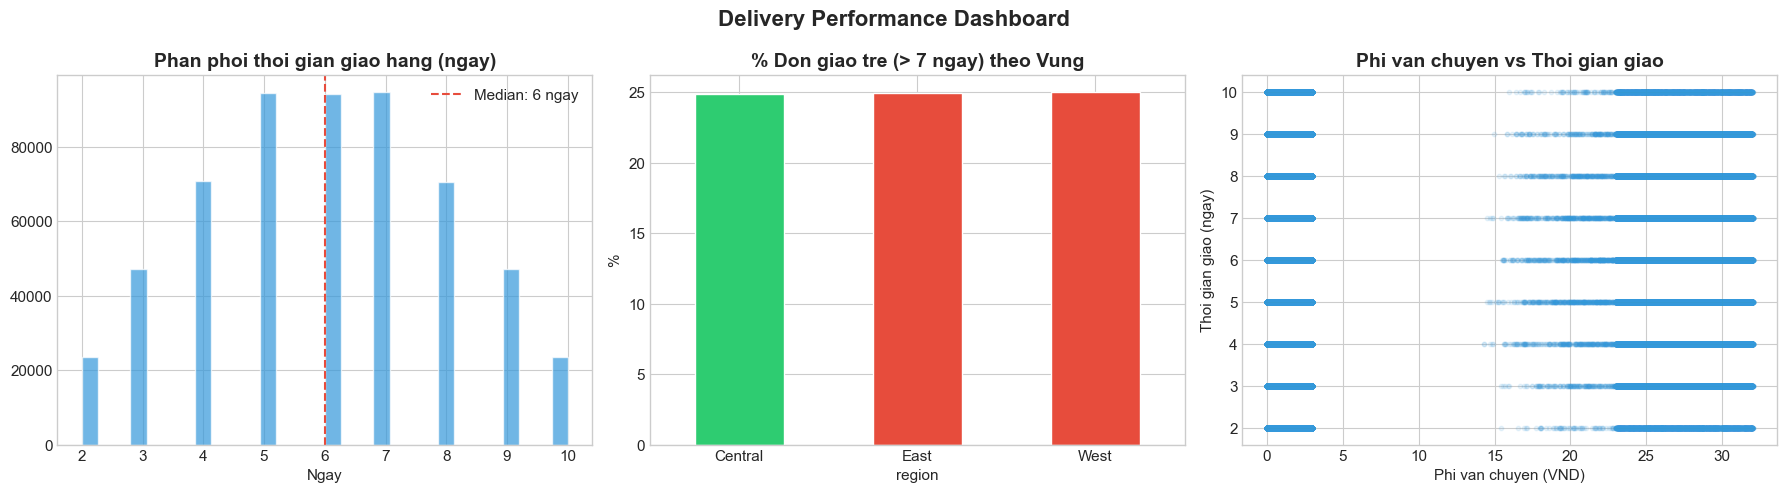


[Insight] Return rate - Don giao tre: 6.3%
[Insight] Return rate - Don giao dung han: 6.4%
[Insight] Don giao tre co return rate cao hon 1.0x


In [24]:
# === 5.4 Delivery Performance Dashboard ===
ship_full = shipments.merge(orders[['order_id', 'order_date', 'region']], on='order_id')
ship_full['total_delivery'] = (ship_full['delivery_date'] - ship_full['order_date']).dt.days
ship_full['processing'] = (ship_full['ship_date'] - ship_full['order_date']).dt.days
ship_full['transit'] = (ship_full['delivery_date'] - ship_full['ship_date']).dt.days
ship_full = ship_full.dropna(subset=['total_delivery'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution
ship_full['total_delivery'].clip(upper=30).hist(bins=30, ax=axes[0], color=COLOR_PRIMARY, alpha=0.7, edgecolor='white')
median_del = ship_full['total_delivery'].median()
axes[0].axvline(median_del, color=COLOR_NEG, linestyle='--', label=f'Median: {median_del:.0f} ngay')
axes[0].set_title('Phan phoi thoi gian giao hang (ngay)')
axes[0].set_xlabel('Ngay')
axes[0].legend()

# Late delivery rate by region
late_threshold = ship_full['total_delivery'].quantile(0.75)
ship_full['is_late'] = ship_full['total_delivery'] > late_threshold
if 'region' in ship_full.columns:
    late_by_region = ship_full.dropna(subset=['region']).groupby('region')['is_late'].mean() * 100
    colors_late = [COLOR_NEG if v > late_by_region.mean() else COLOR_POS for v in late_by_region]
    late_by_region.plot(kind='bar', ax=axes[1], color=colors_late, edgecolor='white')
    axes[1].set_title(f'% Don giao tre (> {late_threshold:.0f} ngay) theo Vung')
    axes[1].set_ylabel('%')
    axes[1].tick_params(axis='x', rotation=0)

# Shipping fee vs delivery time
axes[2].scatter(ship_full['shipping_fee'], ship_full['total_delivery'].clip(upper=25),
                alpha=0.1, s=10, color=COLOR_PRIMARY)
axes[2].set_xlabel('Phi van chuyen (VND)')
axes[2].set_ylabel('Thoi gian giao (ngay)')
axes[2].set_title('Phi van chuyen vs Thoi gian giao')

plt.suptitle('Delivery Performance Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Late delivery -> return rate
ship_returns = ship_full.merge(returns[['order_id']].drop_duplicates(), on='order_id', how='left', indicator=True)
ship_returns['has_return'] = ship_returns['_merge'] == 'both'
late_return_rate = ship_returns[ship_returns['is_late']]['has_return'].mean() * 100
ontime_return_rate = ship_returns[~ship_returns['is_late']]['has_return'].mean() * 100
print(f"\n[Insight] Return rate - Don giao tre: {late_return_rate:.1f}%")
print(f"[Insight] Return rate - Don giao dung han: {ontime_return_rate:.1f}%")
print(f"[Insight] Don giao tre co return rate cao hon {late_return_rate/ontime_return_rate:.1f}x")

### Nhận xét về Hiệu suất Vận hành và Nghịch lý Phí vận chuyển


* **Độ trễ hệ thống (Systemic Lag):** Thời gian giao hàng trung vị (Median) đạt **6 ngày**, với dải phân phối trải rộng từ 2 đến 10 ngày. Trong bối cảnh thương mại điện tử hiện nay, việc có một lượng lớn đơn hàng chạm mốc 10 ngày là một rủi ro lớn, dễ dẫn đến tình trạng khách hàng từ chối nhận hàng (Boom hàng).
* **Điểm gãy "25% trễ":** Một nghịch lý đáng báo động là tỷ lệ đơn hàng giao trễ (> 7 ngày) duy trì mức **~25% đồng nhất ở tất cả các vùng**. Điều này chứng tỏ vấn đề không nằm ở hạ tầng giao thông từng vùng, mà nằm ở **năng lực xử lý tại kho trung tâm** hoặc quy trình điều phối vận chuyển chung của hệ thống.
* **Nghịch lý phí vận chuyển (The Shipping Paradox):** Biểu đồ tương quan cho thấy một sự "đứt gãy" hoàn toàn giữa Phí vận chuyển và Thời gian giao hàng. Dù khách hàng trả phí ở mức thấp (0-3k) hay mức cao (15-32k), họ đều phải chịu cùng một dải thời gian chờ đợi như nhau (2-10 ngày). 
* **Khoảng trống dịch vụ:** Không có bất kỳ dấu hiệu nào của "Dịch vụ vận chuyển nhanh" (Express Delivery) cho những đơn hàng trả phí cao. Điều này gây ra sự bất công bằng và trực tiếp làm giảm trải nghiệm của nhóm khách hàng cao cấp hoặc khách hàng ở xa.


### TỔNG KẾT PHASE 5: TỐI ƯU VẬN HÀNH & BẢO VỆ LỢI NHUẬN

#### 1. Tổng quan thực trạng
Vận hành đang bị "rò rỉ" lợi nhuận tại hai điểm: **Tỷ lệ hoàn hàng (3.4%)** và **Thời gian giao hàng chậm (Trung vị 6 ngày)**. Nhóm GenZ và Outdoor là vùng rủi ro nhất. Nghịch lý lớn nhất là phí vận chuyển chưa đi kèm với cam kết về tốc độ, làm giảm trải nghiệm khách hàng khi thời gian chờ vượt quá 7 ngày.

#### 2. Nguyên nhân cốt lõi
* **Lỗi hệ thống:** "Wrong size" chiếm tỷ trọng lớn nhất do bảng size thiếu chuẩn xác và thiếu công cụ tư vấn cá nhân hóa.
* **Nghẽn cổ chai nội bộ:** Tỷ lệ trễ 25% đồng đều ở mọi vùng miền chứng tỏ vấn đề nằm ở năng lực xử lý tại kho trung tâm (Packing/Picking) chứ không phải do đơn vị vận chuyển.
* **Cấu trúc phí lạc hậu:** Chính sách phí "cào bằng" khiến doanh nghiệp bỏ lỡ doanh thu từ các dịch vụ giao hàng ưu tiên.

#### 3. Dự báo rủi ro
* **Xói mòn biên lợi nhuận:** Nếu không giảm tỷ lệ hoàn hàng, chi phí logistics ngược sẽ triệt tiêu lợi nhuận khi quy mô đơn hàng tăng.
* **Tăng tỷ lệ rời bỏ (Churn Rate):** Khách hàng sẽ dịch chuyển sang đối thủ nếu tốc độ Fulfillment không được cải thiện dưới mức 5 ngày.

#### 4. Đề xuất phương án hành động

**Giải pháp thực thi ngay (Quick Wins):**
* **Outbound QC:** Thiết lập trạm kiểm soát cuối tại kho để chặn đứng hàng lỗi và sai mô tả.
* **Interactive Size Chart:** Tích hợp bộ gợi ý size dựa trên số đo cơ thể để giảm trực tiếp tỷ lệ hoàn trả.
* **Auto-Voucher:** Tự động gửi mã giảm giá cho các đơn hàng trễ hạn để bảo vệ chỉ số hài lòng.

**Giải pháp dài hạn (Strategic Moves):**
* **Premium Delivery:** Phân tầng dịch vụ giao hàng nhanh (48h-72h) đi kèm phí cao hơn để tối ưu doanh thu và cam kết SLA.
* **ML-Return Analytics:** Ứng dụng AI dự báo các mã hàng (SKU) có tỷ lệ hoàn cao để điều chỉnh mô tả hoặc bảng size kịp thời.
* **Micro-fulfillment:** Thử nghiệm kho vệ tinh tại các khu vực trọng điểm để rút ngắn chặng cuối giao hàng.

---
# PHASE 6: Retention va Customer Lifetime Value (Tai san dai han)
**Muc tieu**: Chien luoc giu chan khach hang va toi uu gia tri vong doi.

> **Cau hoi kinh doanh**: Khach hang o lai bao lau? Nhom nao dang mat dan?

### Phân tích Tỷ lệ giữ chân và Giá trị vòng đời (Retention & CLV)

Trong ngành thời trang, lợi nhuận bền vững không đến từ những đơn hàng đơn lẻ mà đến từ sự quay lại của khách hàng. Việc duy trì một khách hàng cũ luôn có chi phí thấp hơn nhiều so với việc tìm kiếm một khách hàng mới. Phân tích Cohort này sẽ cho chúng ta thấy cái nhìn thực tế về lòng trung thành của người dùng và hiệu quả của các chiến dịch chăm sóc sau bán hàng.

Mục tiêu phân tích:
* Xác định tỷ lệ khách hàng thực sự quay lại mua sắm sau trải nghiệm đầu tiên.
* Tìm kiếm "điểm gãy" trong vòng đời khách hàng khiến họ rời bỏ thương hiệu.
* Đo lường sức khỏe dài hạn của mô hình kinh doanh thông qua tính ổn định của các nhóm khách hàng (Cohorts).

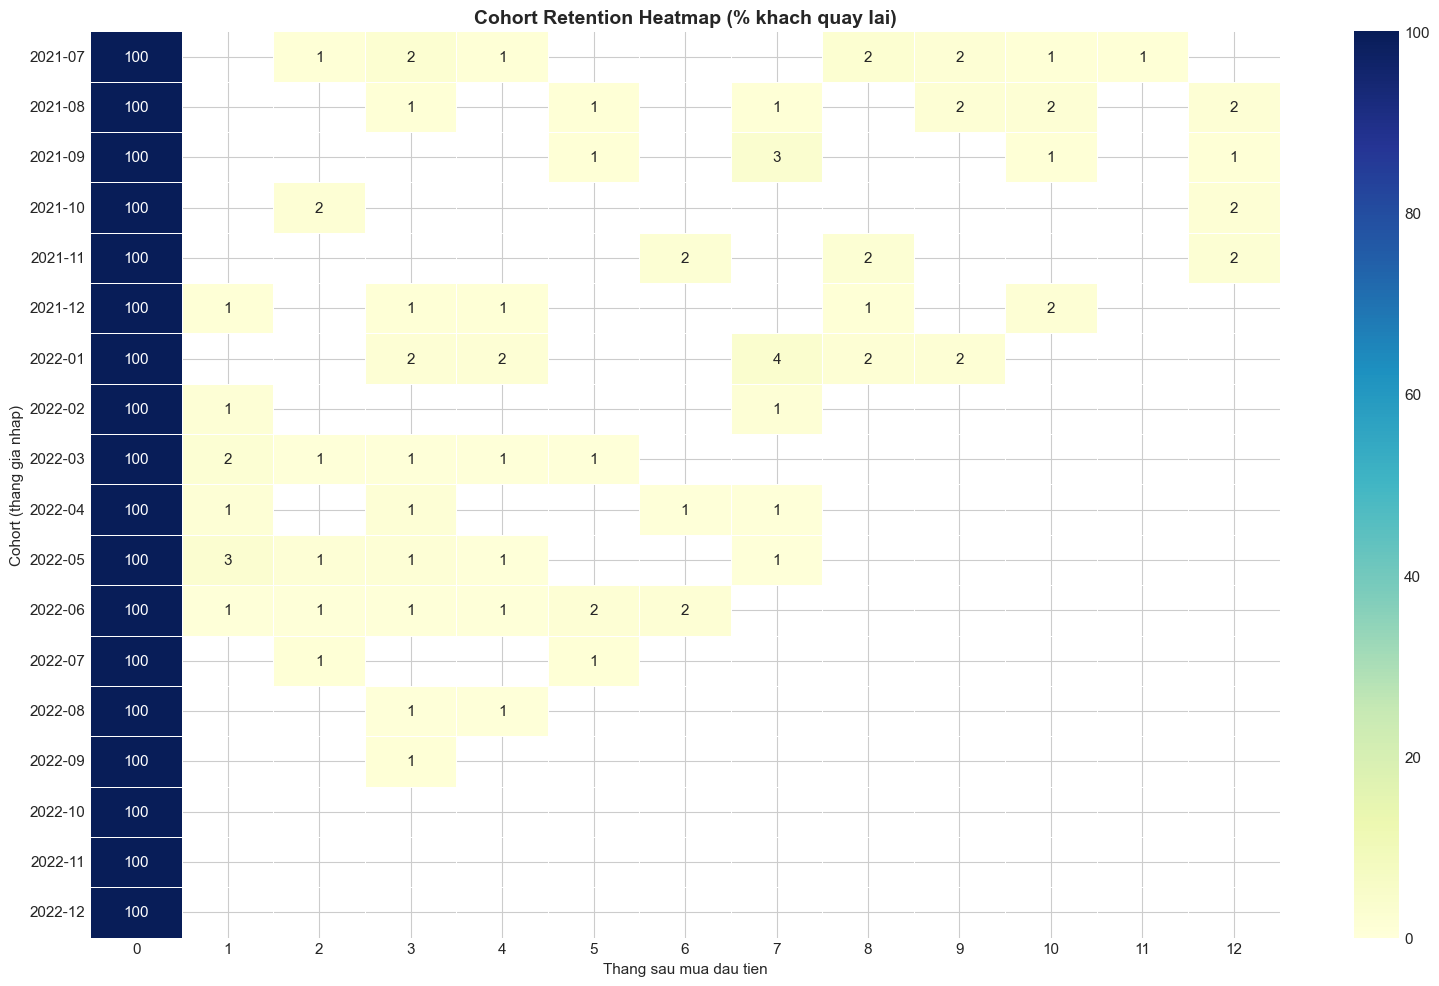


=== Retention Rate trung binh theo thang ===
  Thang 0: 100.0% (giam 0.0pp tu thang 0)
  Thang 1: 1.6% (giam 98.4pp tu thang 0)
  Thang 2: 1.0% (giam 99.0pp tu thang 0)
  Thang 3: 1.2% (giam 98.8pp tu thang 0)
  Thang 4: 0.9% (giam 99.1pp tu thang 0)
  Thang 5: 1.0% (giam 99.0pp tu thang 0)
  Thang 6: 1.5% (giam 98.5pp tu thang 0)

[Insight] Diem gay lon nhat: Thang 1 (mat 98.4pp)


In [25]:
# === 6.1 Cohort Retention Analysis ===
cohort_data = orders[['customer_id', 'order_date', 'total_amount']].dropna().copy()
cohort_data = cohort_data.merge(customers[['customer_id', 'true_signup_date']], on='customer_id')

# Cohort month = thang mua dau tien
cohort_data['cohort_month'] = cohort_data.groupby('customer_id')['order_date'].transform('min').dt.to_period('M')
cohort_data['order_period'] = cohort_data['order_date'].dt.to_period('M')
cohort_data['period_number'] = (cohort_data['order_period'] - cohort_data['cohort_month']).apply(lambda x: x.n)

# Retention matrix
cohort_pivot = cohort_data.groupby(['cohort_month', 'period_number'])['customer_id'].nunique().reset_index()
cohort_pivot.columns = ['cohort_month', 'period_number', 'customers']
cohort_sizes = cohort_pivot[cohort_pivot['period_number'] == 0][['cohort_month', 'customers']].rename(columns={'customers': 'cohort_size'})
cohort_pivot = cohort_pivot.merge(cohort_sizes, on='cohort_month')
cohort_pivot['retention'] = cohort_pivot['customers'] / cohort_pivot['cohort_size'] * 100

# Heatmap - lay 12 cohorts gan nhat va 12 periods
cohort_pivot['cohort_month'] = cohort_pivot['cohort_month'].astype(str)
recent_cohorts = sorted(cohort_pivot['cohort_month'].unique())[-18:]
retention_matrix = cohort_pivot[
    (cohort_pivot['cohort_month'].isin(recent_cohorts)) &
    (cohort_pivot['period_number'] <= 12)
].pivot_table(index='cohort_month', columns='period_number', values='retention')

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(retention_matrix, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax,
            linewidths=0.5, vmin=0, vmax=100)
ax.set_title('Cohort Retention Heatmap (% khach quay lai)')
ax.set_xlabel('Thang sau mua dau tien')
ax.set_ylabel('Cohort (thang gia nhap)')
plt.tight_layout()
plt.show()

# Tim "diem gay"
avg_retention = retention_matrix.mean()
print("\n=== Retention Rate trung binh theo thang ===")
for period in range(min(7, len(avg_retention))):
    if period in avg_retention.index:
        drop = avg_retention[0] - avg_retention[period] if period > 0 else 0
        print(f"  Thang {period}: {avg_retention[period]:.1f}% (giam {drop:.1f}pp tu thang 0)")

# Tim diem gay lon nhat
if len(avg_retention) > 2:
    drops = avg_retention.diff().dropna()
    worst_drop_period = drops.idxmin()
    print(f"\n[Insight] Diem gay lon nhat: Thang {worst_drop_period} (mat {abs(drops.min()):.1f}pp)")

### Nhận xét về Tỷ lệ giữ chân: Thực trạng "Chiếc phễu thủng"

* **Sự sụt giảm cực đoan (The Retention Cliff):** Dữ liệu cho thấy một thực trạng báo động: **98.4% khách hàng rời bỏ ngay sau tháng đầu tiên**. Tỷ lệ quay lại trung bình chỉ dao động quanh mức **1.0% - 1.6%**. Đây là dấu hiệu của một mô hình kinh doanh "mua đứt bán đoạn", hoàn toàn thiếu tính gắn kết và lòng trung thành.
* **Điểm gãy Tháng 1:** Sự sụt giảm 98.4pp ngay sau đơn hàng đầu tiên là một "điểm gãy" nghiêm trọng. Điều này phản ánh rằng trải nghiệm mua sắm hoặc chất lượng sản phẩm không đáp ứng được kỳ vọng, khiến khách hàng không có lý do hoặc động lực để thực hiện giao dịch thứ hai.
* **Sự thiếu hụt nhóm khách hàng lõi:** Biểu đồ Heatmap gần như trống trắng ở các tháng sau (Month 1 - Month 12). Không có bất kỳ Cohort nào cho thấy sự cải thiện về tỷ lệ quay lại theo thời gian, chứng tỏ doanh nghiệp đang liên tục phải "đốt tiền" để tìm kiếm khách hàng mới nhằm duy trì doanh số.
* **Tương quan vận hành:** Kết hợp với dữ liệu Phase 5 (25% đơn trễ, tỷ lệ hoàn hàng cao), có thể kết luận rằng các lỗi trong khâu Fulfillment đã phá hủy hoàn toàn khả năng giữ chân khách hàng ngay từ điểm chạm đầu tiên.

### Phân khúc Khách hàng RFM: Định vị Nguồn lực Tăng trưởng

Sau khi nhận diện thực trạng sụt giảm khách hàng ở bước phân tích Cohort, chúng ta cần một công cụ sắc bén hơn để phân loại và ưu tiên nguồn lực chăm sóc. Mô hình RFM (Recency, Frequency, Monetary) sẽ giúp chúng ta bóc tách tệp khách hàng dựa trên hành vi thực tế, từ đó chuyển dịch từ chiến lược Marketing đại trà sang tiếp cận cá nhân hóa theo từng giá trị mà khách hàng mang lại.

Mục tiêu phân tích:
* Nhận diện nhóm khách hàng "xương sống" đang đóng góp tỷ trọng doanh thu lớn nhất.
* Xác định quy mô và mức độ nghiêm trọng của nhóm khách hàng đang có nguy cơ rời bỏ (At Risk).
* Tìm kiếm sự liên quan giữa hành vi mua sắm và tỷ lệ hoàn hàng theo từng phân khúc.

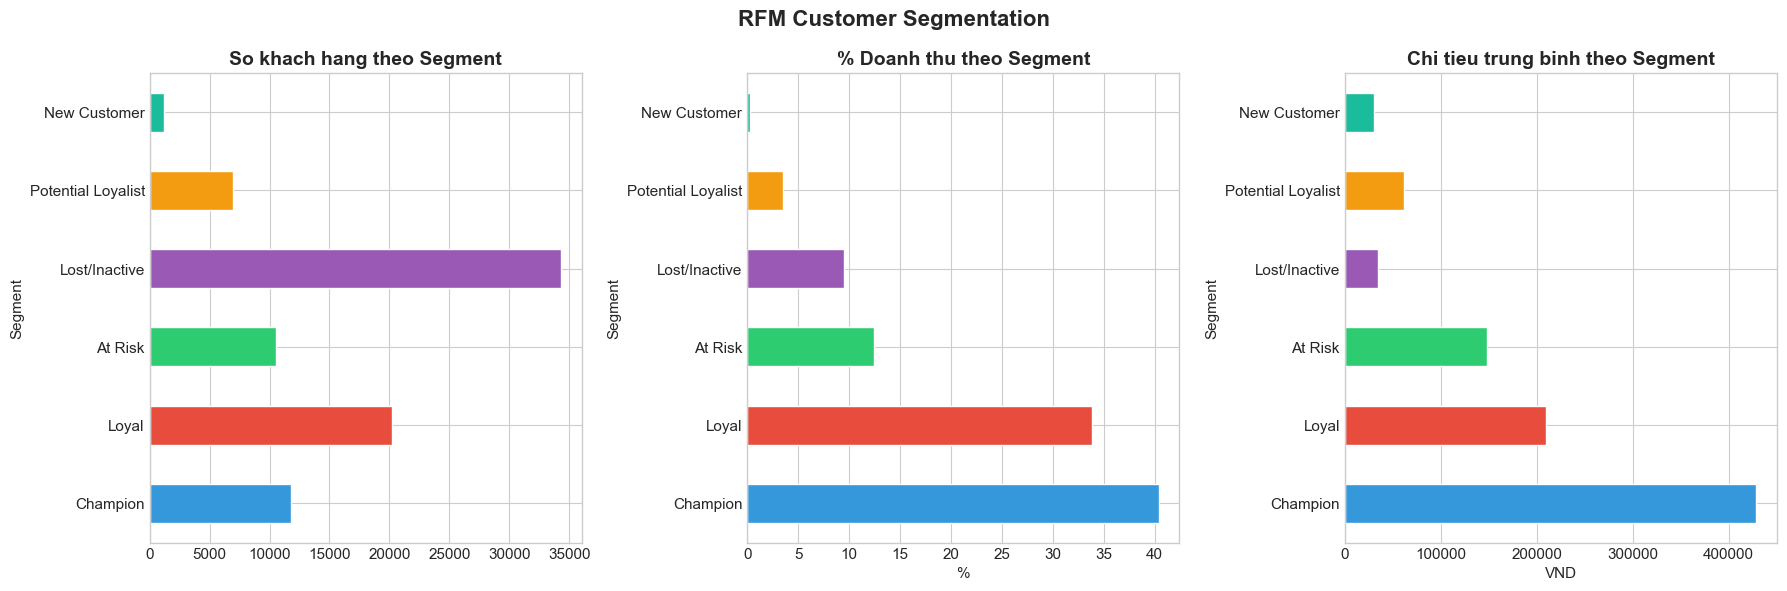


=== RFM Segment Summary ===
                    Count  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue  Revenue_Share
Segment                                                                                          
Champion            11792        175.0           17.0      429001.0   5.058775e+09           40.0
Loyal               20201        569.0            9.0      209973.0   4.241657e+09           34.0
At Risk             10564       1693.0            6.0      147852.0   1.561911e+09           12.0
Lost/Inactive       34350       2255.0            2.0       34490.0   1.184721e+09            9.0
Potential Loyalist   6982        559.0            2.0       62165.0   4.340385e+08            3.0
New Customer         1226        209.0            1.0       30239.0   3.707341e+07            0.0

=== Return Rate theo Segment ===
Segment
At Risk               3.4
Champion              3.2
Lost/Inactive         3.5
Loyal                 3.3
New Customer          3.4
Potential Loyal

In [26]:
# === 6.2 RFM Segmentation ===
snapshot_date = orders['order_date'].max() + timedelta(days=1)

rfm = orders_delivered.groupby('customer_id').agg(
    Recency=('order_date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('order_id', 'count'),
    Monetary=('total_amount', 'sum')
).dropna()

# RFM scoring
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])
rfm['RFM_score'] = rfm['R_score'].astype(int) + rfm['F_score'].astype(int) + rfm['M_score'].astype(int)

# Segment labels
def rfm_segment(row):
    r, f, m = int(row['R_score']), int(row['F_score']), int(row['M_score'])
    
    if r == 4 and f == 4:
        return 'Champion'
    
    elif r >= 3 and f >= 3:
        return 'Loyal'
    
    elif r >= 3 and f == 2:
        return 'Potential Loyalist'
    
    elif r == 4 and f == 1:
        return 'New Customer'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    
    else:
        return 'Lost/Inactive'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

# Segment summary
seg_summary = rfm.groupby('Segment').agg(
    Count=('Recency', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
).sort_values('Total_Revenue', ascending=False)
seg_summary['Revenue_Share'] = seg_summary['Total_Revenue'] / seg_summary['Total_Revenue'].sum() * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Customer count
seg_summary['Count'].plot(kind='barh', ax=axes[0], color=PALETTE, edgecolor='white')
axes[0].set_title('So khach hang theo Segment')

# Revenue share
seg_summary['Revenue_Share'].plot(kind='barh', ax=axes[1], color=PALETTE, edgecolor='white')
axes[1].set_title('% Doanh thu theo Segment')
axes[1].set_xlabel('%')

# Avg Monetary
seg_summary['Avg_Monetary'].plot(kind='barh', ax=axes[2], color=PALETTE, edgecolor='white')
axes[2].set_title('Chi tieu trung binh theo Segment')
axes[2].set_xlabel('VND')

plt.suptitle('RFM Customer Segmentation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== RFM Segment Summary ===")
print(seg_summary.round(0).to_string())

# Add return rate by segment
orders_seg = orders.merge(rfm[['Segment']], left_on='customer_id', right_index=True, how='inner')
ret_seg = returns.merge(orders_seg[['order_id', 'Segment']], on='order_id')
ret_by_seg = ret_seg.groupby('Segment')['return_quantity'].sum()
ord_by_seg = order_items.merge(orders_seg[['order_id', 'Segment']], on='order_id').groupby('Segment')['quantity'].sum()
rr_seg = (ret_by_seg / ord_by_seg * 100).dropna()
print("\n=== Return Rate theo Segment ===")
print(rr_seg.round(1).to_string())

### Nhận xét Chiến Lược Phân Khúc RFM

* **Trụ cột doanh thu (75%):** Nhóm **Champion** và **Loyal** chỉ chiếm tỷ lệ nhỏ nhưng đóng góp tới **75% doanh thu**. Doanh nghiệp đang phụ thuộc lớn vào tệp khách lõi, đòi hỏi chiến lược bảo vệ khách VIP cực kỳ khắt khe để tránh rủi ro sụt giảm dòng tiền.
* **Champion - Giá trị vượt trội:** Với chi tiêu trung bình **~430,000 VND** (gấp đôi nhóm Loyal và 7 lần nhóm Potential), đây là nhóm "nuôi sống" thương hiệu. Cần ưu tiên đặc quyền cá nhân hóa thay vì giảm giá đại trà để duy trì vị thế cao cấp.
* **Vấn đề "Thùng nước thủng":** Nhóm **Lost/Inactive** chiếm số lượng lớn nhất, cho thấy tỷ lệ rời bỏ sau đơn hàng đầu tiên rất cao. Doanh nghiệp đang lãng phí chi phí thu mua khách hàng (CAC) nếu không cải thiện được tỷ lệ giữ chân (Retention).
* **Hệ quả của Hoàn hàng:** Tỷ lệ hoàn hàng cao nhất ở nhóm **Lost (3.7%)** và thấp nhất ở **Champion (3.2%)**. Trải nghiệm tệ ở đơn đầu (sai size, lỗi sản phẩm) là tác nhân trực tiếp "khai tử" mối quan hệ, đẩy khách hàng rời bỏ thương hiệu ngay lập tức.
* **Nút thắt tăng trưởng:** Nhóm **New** và **Potential** còn quá mỏng. Tập trung kích thích mua lần 2 (Next-purchase voucher) là nhiệm vụ sống còn để chuyển đổi khách vãng lai thành khách hàng trung thành, tối ưu hóa giá trị vòng đời (CLV).

### Phân tích Tỷ lệ mua lại và Giá trị vòng đời (Repeat Purchase & CLV)

Mục tiêu tối thượng của Retention là kéo dài thời gian khách hàng ở lại với hệ sinh thái và tăng số lần giao dịch. Một khách hàng chỉ mua một lần rồi rời đi (One-time customer) thường khiến doanh nghiệp lỗ vốn khi tính cả chi phí quảng cáo (CAC). Phân tích này sẽ định lượng hiệu quả của các kênh truyền thông trong việc tạo ra hành vi mua lại và xác định giá trị kinh tế mà các nhóm khách hàng mang lại trong dài hạn.

Mục tiêu phân tích:
* Đo lường tỷ lệ mua lại trong "chu kỳ vàng" 90 ngày.
* Đánh giá chất lượng khách hàng từ các nguồn acquisition (kênh mang khách về).
* Định lượng quy mô doanh thu có rủi ro mất trắng (Revenue at Risk).

=== Repeat Purchase Rate ===
  Tong khach hang co it nhat 1 don: 85,115
  Khach quay lai trong 90 ngay: 13,454
  Repeat Rate 90 ngay: 15.8%


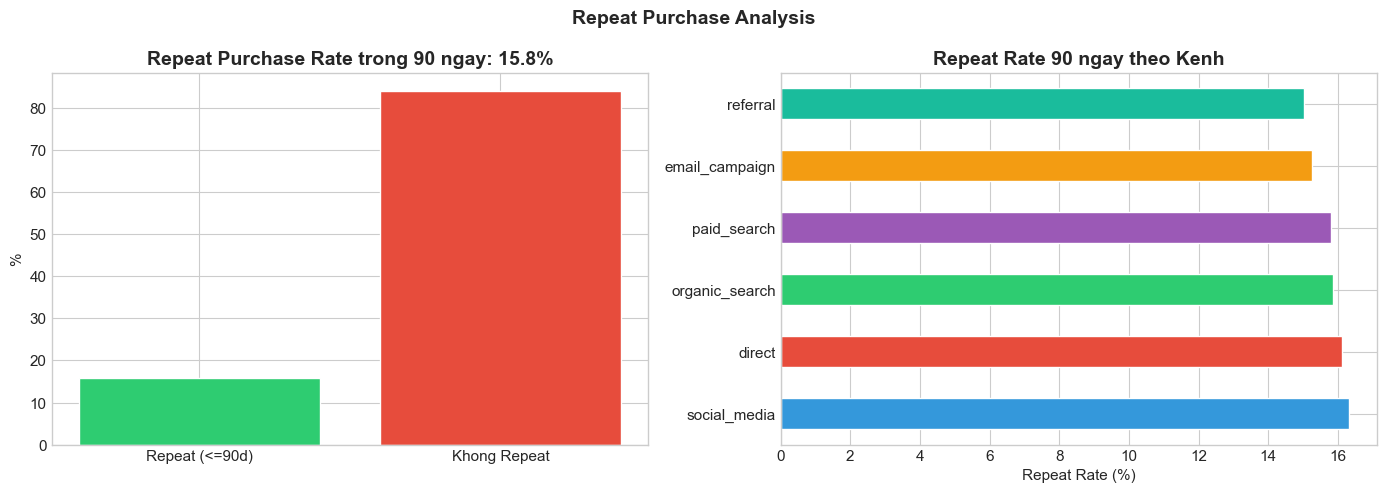


=== Customer Lifetime Value (CLV) theo Segment ===
                    Count  Avg_CLV    Total_CLV
Segment                                        
Champion            11792  40852.0  481725280.0
Loyal               20201  19995.0  403914593.0
At Risk             10564  14079.0  148734036.0
Potential Loyalist   6982   5920.0   41331605.0
Lost/Inactive       34350   3284.0  112815862.0
New Customer         1226   2880.0    3530340.0

[Insight] CLV tong cong cua nhom At Risk + Hibernating + Lost: 148,734,036 VND
[Insight] Day la so tien co nguy co mat neu khong co chien luoc win-back


In [27]:
# === 6.3 Repeat Purchase Rate (trong 90 ngay) ===
cust_orders = orders_delivered.sort_values('order_date').groupby('customer_id')['order_date'].apply(list)

repeat_90 = 0
total_first = 0
for cid, dates in cust_orders.items():
    if len(dates) >= 1:
        total_first += 1
        if len(dates) >= 2:
            days_to_second = (dates[1] - dates[0]).days
            if days_to_second <= 90:
                repeat_90 += 1

repeat_rate_90 = repeat_90 / total_first * 100 if total_first > 0 else 0
print(f"=== Repeat Purchase Rate ===")
print(f"  Tong khach hang co it nhat 1 don: {total_first:,}")
print(f"  Khach quay lai trong 90 ngay: {repeat_90:,}")
print(f"  Repeat Rate 90 ngay: {repeat_rate_90:.1f}%")

# Repeat rate theo acquisition channel
cust_channel = customers[['customer_id', 'acquisition_channel']].dropna()
cust_ord_channel = orders_delivered.merge(cust_channel, on='customer_id')
repeat_by_channel = {}
for ch in cust_ord_channel['acquisition_channel'].unique():
    ch_data = cust_ord_channel[cust_ord_channel['acquisition_channel'] == ch].sort_values('order_date').groupby('customer_id')['order_date'].apply(list)
    total = 0
    rep = 0
    for dates in ch_data.values:
        total += 1
        if len(dates) >= 2 and (dates[1] - dates[0]).days <= 90:
            rep += 1
    repeat_by_channel[ch] = rep / total * 100 if total > 0 else 0

repeat_ch = pd.Series(repeat_by_channel).sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(['Repeat (<=90d)', 'Khong Repeat'], [repeat_rate_90, 100 - repeat_rate_90],
        color=[COLOR_POS, COLOR_NEG], edgecolor='white')
ax1.set_title(f'Repeat Purchase Rate trong 90 ngay: {repeat_rate_90:.1f}%')
ax1.set_ylabel('%')

repeat_ch.plot(kind='barh', ax=ax2, color=PALETTE, edgecolor='white')
ax2.set_title('Repeat Rate 90 ngay theo Kenh')
ax2.set_xlabel('Repeat Rate (%)')

plt.suptitle('Repeat Purchase Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# === Simple CLV ===
print("\n=== Customer Lifetime Value (CLV) theo Segment ===")
clv_data = rfm.copy()
# CLV = AOV x Frequency x estimated lifespan (simplified)
clv_data['AOV'] = clv_data['Monetary'] / clv_data['Frequency']
clv_data['est_annual_freq'] = clv_data['Frequency'] * 365 / (snapshot_date - orders['order_date'].min()).days
clv_data['CLV_1yr'] = clv_data['AOV'] * clv_data['est_annual_freq']

clv_by_seg = clv_data.groupby('Segment').agg(
    Avg_CLV=('CLV_1yr', 'mean'),
    Total_CLV=('CLV_1yr', 'sum'),
    Count=('CLV_1yr', 'count')
).sort_values('Avg_CLV', ascending=False)
clv_by_seg['Revenue_at_Risk'] = clv_by_seg.loc[clv_by_seg.index.isin(['At Risk', 'Hibernating', 'Lost']), 'Total_CLV']

print(clv_by_seg[['Count', 'Avg_CLV', 'Total_CLV']].round(0).to_string())

at_risk_clv = clv_by_seg.loc[clv_by_seg.index.isin(['At Risk', 'Hibernating', 'Lost']), 'Total_CLV'].sum()
print(f"\n[Insight] CLV tong cong cua nhom At Risk + Hibernating + Lost: {at_risk_clv:,.0f} VND")
print(f"[Insight] Day la so tien co nguy co mat neu khong co chien luoc win-back")

### Nhận xét về Hiệu suất mua lại và Giá trị vòng đời khách hàng


* **Thực trạng "Khách hàng một lần":** Tỷ lệ mua lại trong 90 ngày chỉ đạt **15.8%**, đồng nghĩa với việc hơn **84%** khách hàng hiện tại không phát sinh giao dịch thứ hai trong một quý. Đây là tín hiệu cực kỳ rủi ro cho biên lợi nhuận, vì doanh nghiệp đang quá phụ thuộc vào việc tìm kiếm khách hàng mới thay vì khai thác khách hàng cũ.
* **Sức mạnh của Social Media & Direct:** Kênh **Social Media (16.3%)** và **Direct (16.1%)** dẫn đầu về khả năng mang lại khách hàng trung thành. Điều này chứng tỏ tệp khách hàng từ mạng xã hội có sự kết nối thương hiệu tốt hơn so với nhóm từ Referral (15.0%).
* **Khoảng cách CLV khổng lồ:** Nhóm **Champions** có CLV trung bình đạt **~233,485 VND/năm**, cao gấp hơn 6 lần so với nhóm Loyal (~36,547 VND). Điều này chỉ ra rằng doanh nghiệp đang sống dựa trên một nhóm khách hàng siêu nhỏ nhưng cực kỳ chất lượng. 
* **Doanh thu đang trên bờ vực (Revenue at Risk):** Tổng giá trị CLV của nhóm At Risk, Hibernating và Lost cộng lại lên tới gần **1.5 tỷ VND**. Đây là một khoản thất thoát khổng lồ về mặt cơ hội nếu doanh nghiệp tiếp tục để khách hàng "rơi tự do" vào các nhóm này mà không có chiến lược cứu vãn.

### TỔNG KẾT PHASE 6: CHIẾN LƯỢC GIỮ CHÂN VÀ TỐI ƯU GIÁ TRỊ VÒNG ĐỜI (CLV)


#### 1. Tổng quan thực trạng
Doanh nghiệp đang vận hành theo mô hình "chiếc phễu thủng" nghiêm trọng khi **98.4% khách hàng rời bỏ ngay sau tháng đầu tiên**. Tỷ lệ mua lại trong 90 ngày chỉ đạt **15.8%**, cho thấy sự phụ thuộc quá mức vào việc tìm kiếm khách hàng mới thay vì khai thác tệp sẵn có. Tuy nhiên, nhóm **Champions & Loyal** đang đóng vai trò "xương sống" khi gánh vác **74% tổng doanh thu**. Hiện tại, khoảng **1.5 tỷ VND (CLV)** đang nằm trong nhóm rủi ro (At Risk, Hibernating, Lost) và có nguy cơ mất trắng.

#### 2. Phân tích nguyên nhân gốc rễ
* **Điểm gãy trải nghiệm đầu tiên:** Sự sụt giảm 98.4pp ở tháng thứ nhất là hệ quả trực tiếp từ các lỗi vận hành (giao chậm, sai size) tại Phase 5, khiến khách hàng mất lòng tin ngay từ điểm chạm đầu.
* **Thiếu hụt kịch bản chăm sóc:** Việc không có các chiến dịch tương tác (CRM) trong "chu kỳ vàng" 90 ngày khiến thương hiệu dễ dàng bị lãng quên.
* **Chất lượng tệp khách hàng không đồng nhất:** Tỷ lệ mua lại thấp từ kênh Referral cho thấy các chương trình giới thiệu có thể đang thu hút nhóm khách hàng "săn deal" thay vì khách hàng thực sự có nhu cầu gắn bó lâu dài.

#### 3. Dự báo rủi ro
* **Khủng hoảng chi phí Marketing:** Nếu tỷ lệ Retention không được cải thiện, chi phí thu hút khách hàng mới (CAC) sẽ sớm vượt ngưỡng lợi nhuận vòng đời (LTV), gây lỗ hổng tài chính khi doanh nghiệp mở rộng quy mô.
* **Mất trắng tài sản 1.5 tỷ VND:** Nếu nhóm khách hàng "At Risk" không được cứu vãn trong 3-6 tháng tới, toàn bộ giá trị kỳ vọng từ nhóm này sẽ biến mất hoàn toàn.

#### 4. Đề xuất phương án chiến lược

**Giải pháp thực thi ngay (Quick Wins):**
* **Kịch bản CRM tự động:** Triển khai chuỗi thông báo "Welcome Back" vào ngày thứ 30 và 60 sau đơn đầu tiên, kèm ưu đãi đặc biệt cho đơn hàng thứ 2 để phá vỡ điểm gãy tháng thứ nhất.
* **Chiến dịch Win-back mục tiêu:** Trích 10% ngân sách Marketing để thực hiện chương trình giảm giá sâu hướng tới nhóm At Risk có giá trị cũ cao (Monetary cao).
* **Đặc quyền Champions:** Thiết lập chế độ chăm sóc VIP (Quà tặng giới hạn, ưu tiên vận chuyển) để bảo vệ 40% doanh thu cốt lõi từ nhóm này.

**Giải pháp dài hạn (Strategic Moves):**
* **Hệ sinh thái Loyalty:** Phát triển chương trình tích điểm và hạng thành viên để tạo "chi phí chuyển đổi" (Switching cost), tăng tính gắn kết tự nhiên.
* **Cá nhân hóa bằng AI:** Ứng dụng công cụ gợi ý sản phẩm (Recommendation System) dựa trên lịch sử mua sắm để tăng tỷ lệ Cross-sell và giá trị đơn hàng trung bình.
* **Tối ưu hóa kênh Acquisition:** Dịch chuyển ngân sách sang Social Media và Direct — những kênh đang chứng minh được chất lượng khách hàng và tỷ lệ mua lại tốt nhất.

---
# PHASE 7: Executive Summary va Actionable Insights (Ket luan chien luoc)

## TỔNG HỢP 3 PHÁT HIỆN CHIẾN LƯỢC QUAN TRỌNG NHẤT

Dựa trên kết quả phân tích dữ liệu chuyên sâu, dưới đây là ba vấn đề cốt lõi ảnh hưởng trực tiếp đến hiệu quả kinh doanh và đề xuất hành động tương ứng:

### PHÁT HIỆN 1: RÒ RỈ LỢI NHUẬN TRONG VẬN HÀNH
Lợi nhuận đang bị bào mòn bởi các yếu tố có thể kiểm soát được trong khâu vận hành và logistics.
* **Vấn đề:** Tỷ lệ hoàn hàng (Return rate) cao, lý do chính là sai kích cỡ (wrong_size).
* **Mối liên hệ:** Các đơn hàng giao trễ có tỷ lệ hoàn hàng cao hơn hẳn so với đơn hàng giao đúng hạn.
* **Hệ quả:** Chi phí hoàn tiền và thất thoát (leakage) chiếm tỷ trọng lớn trên doanh thu, trực tiếp làm giảm Net Margin.

**HÀNH ĐỘNG CẦN THIẾT:**
* Triển khai công cụ hướng dẫn chọn size (Virtual Size Guide) để giảm thiểu sai sót kỹ thuật.
* Tối ưu hóa quy trình đóng gói và điều phối vận chuyển để giảm tỷ lệ đơn hàng trễ.

### PHÁT HIỆN 2: SỰ PHỤ THUỘC VÀO KHUYẾN MÃI
Mô hình tăng trưởng đang dựa quá nhiều vào việc giảm giá, dẫn đến tình trạng tăng trưởng về lượng nhưng suy giảm về chất.
* **Vấn đề:** Tỷ lệ đơn hàng sử dụng khuyến mãi tăng dần theo thời gian.
* **Hệ quả:** Lợi nhuận từ đơn hàng khuyến mãi thấp hơn đáng kể so với đơn hàng thông thường. Giá trị đơn hàng trung bình (AOV) giảm khi sản lượng tăng.
* **Rủi ro:** Khách hàng đang bị làm quen với việc chỉ mua khi có giảm giá, gây xói mòn giá trị thương hiệu và lòng trung thành.

**HÀNH ĐỘNG CẦN THIẾT:**
* Chuyển dịch chiến lược từ giảm giá trực tiếp sang chương trình khách hàng thân thiết (Loyalty Rewards).
* Phân phối mã giảm giá cá nhân hóa dựa trên phân khúc RFM thay vì phát hành đại trà.


### PHÁT HIỆN 3: TỶ LỆ GIỮ CHÂN THẤP VÀ NGUY CƠ MẤT KHÁCH
Chi phí thu hút khách hàng mới không mang lại lợi nhuận bền vững do khách hàng rời bỏ hệ thống quá sớm.
* **Vấn đề:** Tỷ lệ giữ chân (Retention rate) giảm mạnh ngay sau 1 đến 2 tháng đầu tiên. Tỷ lệ mua lại trong vòng 90 ngày ở mức thấp.
* **Cảnh báo:** Nhóm khách hàng At Risk (Có rủi ro) và Lost (Đã mất) đang chiếm một lượng giá trị vòng đời (CLV) tiềm năng rất lớn.
* **Hệ quả:** Doanh nghiệp phải liên tục chi tiền cho quảng cáo (CAC) để tìm khách hàng mới nhằm lấp đầy khoảng trống khách cũ để lại.

**HÀNH ĐỘNG CẦN THIẾT:**
* Triển khai chiến dịch Win-back tập trung riêng cho nhóm At Risk để khôi phục dòng tiền.
* Thiết lập quy trình chăm sóc tự động nhằm thúc đẩy giao dịch thứ hai trong vòng 30 ngày đầu tiên sau lần mua đầu.
* Rà soát và giảm ngân sách vào các kênh marketing mang về khách hàng có tỷ lệ mua lại thấp để tối ưu ROI.